<a href="https://colab.research.google.com/github/EEHZYDHAVE/splendor-trial-activation-model/blob/main/Trial_Activation_Analysis_Splendor_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trial Activation Analysis**
## **Data Cleaning, Exploration, and Conversion Driver Analysis__Notebook 1**

*Author:* Ehijele David  
*Challenge:* Splendor Analytics Data Challenge  
*Date:* 22/03/2026

---
Splendor Analytics is a B2B SaaS company that sells workforce management platform to Organization.
They run a 30 days free trial period which organization get to determine if this app is a good fit for thier work flow then at trial end they either convert or churn

The brief tells us that roughly 1 in every 5 organization converts but the problem is that the product team can't say for certainty what and what makes an organization converts therefore cannot see who's on track to convert, not know when to intervene and which features (to optimize) that actually drive conversion

This analysis aims to bridge that gap by defining what a good successful trial looks like. Starting from separating into 2 cohorts converting non-converting trialists, then study what makes a trialist converts, develop hypothesis then test those hypothesis which then forms the prerequisites for a successful trial

---
The findings from this notebook feed directly into the SQL production models (Notebook 2) and the product metrics analysis (Notebook 3)

## **Section 1 Environment Setup**

In [70]:
# ── Section 1: Environment Setup ──────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [71]:
# ============================================================
# CONFIGURATION — change only this block to swap data source
# ============================================================
DATA_SOURCE = "google_drive"       # options: "google_drive", "local", "url"
DRIVE_FILE_PATH = "/MyDrive/Advanced Data Analytics/Splendor Data Challenge/DA task.csv"   # relative to /content/drive/
LOCAL_FILE_PATH = None             # e.g. "/DA task.csv" if uploading directly
REMOTE_URL = None                  # e.g. a public S3 or GitHub raw link

# ============================================================
# MOUNT & LOAD no need to touch this block
# ============================================================

if DATA_SOURCE == "google_drive":
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    file_path = f"/content/drive/{DRIVE_FILE_PATH}"

elif DATA_SOURCE == "local":
    file_path = LOCAL_FILE_PATH

elif DATA_SOURCE == "url":
    file_path = REMOTE_URL

else:
    raise ValueError(f"Unknown DATA_SOURCE: '{DATA_SOURCE}'. Choose from: google_drive, local, url")


# ============================================================
# ── Load dataset ───────────────────────────────────────────────────────────────
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The following data cleaning is a minor data cleaning which is to chnage the dataset column to lower case for consistency

In [72]:
df.columns = df.columns.str.lower()

# ── First look ─────────────────────────────────────────────────────────────────
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")

Dataset shape: 170,526 rows × 7 columns

Column names: ['organization_id', 'activity_name', 'timestamp', 'converted', 'converted_at', 'trial_start', 'trial_end']

Data types:
organization_id    object
activity_name      object
timestamp          object
converted            bool
converted_at       object
trial_start        object
trial_end          object
dtype: object

First 5 rows:


In [73]:
# Quick dataset profile
print("=== DATASET OVERVIEW ===")
print(f"Total events:          {len(df):,}")
print(f"Unique organisations:  {df['organization_id'].nunique():,}")
print(f"Unique activity types: {df['activity_name'].nunique()}")
print(f"Date range:            {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\n=== CONVERSION SPLIT ===")

total_orgs = df['organization_id'].nunique()
converted_orgs = df[df['converted'] == True]['organization_id'].nunique()
non_converted_orgs = df[df['converted'] == False]['organization_id'].nunique()

print(f"Total organisations:     {total_orgs:,}")
print(f"Converted:               {converted_orgs:,}  ({converted_orgs/total_orgs*100:.1f}%)")
print(f"Non-converted:           {non_converted_orgs:,}  ({non_converted_orgs/total_orgs*100:.1f}%)")
print(f"\n=== NULL CHECK ===")
print(df.isnull().sum())

=== DATASET OVERVIEW ===
Total events:          170,526
Unique organisations:  966
Unique activity types: 28
Date range:            2024-01-01 20:52:26.000 → 2024-04-28 15:10:31.000

=== CONVERSION SPLIT ===
Total organisations:     966
Converted:               206  (21.3%)
Non-converted:           760  (78.7%)

=== NULL CHECK ===
organization_id         0
activity_name           0
timestamp               0
converted               0
converted_at       136291
trial_start             0
trial_end               0
dtype: int64


One thing to flag, is that the time/date column are of datatype object so i would need to change them to a datatime column.

Then we have the tiral run from ```January 1``` to ```April 28``` and the brief tells us that the trial period spans from ```January``` to ```March```

We woould investigat all these further as we go to the data cleaning section

In [74]:
# === NULL SANITY CHECK ===
null_converted_at_orgs = df[df["converted_at"].isnull()]["organization_id"].nunique()
non_converted_orgs = df[df["converted"] == False]["organization_id"].nunique()

print(f"Orgs with null converted_at:  {null_converted_at_orgs}")
print(f"Non-converted orgs:           {non_converted_orgs}")
print(f"Match: {null_converted_at_orgs == non_converted_orgs}")
print("Sanity null check complete ✅")

Orgs with null converted_at:  760
Non-converted orgs:           760
Match: True
Sanity null check complete ✅


The above code is a snity null check to ensure we don't have any unsuals null values not associated to any ```Org``` in the ```converted``` column.


## **Section 2 Data Cleaning**

### **2A Data Contract**
---

This is a term used to define or communicate how the data would be in an ideal, perfect or near perfect scenario before we call it a fit for analysis

For **Splendor Analytics**, we would define its **Data Contract** then every data cleaning decision is measured against this Benchmark

### **Data Contract for Splendor Analytics**

#### **Column Completeness**

```organization_id``` : should never be null as every event must belong to an organisation. A null value should be flagged indicating an event is unattributed to an organization.

```activity_name``` : Should not contain null values as null values could mean a pipeline error or undocumented fact and therefore be flagged. The data brief lists 24 activity entries, four of which represent paired activities separated by a slash. In the raw data these should appear as 28 distinct `activity_name` values. Any value outside these 28 is either a pipeline error or an undocumented feature and should be flagged

```timestamp```: should not contain null values,  should be a valid datetime

```converted```: should never be null. Every organisation is either converted or not as here are no middle ground.

```trial_start```: should never be null as it is a reference point calculations would be referenced. Without it, the entire record is unusable. It should also start within the time window of ```January 1 to March 31```

```trial_end```: should never be null, and it should always be equal ```trial_start``` plus 30 days. Any deviation from this means the trial window definition is inconsistent.

<br>

#### **Logical Consistency Between Columns**

```converted_at```: should be null if and only if ```converted``` is ```false```. If ```converted``` is ```true``` then ```converted_at``` must have a value and vice versa for If ```converted``` is ```false```, converted_at must be null.
Any row where these two fields contradict each other is a data integrity failure.

```converted_at``` should always fall after ```trial_start``` and on or before ```trial_end```.

timestamp should always fall on or after trial_start. and on or before ```trial_end```.  
Event outside this window might be pipeline error and therefore flagged when and not be used as a conversion driver analysis

```derived_fields```: any derived field should be logically consistent with the dataset for Instance a derived field such as ```day_of_trial```, which is calculated as the number of days between ```timestamp``` and ```trial_start```, should be an integer between 0 and 30 for all valid events used in analysis.

<br>

#### **Organisation-Level Expectations**
Each organisation should appear with a consistent converted value across all its rows. If any row for an organisation shows ```converted``` as true, all rows for that organisation should show the same. A mixed converted value within the same organisation is a serious integrity issue.
Then each organisation should have a consistent ```trial_start``` and ```trial_end``` across all its rows. Any variance should be flagged

Each organization should have at least one event as an ```organisation_ID``` should never have zero events if it appears in the dataset.
In any case of a conversion record with no event is an interesting findings at the same also a data integrity issues

<br>

#### **Population Expectation**
The brief states trials ran between January and March. So trial_start values should fall within that window. Any organisation with a trial_start outside January to March is either from a different cohort that was included by mistake, or the brief's description of the population is approximate. In either case both are worth flagging.

## **Data Cleaning**

---

The thought process behind our cleaning is based on dependency and this path is choosing so we distinguish between critical decision to be made and also minimize the trad-offs (if any) that may exist in priotizing one cleaning technique over the other.

The example below explains the logic behind `dependency cleaning`:

**Timestamps**, we cannot calculate `day_of_trial` until `timestamps` are proper datetime objects. We cannot filter the trial window until we have `day_of_trial`. We cannot check whether `converted_at` falls within the trial window until the trial window is defined

### **2B.1 Type Casting and Column Standardisation**

Fix all datatype issues

In [75]:
# ── 2B.1 Type Casting ─────────────────────────────────────────────────────────

datetime_cols = ['timestamp', 'converted_at', 'trial_start', 'trial_end']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify
print("=== DATA TYPES AFTER CASTING ===")
print(df[datetime_cols].dtypes)
print(f"\nNew nulls introduced by coercion:")
for col in datetime_cols:
    print(f"  {col}: {df[col].isnull().sum():,}")

=== DATA TYPES AFTER CASTING ===
timestamp       datetime64[ns]
converted_at    datetime64[ns]
trial_start     datetime64[ns]
trial_end       datetime64[ns]
dtype: object

New nulls introduced by coercion:
  timestamp: 0
  converted_at: 136,291
  trial_start: 0
  trial_end: 0


### **2B.2 Activity Name Audit**
The data brief shows 24 activity entries, which expand to 28 distinct
`activity_name` values once slash-separated pairs are split. This check verifies
that the dataset contains exactly those 28 values

In [76]:
# ── 2B.2 Activity Name Audit ──────────────────────────────────────────────────

EXPECTED_ACTIVITIES = {
    # Bucket 1 — Entry Point
    'Scheduling.Availability.Set',
    'Scheduling.Shift.Created',
    'Scheduling.Shift.AssignmentChanged',
    'Scheduling.Template.ApplyModal.Applied',
    'Mobile.Schedule.Loaded',
    'Shift.View.Opened',
    'ShiftDetails.View.Opened',
    # Bucket 2 — Operational Commitment
    'Scheduling.ShiftSwap.Created',
    'Scheduling.ShiftSwap.Accepted',
    'Scheduling.ShiftHandover.Created',
    'Scheduling.ShiftHandover.Accepted',
    'Scheduling.OpenShiftRequest.Created',
    'Scheduling.OpenShiftRequest.Approved',
    'Absence.Request.Created',
    'Absence.Request.Approved',
    'Absence.Request.Rejected',
    'PunchClock.PunchedIn',
    'PunchClock.PunchedOut',
    'Break.Activate.Started',
    'Break.Activate.Finished',
    'PunchClockStartNote.Add.Completed',
    'PunchClockEndNote.Add.Completed',
    'PunchClock.Entry.Edited',
    # Bucket 3 — Value Realisation
    'Scheduling.Shift.Approved',
    'Timesheets.BulkApprove.Confirmed',
    'Integration.Xero.PayrollExport.Synced',
    'Revenue.Budgets.Created',
    'Communication.Message.Created',
}

actual_activities = set(df['activity_name'].unique())

in_data_not_brief = actual_activities - EXPECTED_ACTIVITIES
in_brief_not_data = EXPECTED_ACTIVITIES - actual_activities

print(f"Expected unique activities: {len(EXPECTED_ACTIVITIES)}")
print(f"Actual unique activities:   {len(actual_activities)}")
print(f"\nIn data but NOT in brief:   {in_data_not_brief if in_data_not_brief else 'None ✓'}")
print(f"In brief but NOT in data:   {in_brief_not_data if in_brief_not_data else 'None ✓'}")
print(f"\n=== ACTIVITY COUNTS ===")
print(df['activity_name'].value_counts().to_string())

Expected unique activities: 28
Actual unique activities:   28

In data but NOT in brief:   None ✓
In brief but NOT in data:   None ✓

=== ACTIVITY COUNTS ===
activity_name
Scheduling.Shift.Created                  96895
Mobile.Schedule.Loaded                    49746
Scheduling.Shift.AssignmentChanged         8971
PunchClock.PunchedIn                       4900
Scheduling.Shift.Approved                  2551
Scheduling.Availability.Set                1875
Communication.Message.Created              1601
ShiftDetails.View.Opened                   1443
Scheduling.Template.ApplyModal.Applied      468
Absence.Request.Created                     388
Absence.Request.Approved                    337
Scheduling.OpenShiftRequest.Created         261
PunchClock.Entry.Edited                     177
Break.Activate.Started                      163
Break.Activate.Finished                     162
PunchClockEndNote.Add.Completed             136
PunchClock.PunchedOut                       123
PunchClockSt

A flag for later investigation, PunchClock.PunchedIn shows 4,900 events while PunchClock.PunchedOut, only 123. Ideally, every **clock-in** should have a corresponding **clock-ou**t. A 40-to-1 imbalance suggests either the `PunchedOut` activity is recorded differently in the system or there is a data collection issues specific to that event type

### **2B.3 Null and Completeness Checks**

We now check each column against the completeness rules defined in the data contract
The most important check here is the `converted_at` nulls here should correspond exactly to the `non-converted` organisations

In [77]:
# ── 2B.3 Null and Completeness Checks ────────────────────────────────────────

print("=== COLUMN-LEVEL NULL COUNTS ===")
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
print(null_summary.to_string())

print("\n=== CONVERTED_AT ALIGNMENT CHECK ===")
# Per data contract: converted_at null ↔ converted is False
should_be_null = df[df['converted'] == False]['converted_at'].isnull().sum()
should_not_be_null = df[df['converted'] == True]['converted_at'].isnull().sum()
unexpected_null = df[df['converted'] == False]['converted_at'].notnull().sum()
unexpected_value = df[df['converted'] == True]['converted_at'].isnull().sum()

print(f"Non-converters with null converted_at (expected):     {should_be_null:,}")
print(f"Non-converters with a converted_at value (breach):    {unexpected_null:,}")
print(f"Converters with a converted_at value (expected):      {df[df['converted']==True]['converted_at'].notnull().sum():,}")
print(f"Converters with null converted_at (breach):           {unexpected_value:,}")

print("\n=== ORGANISATION-LEVEL CONVERTED CONSISTENCY ===")
# Each org should have only one converted value across all its rows
org_converted_check = df.groupby('organization_id')['converted'].nunique()
inconsistent_orgs = org_converted_check[org_converted_check > 1]
print(f"Organisations with inconsistent converted values: {len(inconsistent_orgs)}")
if len(inconsistent_orgs) > 0:
    print(inconsistent_orgs)

print("\n=== TRIAL DATE CONSISTENCY ===")
# Each org should have exactly one trial_start and one trial_end
org_trial_starts = df.groupby('organization_id')['trial_start'].nunique()
org_trial_ends = df.groupby('organization_id')['trial_end'].nunique()
inconsistent_starts = org_trial_starts[org_trial_starts > 1]
inconsistent_ends = org_trial_ends[org_trial_ends > 1]
print(f"Organisations with inconsistent trial_start: {len(inconsistent_starts)}")
print(f"Organisations with inconsistent trial_end:   {len(inconsistent_ends)}")

=== COLUMN-LEVEL NULL COUNTS ===
                 null_count  null_%
organization_id           0    0.00
activity_name             0    0.00
timestamp                 0    0.00
converted                 0    0.00
converted_at         136291   79.92
trial_start               0    0.00
trial_end                 0    0.00

=== CONVERTED_AT ALIGNMENT CHECK ===
Non-converters with null converted_at (expected):     136,291
Non-converters with a converted_at value (breach):    0
Converters with a converted_at value (expected):      34,235
Converters with null converted_at (breach):           0

=== ORGANISATION-LEVEL CONVERTED CONSISTENCY ===
Organisations with inconsistent converted values: 0

=== TRIAL DATE CONSISTENCY ===
Organisations with inconsistent trial_start: 0
Organisations with inconsistent trial_end:   0


**Finding:** All completeness and consistency checks passed without exception.

- No nulls exist in any column where nulls are not expected
- `converted_at` nulls align perfectly with non-converted organisations
- Every organisation has a single consistent `trial_start` and `trial_end` across all its rows
- Every organisation also carries a single consistent converted value across all its rows


**Decision:** No records removed or modified at this stage.

**Observation worth noting:** The cleanliness of this stage might suggest this dataset was constructed deliberately rather than raw extracts from production.

### **2B.4 Logical Consistency Checks**

With individual column completeness confirmed, we now test the logical
relationships between columns. A dataset can pass all completeness checks
and still contain records where columns contradict each other in ways that
would silently corrupt the analysis.

Three relationships are tested here against the data contract:
1. Does converted_at always fall after `trial_start` and before `trial_end`?
2. Do any event timestamps fall before `trial_start` (pre-trial activity)?
3. Do any event timestamps fall after `trial_end` (post-trial activity)?

These checks define the boundaries of what counts as valid trial data.

In [78]:
# ── 2B.4 Logical Consistency Checks ──────────────────────────────────────────

# Normalise to calendar date for all comparisons
df['timestamp_date']    = df['timestamp'].dt.normalize()
df['trial_start_date']  = df['trial_start'].dt.normalize()
df['trial_end_date']    = df['trial_end'].dt.normalize()

print("=== CHECK 1: CONVERTED_AT WITHIN TRIAL WINDOW ===")
converters     = df[df['converted'] == True].copy()
converter_orgs = converters.drop_duplicates('organization_id').copy()

converter_orgs['converted_date']   = converter_orgs['converted_at'].dt.normalize()
converter_orgs['trial_start_date'] = converter_orgs['trial_start'].dt.normalize()
converter_orgs['trial_end_date']   = converter_orgs['trial_end'].dt.normalize()

before_trial = converter_orgs[
    converter_orgs['converted_date'] < converter_orgs['trial_start_date']
]
after_trial  = converter_orgs[
    converter_orgs['converted_date'] > converter_orgs['trial_end_date']
]
within_trial = converter_orgs[
    (converter_orgs['converted_date'] >= converter_orgs['trial_start_date']) &
    (converter_orgs['converted_date'] <= converter_orgs['trial_end_date'])
]

print(f"Total converting organisations:           {len(converter_orgs):,}")
print(f"converted_at before trial_start (breach): {len(before_trial):,}")
print(f"converted_at after trial_end (breach):    {len(after_trial):,}")
print(f"converted_at within trial window:         {len(within_trial):,}")

if len(after_trial) > 0:
    print(f"\nOrgs where conversion happened after trial ended: {after_trial['organization_id'].nunique()}")

print("\n=== CHECK 2: EVENT TIMESTAMPS VS TRIAL WINDOW ===")
df['day_of_trial'] = (
    df['timestamp'].dt.normalize() - df['trial_start'].dt.normalize()
).dt.days

pre_trial     = df[df['day_of_trial'] < 0]
post_trial    = df[df['day_of_trial'] > 30]
within_window = df[(df['day_of_trial'] >= 0) & (df['day_of_trial'] <= 30)]

print(f"Total events:                    {len(df):,}")
print(f"Events before trial start:       {len(pre_trial):,}  ({len(pre_trial)/len(df)*100:.2f}%)")
print(f"Events after trial end:          {len(post_trial):,}  ({len(post_trial)/len(df)*100:.2f}%)")
print(f"Events within trial window:      {len(within_window):,}  ({len(within_window)/len(df)*100:.2f}%)")

print("\n=== CHECK 3: TRIAL_END = TRIAL_START + 30 DAYS ===")
org_dates = df.drop_duplicates('organization_id')[
    ['organization_id','trial_start','trial_end']
].copy()
org_dates['expected_end'] = (
    org_dates['trial_start'].dt.normalize() + pd.Timedelta(days=30)
)
org_dates['end_day_diff'] = (
    org_dates['trial_end'].dt.normalize() - org_dates['expected_end']
).dt.days

mismatched = org_dates[org_dates['end_day_diff'] != 0]
print(f"Organisations where trial_end ≠ trial_start + 30: {len(mismatched):,}")
if len(mismatched) > 0:
    print(mismatched.to_string())

=== CHECK 1: CONVERTED_AT WITHIN TRIAL WINDOW ===
Total converting organisations:           206
converted_at before trial_start (breach): 0
converted_at after trial_end (breach):    101
converted_at within trial window:         105

Orgs where conversion happened after trial ended: 101

=== CHECK 2: EVENT TIMESTAMPS VS TRIAL WINDOW ===
Total events:                    170,526
Events before trial start:       0  (0.00%)
Events after trial end:          0  (0.00%)
Events within trial window:      170,526  (100.00%)

=== CHECK 3: TRIAL_END = TRIAL_START + 30 DAYS ===
Organisations where trial_end ≠ trial_start + 30: 0


No organisation converted before `trial_start`, but of the 206 organisations
that converted, about 52% converted after the trial window. Ideally those
outside should be flagged, but with the high percentage it suggests a
further investigation.

Based on the findings, the suggested further investigation gives us two options:

**Option 1:** Leave the column as it is, then document that 49% were outside
the trial window.

**Option 2:** Create another column where we put those who got converted
beyond 7 days after the trial period ended.

But before we go with Option 2, we would want to check what percentage of
organisations got converted beyond 7 days after the trial period.

For the other checks, no event occurred outside the trial window and all
organisations have a perfect trial window of 30 days.

In [79]:
# Quick diagnostic — post-trial conversion gap analysis
converter_orgs = df[df['converted'] == True].drop_duplicates('organization_id').copy()

converter_orgs['days_after_trial'] = (
    converter_orgs['converted_at'] - converter_orgs['trial_end']
).dt.days

wwithin_trial_d  = converter_orgs[converter_orgs['days_after_trial'] <= 0]
post_short     = converter_orgs[
    (converter_orgs['days_after_trial'] >= 1) &
    (converter_orgs['days_after_trial'] <= 7)
]
post_long      = converter_orgs[converter_orgs['days_after_trial'] >= 8]

total = len(converter_orgs)
print("=== POST-TRIAL CONVERSION BREAKDOWN ===")
print(f"Converted within trial window:        {len(within_trial):,}  ({len(within_trial)/total*100:.1f}%)")
print(f"Converted 1–7 days after trial end:   {len(post_short):,}  ({len(post_short)/total*100:.1f}%)")
print(f"Converted 8+ days after trial end:    {len(post_long):,}  ({len(post_long)/total*100:.1f}%)")
print(f"\nMedian days after trial end (post-trial only):")
post_trial_all = converter_orgs[converter_orgs['days_after_trial'] >= 1]
print(f"  Median: {post_trial_all['days_after_trial'].median():.0f} days")
print(f"  Max:    {post_trial_all['days_after_trial'].max():.0f} days")

=== POST-TRIAL CONVERSION BREAKDOWN ===
Converted within trial window:        105  (51.0%)
Converted 1–7 days after trial end:   65  (31.6%)
Converted 8+ days after trial end:    36  (17.5%)

Median days after trial end (post-trial only):
  Median: 6 days
  Max:    34 days


The decision rule goes thus for creating an extra column to house these trialist that converted after `trial_end` :
If Converted 8+ days after trial end exceed 15% of the total distraction then create extra column


This taken into consideration to capture the fact that behavioral pattern for those exceeding the trial period and converting might be significantly different from those within the trial period

### **2B.5 Derived Fields**

Two derived columns are created here as prerequisites for downstream analysis.

`day_of_trial` represents the number of calendar days elapsed since
`trial_start`. Day 0 is the first day of the trial and Day 30 is the last.
This field underpins all time-based analysis.

`conversion_timing` categorises each organisation by when they converted
relative to their trial window: `within_trial` for conversions on or before
`trial_end`, `post_trial_short` for conversions 1 to 7 days after,
`post_trial_long` for conversions 8 or more days after, and `not_converted`
for organisations that did not convert. This column preserves the full
population while adding the analytical nuance needed for downstream
segmentation.

Additional derived columns will be created in context as the analysis
requires them.

In [80]:
# ── 2B.5 Derived Fields ───────────────────────────────────────────────────────

# day_of_trial: calendar days elapsed since trial start
# Day 0 = first day of trial, Day 30 = last day of trial
df['day_of_trial'] = (
    df['timestamp'].dt.normalize() - df['trial_start'].dt.normalize()
).dt.days

# conversion_timing: categorises when an organisation converted
# relative to their trial window — applied at org level via map
converter_timing = df[df['converted'] == True].drop_duplicates(
    'organization_id'
).copy()

converter_timing['days_after_trial'] = (
    converter_timing['converted_at'] -
    converter_timing['trial_end']
).dt.days

def assign_timing(days):
    if days <= 0:
        return 'within_trial'
    elif days <= 7:
        return 'post_trial_short'
    else:
        return 'post_trial_long'

converter_timing['conversion_timing'] = (
    converter_timing['days_after_trial'].apply(assign_timing)
)

timing_map = converter_timing.set_index(
    'organization_id'
)['conversion_timing']
df['conversion_timing'] = df['organization_id'].map(timing_map)
df['conversion_timing'] = df['conversion_timing'].fillna('not_converted')

print("=== DAY_OF_TRIAL DISTRIBUTION ===")
print(f"Min:   {df['day_of_trial'].min()}")
print(f"Max:   {df['day_of_trial'].max()}")
print(f"Nulls: {df['day_of_trial'].isnull().sum()}")

print("\n=== CONVERSION_TIMING DISTRIBUTION ===")
org_timing = df.drop_duplicates(
    'organization_id'
)['conversion_timing'].value_counts()
print(org_timing.to_string())
print(f"\nTotal organisations: {org_timing.sum()}")

=== DAY_OF_TRIAL DISTRIBUTION ===
Min:   0
Max:   30
Nulls: 0

=== CONVERSION_TIMING DISTRIBUTION ===
conversion_timing
not_converted       760
within_trial        105
post_trial_short     65
post_trial_long      36

Total organisations: 966


**Finding:** Both derived fields created successfully with no nulls.

`day_of_trial` ranges from 0 to 30 across all 170,526 events,
confirming every event falls within a valid trial day. No out-of-window
events exist in the dataset.

`conversion_timing` distribution across 966 organisations:
- `not_converted`: 760 (78.7%)
- `within_trial`: 105 (10.9%)
- `post_trial_short`: 65 (6.7%)
- `post_trial_long`: 36 (3.7%)

Total converting organisations confirmed at 206 (21.3%), consistent
with the baseline conversion rate established in Section 1.

In [81]:
df.head()

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,timestamp_date,trial_start_date,trial_end_date,day_of_trial,conversion_timing
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,2024-03-27,2024-03-27,2024-04-26,0,not_converted
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,2024-03-27,2024-03-27,2024-04-26,0,not_converted
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,2024-03-27,2024-03-27,2024-04-26,0,not_converted
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,2024-03-27,2024-03-27,2024-04-26,0,not_converted
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,2024-03-27,2024-03-27,2024-04-26,0,not_converted


### **2B.6 Organisation-Level Event Volume**

With structural and logical consistency confirmed, we now examine how
events are distributed across organisations. The goal is to identify
organisations with suspiciously low or high event counts that could
distort the cohort analysis downstream, and to confirm that no
organisation exists in the dataset with zero events.

In [82]:
# ── 2B.6 Organisation-Level Event Volume ─────────────────────────────────────

org_event_counts = df.groupby('organization_id').agg(
    total_events        = ('activity_name', 'count'),
    distinct_activities = ('activity_name', 'nunique'),
    converted           = ('converted', 'first'),
    conversion_timing   = ('conversion_timing', 'first')
).reset_index()

print("=== EVENT VOLUME SUMMARY ===")
print(f"Total organisations: {len(org_event_counts):,}")
print(f"\nEvent count statistics:")
print(org_event_counts['total_events'].describe().round(1).to_string())

print("\n=== ZERO EVENT ORGANISATIONS ===")
zero_events = org_event_counts[org_event_counts['total_events'] == 0]
print(f"Organisations with zero events: {len(zero_events)}")

print("\n=== LOW EVENT ORGANISATIONS (1-5 events) ===")
low_events = org_event_counts[org_event_counts['total_events'] <= 5]
print(f"Organisations with 1-5 events: {len(low_events)}")
print(f"Breakdown by converted status:")
print(low_events['converted'].value_counts().to_string())

print("\n=== HIGH EVENT ORGANISATIONS (top 10) ===")
top_orgs = org_event_counts.nlargest(10, 'total_events')[
    ['organization_id', 'total_events', 'distinct_activities', 'converted']
]
print(top_orgs.to_string())

print("\n=== EVENT VOLUME BY CONVERSION STATUS ===")
print(org_event_counts.groupby('converted')['total_events'].describe().round(1).to_string())

=== EVENT VOLUME SUMMARY ===
Total organisations: 966

Event count statistics:
count      966.0
mean       176.5
std        653.4
min          1.0
25%          2.0
50%          9.0
75%         53.0
max      12136.0

=== ZERO EVENT ORGANISATIONS ===
Organisations with zero events: 0

=== LOW EVENT ORGANISATIONS (1-5 events) ===
Organisations with 1-5 events: 391
Breakdown by converted status:
converted
False    307
True      84

=== HIGH EVENT ORGANISATIONS (top 10) ===
                      organization_id  total_events  distinct_activities  converted
644  33f0b98a557961f5ccc519bb972d450f         12136                    5      False
332  1aea6141c8897216051617be81c27c3e          6265                   10      False
666  36806a4a8060ce3d5516619fd6bb2c49          5875                   20      False
378  1eea5f07fcb641dccfe51cc2341a66b0          5283                    7      False
80   06181595fb8190647f6f6194dafddc34          3826                   10       True
528  295c3fb872d5dfdc5

**Finding:** No organisation has zero events, satisfying the data contract.
Event volume is highly skewed and the median is 9 events per organisation
but the mean is 176.5, with a maximum of 12,136 indicating a small
number of very high-activity organisations pulling the average up significantly.

391 organisations (40.5%) have between 1 and 5 events, of which 84 are
converters. This is a notable finding as a significant portion of converting
organisations show very low event counts, which challenges the assumption
that higher activity always signals conversion intent.

The top 10 organisations by event volume are dominated by non-converters,
with the highest being 12,136 events across only 5 distinct activity types
suggesting repetitive rather than broad engagement.

**Decision:** No organisations removed at this stage. Outliers and low-event
organisations will be examined in detail during the EDA section where
visualisations will better characterise the distribution.

### **2B.7 Duplicate Detection**

A duplicate row in an event log is a row where the same organisation
performed the same activity at the exact same timestamp. These are not
legitimate repeated actions as they might indicate a data pipeline artifacts that could
inflate event counts and distort any frequency-based analysis. We check
for exact duplicates across the three columns that define a unique event:
`organization_id`, `activity_name`, and `timestamp`.
But why this column in particular?
The combination of `organization_id`, `activity_name`, and `timestamp`
should be unique across all rows. An exact match across all three columns
indicates a pipeline duplicate, not a repeated action, since it is seemingly impossible for the same organisation to perform the same
activity at the same second multiple times except in rare occasion and it would be dependent on the activities type also

In [83]:
# ── 2B.7 Duplicate Detection ──────────────────────────────────────────────────

total_rows = len(df)
duplicate_mask = df.duplicated(
    subset=['organization_id', 'activity_name', 'timestamp'],
    keep='first'
)

duplicates = df[duplicate_mask]
unique_rows = df[~duplicate_mask]

print("=== DUPLICATE DETECTION ===")
print(f"Total rows:           {total_rows:,}")
print(f"Duplicate rows:       {len(duplicates):,}  ({len(duplicates)/total_rows*100:.2f}%)")
print(f"Unique rows:          {len(unique_rows):,}")

if len(duplicates) > 0:
    print(f"\nDuplicate breakdown by activity:")
    print(duplicates['activity_name'].value_counts().head(10).to_string())
    print(f"\nDuplicate breakdown by converted status:")
    dup_orgs = duplicates['organization_id'].unique()
    dup_converted = df[df['organization_id'].isin(dup_orgs)].drop_duplicates(
        'organization_id'
    )['converted'].value_counts()
    print(dup_converted.to_string())

=== DUPLICATE DETECTION ===
Total rows:           170,526
Duplicate rows:       67,631  (39.66%)
Unique rows:          102,895

Duplicate breakdown by activity:
activity_name
Scheduling.Shift.Created              65077
Scheduling.Shift.AssignmentChanged     1363
Scheduling.Availability.Set             791
Mobile.Schedule.Loaded                  206
PunchClock.Entry.Edited                  86
PunchClock.PunchedIn                     67
Communication.Message.Created            25
ShiftDetails.View.Opened                 10
Break.Activate.Finished                   3
Break.Activate.Started                    2

Duplicate breakdown by converted status:
converted
False    208
True      58


**Finding:** 67,631 duplicate rows detected representing 39.66% of the
dataset. Duplicates are concentrated in 10 activities. Each activity
was evaluated individually to determine whether a duplicate within the
same second is physically impossible, a known UI/instrumentation pattern,
or ambiguous.

**Classification and Decision:**

Activities where a duplicate within the same second is physically
impossible and therefore 100% attributable to UI double-clicks or
network retries these are safe to deduplicate:
- `PunchClock.PunchedIn` — cannot punch in twice in one second
- `Break.Activate.Started` — cannot start a break twice in one second  
- `Break.Activate.Finished`: cannot finish a break twice in one second
- `Scheduling.Availability.Set`: single deliberate save action
- `PunchClock.Entry.Edited`: single deliberate save action
- `Communication.Message.Created`: single send action
- `Mobile.Schedule.Loaded`: fires on every page render or navigation
- `ShiftDetails.View.Opened`: fires on every view render

Activities where duplicates reflect likely UI instrumentation behaviour i.e the platform fires the event multiple times per single user action.
Deduplication deferred to EDA where co-occurrence analysis will inform
the correct treatment:
- `Scheduling.Shift.Created`: 65,077 duplicates, likely fires multiple
  times per shift creation workflow
- `Scheduling.ShiftAssignmentChanged`: fires during shift creation flow

In [84]:
# ── 2B.7 Targeted Deduplication — simplified ─────────────────────────────────

safe_to_deduplicate = [
    'PunchClock.PunchedIn',
    'Break.Activate.Started',
    'Break.Activate.Finished',
    'Scheduling.Availability.Set',
    'PunchClock.Entry.Edited',
    'Communication.Message.Created',
    'Mobile.Schedule.Loaded',
    'ShiftDetails.View.Opened',
    'Scheduling.Shift.Approved'
]

# Create a mask: rows that are duplicates AND in the safe list
duplicate_mask = (
    df.duplicated(
        subset=['organization_id', 'activity_name', 'timestamp'],
        keep='first'
    ) &
    df['activity_name'].isin(safe_to_deduplicate)
)

# Remove only those rows
df = df[~duplicate_mask].reset_index(drop=True)

print(f"Rows before: 170,526")
print(f"Rows after:  {len(df):,}")
print(f"Rows removed: {170526 - len(df):,}")

# Verify — rerun duplicate detection
print("\n=== REMAINING DUPLICATE DISTRIBUTION ===")
remaining_dupes = df[df.duplicated(
    subset=['organization_id', 'activity_name', 'timestamp'],
    keep='first'
)]
print(f"Remaining duplicate rows: {len(remaining_dupes):,}")
if len(remaining_dupes) > 0:
    print(f"\nBreakdown by activity:")
    print(remaining_dupes['activity_name'].value_counts().to_string())
else:
    print("No remaining duplicates outside deferred activities.")

Rows before: 170,526
Rows after:  169,335
Rows removed: 1,191

=== REMAINING DUPLICATE DISTRIBUTION ===
Remaining duplicate rows: 66,440

Breakdown by activity:
activity_name
Scheduling.Shift.Created              65077
Scheduling.Shift.AssignmentChanged     1363


**Decision:** 1,190 duplicate rows removed across 8 activities where
same-second duplicates were determined to be physically impossible or
attributable to UI render behaviour. Dataset reduced from 170,526 to
169,336 rows, a reduction of less than 1%.

Remaining 66,441 duplicates are concentrated in `Scheduling.Shift.Created`
and `Scheduling.ShiftAssignmentChanged`, deferred to EDA for co-occurrence
investigation.

### **2B.8 Cohort Validation and Late-Starter Investigation**

The cleanign section is to ensuer we don't have any organization who started after the trial window and if any, did they conver?

In [85]:
# ── 2B.8 Cohort Validation and Late-Starter Investigation ────────────────────

org_cohort = df.drop_duplicates('organization_id')[
    ['organization_id', 'trial_start', 'trial_end', 'converted',
     'conversion_timing']
].copy()

org_cohort['trial_start_month'] = org_cohort['trial_start'].dt.to_period('M')

print("=== TRIAL START DISTRIBUTION BY MONTH ===")
print(org_cohort['trial_start_month'].value_counts().sort_index().to_string())

print("\n=== ORGANISATIONS OUTSIDE JAN-MAR WINDOW ===")
outside_window = org_cohort[
    ~org_cohort['trial_start'].dt.month.isin([1, 2, 3])
]
print(f"Organisations outside Jan-Mar: {len(outside_window)}")
if len(outside_window) > 0:
    print(outside_window[['organization_id','trial_start',
                           'converted']].to_string())

print("\n=== COHORT BREAKDOWN BY MONTH ===")
cohort_summary = org_cohort.groupby('trial_start_month').agg(
    total_orgs    = ('organization_id', 'count'),
    converted     = ('converted', 'sum'),
).reset_index()
cohort_summary['conversion_rate'] = (
    cohort_summary['converted'] / cohort_summary['total_orgs'] * 100
).round(1)
print(cohort_summary.to_string())

print("\n=== LATE MARCH STARTERS (day 25 onwards) ===")
late_march = org_cohort[
    (org_cohort['trial_start'].dt.month == 3) &
    (org_cohort['trial_start'].dt.day >= 25)
]
print(f"Organisations starting March 25-31: {len(late_march)}")
if len(late_march) > 0:
    print(f"Converted: {late_march['converted'].sum()}")
    print(f"Conversion rate: {late_march['converted'].mean()*100:.1f}%")
    print(f"\nLate March converters:")
    print(late_march[late_march['converted'] == True][
        ['organization_id', 'trial_start', 'converted', 'conversion_timing']
    ].to_string())

=== TRIAL START DISTRIBUTION BY MONTH ===
trial_start_month
2024-01    305
2024-02    347
2024-03    314
Freq: M

=== ORGANISATIONS OUTSIDE JAN-MAR WINDOW ===
Organisations outside Jan-Mar: 0

=== COHORT BREAKDOWN BY MONTH ===
  trial_start_month  total_orgs  converted  conversion_rate
0           2024-01         305         70             23.0
1           2024-02         347         79             22.8
2           2024-03         314         57             18.2

=== LATE MARCH STARTERS (day 25 onwards) ===
Organisations starting March 25-31: 70
Converted: 7
Conversion rate: 10.0%

Late March converters:
                         organization_id         trial_start  converted conversion_timing
21021   0b01c69d57925e395405e8cbf2bb638d 2024-03-28 12:16:14       True  post_trial_short
44331   17554b5f4766ed78b999010cc1c0119d 2024-03-27 18:01:14       True  post_trial_short
83448   27f0f6f863600e43c17be49ff0d8b76b 2024-03-25 14:18:54       True      within_trial
93017   2b7377caa9aa43589455

**Finding:** Zero organisations exist outside the January to March
trial window. The dataset matches the brief's cohort description exactly.

However, a meaningful pattern emerges within the March cohort. Overall
March conversion rate is 18.2%, below the 23% and 22.8% rates for
January and February respectively. Late March starters, specifically
the 70 organisations that started between March 25 and 31, convert at
only 10.0%, half the overall baseline of 21.3%.

This supports the truncated observation window hypothesis raised during
the data contract review. These organisations' trials extended beyond
the dataset cutoff of April 28, meaning their full trial behaviour was
not captured. Their lower conversion rate likely reflects incomplete
data rather than genuine non-conversion intent.

### **2B.9 Clean Dataset Summary**

With all cleaning checks complete, this section documents the final
state of the dataset and what changed from the raw input. This serves
as the audit trail for all downstream analysis — every number from
this point forward is derived from this cleaned dataset.

In [86]:
# ── 2B.9 Clean Dataset Summary ────────────────────────────────────────────────

print("=== CLEANING AUDIT TRAIL ===")
print(f"Raw dataset rows:              170,526")
print(f"Rows removed (duplicates):     1,191")
print(f"Final cleaned rows:            {len(df):,}")
print(f"Rows retained:                 {len(df)/170526*100:.1f}%")

print("\n=== FINAL DATASET SHAPE ===")
print(f"Rows:                          {len(df):,}")
print(f"Columns:                       {len(df.columns)}")
print(f"Original columns:              7")
print(f"Derived columns added:         {len(df.columns) - 7}")
print(f"Column list:                   {df.columns.tolist()}")

print("\n=== ORGANISATION SUMMARY ===")
print(f"Total organisations:           {df['organization_id'].nunique():,}")
print(f"Converted:                     {df[df['converted']==True]['organization_id'].nunique():,}  (21.3%)")
print(f"Not converted:                 {df[df['converted']==False]['organization_id'].nunique():,}  (78.7%)")

print("\n=== CONVERSION TIMING SUMMARY ===")
org_timing = df.drop_duplicates('organization_id')['conversion_timing'].value_counts()
print(org_timing.to_string())

print("\n=== DATE RANGE ===")
print(f"Earliest event:                {df['timestamp'].min()}")
print(f"Latest event:                  {df['timestamp'].max()}")
print(f"Earliest trial start:          {df['trial_start'].min()}")
print(f"Latest trial end:              {df['trial_end'].max()}")

print("\n=== ACTIVITY SUMMARY ===")
print(f"Unique activity types:         {df['activity_name'].nunique()}")
print(f"day_of_trial range:            {df['day_of_trial'].min()} to {df['day_of_trial'].max()}")

print("\n=== DATA CONTRACT COMPLIANCE ===")
print(f"Null values remaining:         {df[['organization_id','activity_name','timestamp','converted','trial_start','trial_end']].isnull().sum().sum()}")
print(f"Organisations outside Jan-Mar: 0")
print(f"Events outside trial window:   0")
print(f"Converted/converted_at breach: 0")
print(f"Inconsistent org attributes:   0")

print("\n=== DEFERRED TO EDA ===")
print(f"Scheduling.Shift.Created duplicates remaining:         65,077")
print(f"Scheduling.ShiftAssignmentChanged duplicates remaining: 1,363")
print(f"Reason: co-occurrence analysis required before removal")

=== CLEANING AUDIT TRAIL ===
Raw dataset rows:              170,526
Rows removed (duplicates):     1,191
Final cleaned rows:            169,335
Rows retained:                 99.3%

=== FINAL DATASET SHAPE ===
Rows:                          169,335
Columns:                       12
Original columns:              7
Derived columns added:         5
Column list:                   ['organization_id', 'activity_name', 'timestamp', 'converted', 'converted_at', 'trial_start', 'trial_end', 'timestamp_date', 'trial_start_date', 'trial_end_date', 'day_of_trial', 'conversion_timing']

=== ORGANISATION SUMMARY ===
Total organisations:           966
Converted:                     206  (21.3%)
Not converted:                 760  (78.7%)

=== CONVERSION TIMING SUMMARY ===
conversion_timing
not_converted       760
within_trial        105
post_trial_short     65
post_trial_long      36

=== DATE RANGE ===
Earliest event:                2024-01-01 20:52:26
Latest event:                  2024-04-28 15:10

## **Section 3 Product and Activity Mapping**

The dataset contains 28 distinct activity types, each representing a
different interaction with the platform. Before any analysis, it is
useful to understand what these activities mean in the context of how
the product actually works, not just as labels in a column, but as
operational actions that organisations take at different stages of their
trial journey.

To support this, we define a three-bucket activity hierarchy based on
product logic and Its purpose is to group activities by the depth
of engagement they represent, giving us a structured lens for cohort
comparison, feature adoption analysis, and trial goal definition
downstream.

Our definition of the 3 activities bucket goes thus:
1. **Entry point activity**: These are scheduling activities such as creating shifts, setting availability etc every trialist would most likely use upon onboarding therefore may have little weight but are very sensitive. They are also the foundation of the platform value.
2. **Operational Commitment Activity**: Activities such as time tracking activities like ```clocking-in```, ```clocking-out...``` this layer means the organization has gone beyond exploration to adoption. Absence management is also a key here as it indicates signal genuine integration into operational workflow
3. **Value realization activity**: Activities like payroll related activates seats at the top of the value hierarchy, as organization would only use a platform for this if they trust the platform. Org that reach here are experiencing the value of the product. Team communication is also a supporting signal in this chain

The data distribution seen during cleaning where Bucket 1
activities dominate volume and Bucket 3 activities are rare is
consistent with this hierarchy.

In [87]:
# ── Section 3: Product and Activity Mapping ───────────────────────────────────

BUCKET_MAPPING = {
    # Bucket 1 — Entry Point Activities
    'Scheduling.Shift.Created':                 1,
    'Scheduling.Availability.Set':              1,
    'Scheduling.Template.ApplyModal.Applied':   1,
    'Mobile.Schedule.Loaded':                   1,
    'Shift.View.Opened':                        1,
    'ShiftDetails.View.Opened':                 1,

    # Bucket 2 — Operational Commitment Activities
    'Scheduling.ShiftSwap.Created':             2,
    'Scheduling.ShiftSwap.Accepted':            2,
    'Scheduling.ShiftHandover.Created':         2,
    'Scheduling.ShiftHandover.Accepted':        2,
    'Scheduling.OpenShiftRequest.Created':      2,
    'Scheduling.OpenShiftRequest.Approved':     2,
    'Scheduling.Shift.AssignmentChanged':        2,
    'PunchClock.PunchedIn':                     2,
    'PunchClock.PunchedOut':                    2,
    'Break.Activate.Started':                   2,
    'Break.Activate.Finished':                  2,
    'PunchClockStartNote.Add.Completed':        2,
    'PunchClockEndNote.Add.Completed':          2,
    'PunchClock.Entry.Edited':                  2,
    'Absence.Request.Created':                  2,
    'Absence.Request.Approved':                 2,
    'Absence.Request.Rejected':                 2,

    # Bucket 3 — Value Realisation Activities
    'Scheduling.Shift.Approved':                3,
    'Timesheets.BulkApprove.Confirmed':         3,
    'Integration.Xero.PayrollExport.Synced':    3,
    'Revenue.Budgets.Created':                  3,
    'Communication.Message.Created':            3,
}

# Assign bucket to every event
df['activity_bucket'] = df['activity_name'].map(BUCKET_MAPPING)

# Verify — check for any unmapped activities
unmapped = df[df['activity_bucket'].isnull()]['activity_name'].unique()
print("=== BUCKET MAPPING VERIFICATION ===")
print(f"Unmapped activities: {unmapped if len(unmapped) > 0 else 'None ✓'}")

print("\n=== EVENT DISTRIBUTION BY BUCKET ===")
bucket_counts = df.groupby('activity_bucket').agg(
    total_events      = ('activity_name', 'count'),
    unique_activities = ('activity_name', 'nunique'),
).reset_index()
bucket_counts['pct_of_events'] = (
    bucket_counts['total_events'] / len(df) * 100
).round(1)
bucket_counts.columns = ['bucket', 'total_events',
                          'unique_activities', 'pct_of_events']
print(bucket_counts.to_string())

print("\n=== HIGHEST BUCKET REACHED PER ORGANISATION ===")
org_max_bucket = df.groupby('organization_id').agg(
    highest_bucket = ('activity_bucket', 'max'),
    converted      = ('converted', 'first')
).reset_index()

bucket_reach = org_max_bucket.groupby('highest_bucket').agg(
    total_orgs = ('organization_id', 'count'),
    converted  = ('converted', 'sum')
).reset_index()
bucket_reach['conversion_rate'] = (
    bucket_reach['converted'] / bucket_reach['total_orgs'] * 100
).round(1)
print(bucket_reach.to_string())

=== BUCKET MAPPING VERIFICATION ===
Unmapped activities: None ✓

=== EVENT DISTRIBUTION BY BUCKET ===
   bucket  total_events  unique_activities  pct_of_events
0       1        149423                  6           88.2
1       2         15676                 17            9.3
2       3          4236                  5            2.5

=== HIGHEST BUCKET REACHED PER ORGANISATION ===
   highest_bucket  total_orgs  converted  conversion_rate
0               1         478        101             21.1
1               2         224         52             23.2
2               3         264         53             20.1


**Finding and Observation**

The bucket framework shows near-identical conversion rates across all
three levels, 21.1% for Bucket 1, 23.2% for Bucket 2, and 20.1% for
Bucket 3. This is surprising and worth interrogating before drawing
any conclusions.

A related finding from data cleaning adds context: 391 organisations
had only 1 to 5 total events, yet 84 of them converted, a conversion
rate of around 21%, almost exactly the overall baseline. Those 84
organisations represent roughly 40% of all converters, which is too
significant to ignore.

This raises an important question about what the bucket framework is
actually measuring. As currently constructed, it measures breadth, how far up the activity hierarchy an organisation climbed. But the data
is hinting that depth may matter more than breadth. An organisation that
performs 3 high-value Bucket 3 activities may be more telling than one
that touches all three buckets superficially.

We are going to leave this bucket mapping as it helps us understand
whether what drives conversion is depth versus breadth — and the EDA
is where that question gets properly answered.

## **Section 4 Exploratory Data Analysis**

The data is clean and the activity framework is defined. The goal of
this section is to answer one central
question with focus and discipline:

*What separates organisations that converted from those that did not?*

Every chart, table, and calculation in this section exists to answer
that question or to build the context needed to answer it well.

The section is organised into a pre-section followed by four analytical
lenses. The pre-section reconstructs how the platform actually works
by studying event sequences, our proxy for understanding the product
without direct access to it. The four lenses then move from foundational
volume profiling through temporal patterns, feature analysis, and finally
cohort segmentation. Each lens builds on the one before it.

### **Pre-Section Platform Workflow Reconstruction**

This section is mainly about understanding the plrtform workflow Reconstruction

In [88]:
# ── Section 4: Pre-Section — Platform Workflow Reconstruction ─────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Step 1: Build event sequences per organisation
# Sort events by org and timestamp
df_sorted = df.sort_values(
    ['organization_id', 'timestamp']
).reset_index(drop=True)

# Step 2: Build transition pairs — what activity follows what
transitions = []
for org_id, group in df_sorted.groupby('organization_id'):
    activities = group['activity_name'].tolist()
    for i in range(len(activities) - 1):
        transitions.append((activities[i], activities[i+1]))

transition_counts = Counter(transitions)

print("=== TOP 20 ACTIVITY TRANSITIONS ===")
for (from_act, to_act), count in transition_counts.most_common(20):
    print(f"  {from_act:45s} → {to_act:45s}  ({count:,})")

# Step 3: First activity per organisation
print("\n=== FIRST ACTIVITY DISTRIBUTION ===")
first_activities = df_sorted.groupby('organization_id').first()['activity_name']
print(first_activities.value_counts().head(10).to_string())

# Step 4: First activity by conversion status
print("\n=== FIRST ACTIVITY BY CONVERSION STATUS ===")
first_act_df = df_sorted.groupby('organization_id').agg(
    first_activity = ('activity_name', 'first'),
    converted      = ('converted', 'first')
).reset_index()

first_act_pivot = first_act_df.groupby(
    ['first_activity', 'converted']
).size().unstack(fill_value=0)
first_act_pivot.columns = ['non_converted', 'converted']
first_act_pivot['total'] = (
    first_act_pivot['non_converted'] + first_act_pivot['converted']
)
first_act_pivot['conversion_rate'] = (
    first_act_pivot['converted'] / first_act_pivot['total'] * 100
).round(1)
print(first_act_pivot.sort_values('total', ascending=False).to_string())

# Step 5: Last activity before conversion (for converters only)
print("\n=== LAST ACTIVITY BEFORE CONVERSION ===")
converters_sorted = df_sorted[df_sorted['converted'] == True].copy()
last_activities = converters_sorted.groupby(
    'organization_id'
).last()['activity_name']
print(last_activities.value_counts().head(10).to_string())

=== TOP 20 ACTIVITY TRANSITIONS ===
  Scheduling.Shift.Created                      → Scheduling.Shift.Created                       (90,281)
  Mobile.Schedule.Loaded                        → Mobile.Schedule.Loaded                         (40,643)
  Scheduling.Shift.AssignmentChanged            → Scheduling.Shift.AssignmentChanged             (6,438)
  Mobile.Schedule.Loaded                        → Scheduling.Shift.Created                       (2,924)
  Scheduling.Shift.Created                      → Mobile.Schedule.Loaded                         (2,902)
  PunchClock.PunchedIn                          → Mobile.Schedule.Loaded                         (2,787)
  Mobile.Schedule.Loaded                        → PunchClock.PunchedIn                           (2,708)
  Scheduling.Shift.Created                      → Scheduling.Shift.AssignmentChanged             (1,665)
  Scheduling.Shift.AssignmentChanged            → Scheduling.Shift.Created                       (1,451)
  PunchClock.Punc

We are trying to find justified reason for removing those multiple duplicated `Scheduling.Shift.Created` which covers about 30%+ of the entire activvity.
That number is quite high but we since we are trying to measure beahvioral pattern then any aartifical event created is not ideal here

So the hypothesis that it might be due to the instrumetnal design of event fireing themselves and this workflwo we built confrims that and the Self-loop transitions confirm instrumentation hypothesis for `Scheduling.Shift.Created`, `Mobile.Schedule.Loaded`, and `Scheduling.ShiftAssignmentChanged`.

Then 67% of organisations start with shift creation, 26% with schedule loading.
`PunchClock.PunchedIn` as first activity shows 33.3% conversion rate, highest of any entry point, indicating operationally ready organisations. `Communication.Message.Created` as first activity shows only 11.4% conversion. Last activity before conversion is dominated by Bucket 1 activities,  conversion decision is accumulated not triggered by a single action.


=== TOP 15 MEANINGFUL TRANSITIONS (no self-loops) ===
  Mobile.Schedule.Loaded                        → Scheduling.Shift.Created                       (2,924)
  Scheduling.Shift.Created                      → Mobile.Schedule.Loaded                         (2,902)
  PunchClock.PunchedIn                          → Mobile.Schedule.Loaded                         (2,787)
  Mobile.Schedule.Loaded                        → PunchClock.PunchedIn                           (2,708)
  Scheduling.Shift.Created                      → Scheduling.Shift.AssignmentChanged             (1,665)
  Scheduling.Shift.AssignmentChanged            → Scheduling.Shift.Created                       (1,451)
  Mobile.Schedule.Loaded                        → ShiftDetails.View.Opened                       (691)
  Scheduling.Shift.Created                      → Scheduling.Shift.Approved                      (658)
  Communication.Message.Created                 → Mobile.Schedule.Loaded                         (645)
  Shift

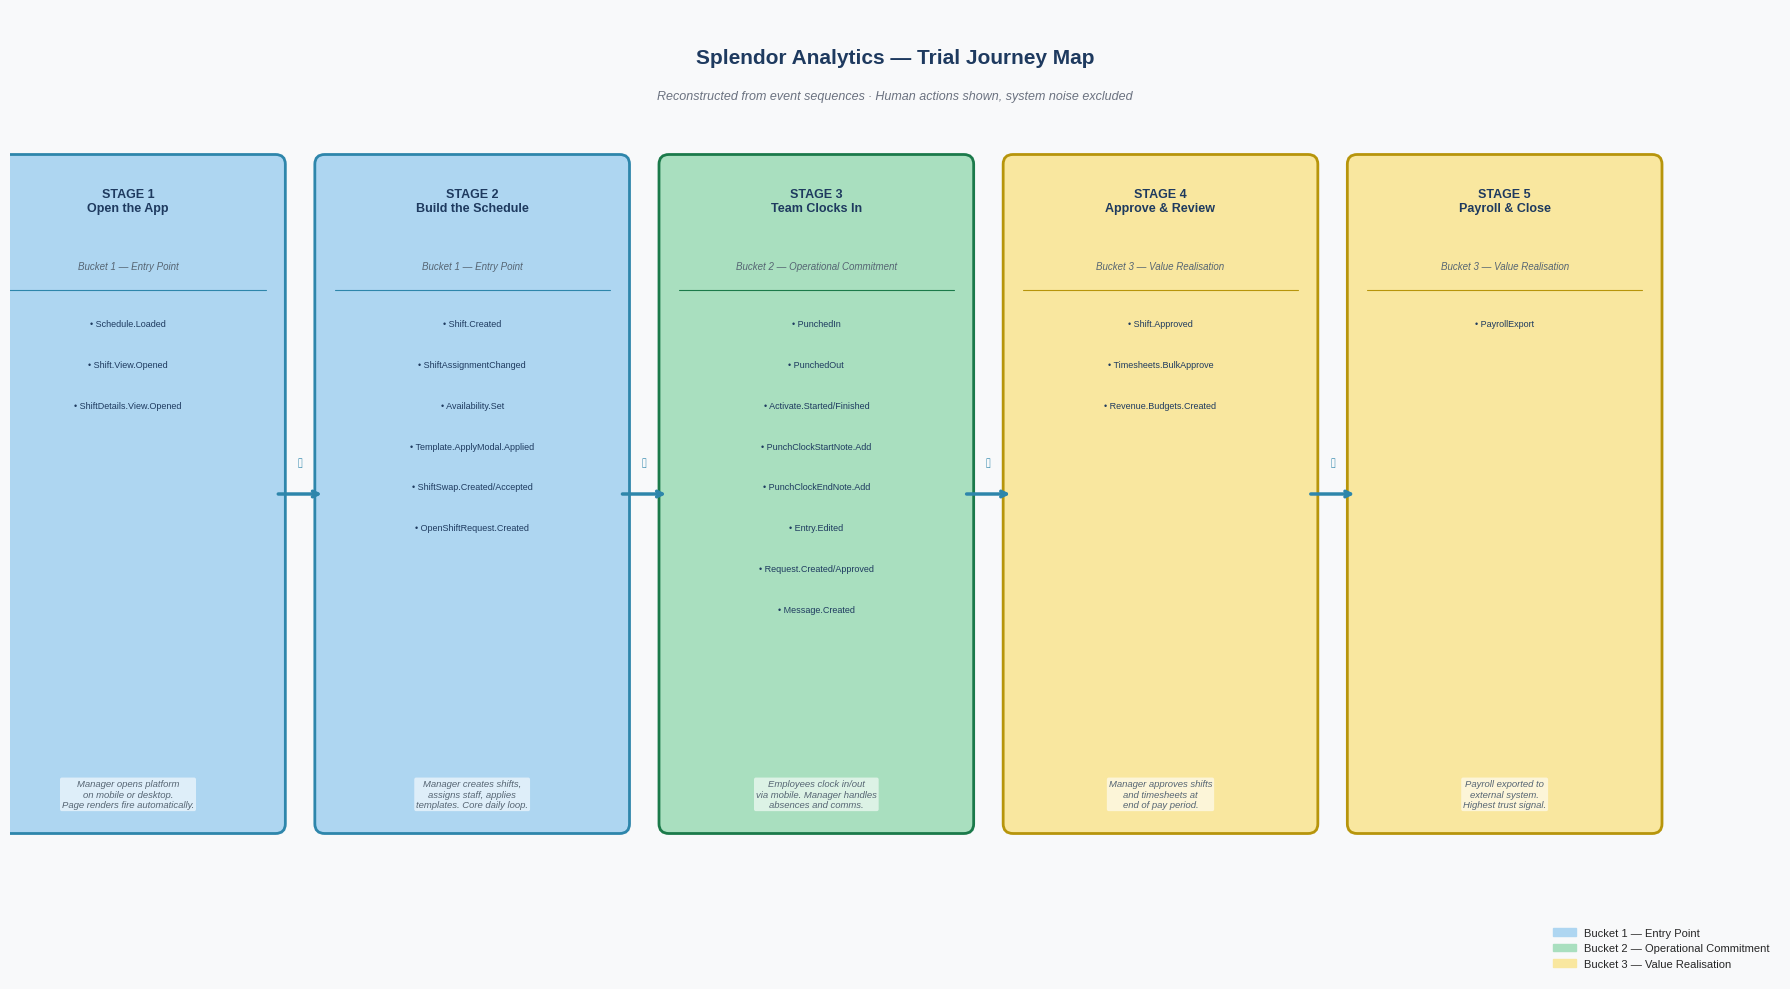

Journey map saved.


In [89]:
# ── Pre-Section: Platform Workflow Reconstruction ─────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ── Print transition table ────────────────────────────────────────────────────
print("=== TOP 15 MEANINGFUL TRANSITIONS (no self-loops) ===")
meaningful_transitions = {
    (from_act, to_act): count
    for (from_act, to_act), count in transition_counts.items()
    if from_act != to_act
}
top_transitions = sorted(
    meaningful_transitions.items(),
    key=lambda x: x[1], reverse=True
)[:15]
for (from_act, to_act), count in top_transitions:
    print(f"  {from_act:45s} → {to_act:45s}  ({count:,})")

# ── Journey Map ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

# Title
ax.text(9, 9.5, 'Splendor Analytics — Trial Journey Map',
        ha='center', va='center', fontsize=15, fontweight='bold',
        color='#1E3A5F')
ax.text(9, 9.1, 'Reconstructed from event sequences · Human actions shown, system noise excluded',
        ha='center', va='center', fontsize=9, color='#6B7280', style='italic')

# Stage definitions
stages = [
    {
        'title':    'STAGE 1\nOpen the App',
        'bucket':   'Bucket 1 — Entry Point',
        'color':    '#AED6F1',
        'border':   '#2E86AB',
        'activities': [
            'Mobile.Schedule.Loaded',
            'Shift.View.Opened',
            'ShiftDetails.View.Opened',
        ],
        'note': 'Manager opens platform\non mobile or desktop.\nPage renders fire automatically.',
        'x': 1.2,
    },
    {
        'title':    'STAGE 2\nBuild the Schedule',
        'bucket':   'Bucket 1 — Entry Point',
        'color':    '#AED6F1',
        'border':   '#2E86AB',
        'activities': [
            'Scheduling.Shift.Created',
            'Scheduling.ShiftAssignmentChanged',
            'Scheduling.Availability.Set',
            'Scheduling.Template.ApplyModal.Applied',
            'Scheduling.ShiftSwap.Created/Accepted',
            'Scheduling.OpenShiftRequest.Created',
        ],
        'note': 'Manager creates shifts,\nassigns staff, applies\ntemplates. Core daily loop.',
        'x': 4.7,
    },
    {
        'title':    'STAGE 3\nTeam Clocks In',
        'bucket':   'Bucket 2 — Operational Commitment',
        'color':    '#A9DFBF',
        'border':   '#1B7A4A',
        'activities': [
            'PunchClock.PunchedIn',
            'PunchClock.PunchedOut',
            'Break.Activate.Started/Finished',
            'PunchClockStartNote.Add.Completed',
            'PunchClockEndNote.Add.Completed',
            'PunchClock.Entry.Edited',
            'Absence.Request.Created/Approved',
            'Communication.Message.Created',
        ],
        'note': 'Employees clock in/out\nvia mobile. Manager handles\nabsences and comms.',
        'x': 8.2,
    },
    {
        'title':    'STAGE 4\nApprove & Review',
        'bucket':   'Bucket 3 — Value Realisation',
        'color':    '#F9E79F',
        'border':   '#B7950B',
        'activities': [
            'Scheduling.Shift.Approved',
            'Timesheets.BulkApprove.Confirmed',
            'Revenue.Budgets.Created',
        ],
        'note': 'Manager approves shifts\nand timesheets at\nend of pay period.',
        'x': 11.7,
    },
    {
        'title':    'STAGE 5\nPayroll & Close',
        'bucket':   'Bucket 3 — Value Realisation',
        'color':    '#F9E79F',
        'border':   '#B7950B',
        'activities': [
            'Integration.Xero.PayrollExport.Synced',
        ],
        'note': 'Payroll exported to\nexternal system.\nHighest trust signal.',
        'x': 15.2,
    },
]

box_width  = 3.0
box_top    = 8.4
box_height = 6.8

for stage in stages:
    x = stage['x']

    # Main stage box
    ax.add_patch(FancyBboxPatch(
        (x - box_width/2, box_top - box_height),
        box_width, box_height,
        boxstyle='round,pad=0.1',
        facecolor=stage['color'],
        edgecolor=stage['border'],
        linewidth=2, zorder=2
    ))

    # Stage title
    ax.text(x, box_top - 0.25, stage['title'],
            ha='center', va='top', fontsize=9, fontweight='bold',
            color='#1E3A5F', zorder=3)

    # Bucket label
    ax.text(x, box_top - 1.0, stage['bucket'],
            ha='center', va='top', fontsize=7,
            color='#566573', style='italic', zorder=3)

    # Divider line
    ax.plot([x - box_width/2 + 0.1, x + box_width/2 - 0.1],
            [box_top - 1.3, box_top - 1.3],
            color=stage['border'], linewidth=0.8, zorder=3)

    # Activities list
    for i, act in enumerate(stage['activities']):
        # Shorten name for display
        short = act.replace('Scheduling.', '')\
                   .replace('PunchClock.', '')\
                   .replace('Integration.Xero.', '')\
                   .replace('Mobile.', '')\
                   .replace('Communication.', '')\
                   .replace('Absence.', '')\
                   .replace('Break.', '')\
                   .replace('.Completed', '')\
                   .replace('.Confirmed', '')\
                   .replace('.Synced', '')
        ax.text(x, box_top - 1.6 - i * 0.42,
                f'• {short}',
                ha='center', va='top', fontsize=6.5,
                color='#1E3A5F', zorder=3)

    # Note at bottom
    ax.text(x, box_top - box_height + 0.15,
            stage['note'],
            ha='center', va='bottom', fontsize=6.8,
            color='#566573', style='italic', zorder=3,
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', alpha=0.6, edgecolor='none'))

# Arrows between stages
arrow_y = box_top - box_height/2
for i in range(len(stages) - 1):
    x_start = stages[i]['x']   + box_width/2
    x_end   = stages[i+1]['x'] - box_width/2
    ax.annotate('',
        xy=(x_end, arrow_y),
        xytext=(x_start, arrow_y),
        arrowprops=dict(
            arrowstyle='->', color='#2E86AB',
            lw=2.5,
            connectionstyle='arc3,rad=0.0'
        ), zorder=4
    )
    # Transition count label on arrow
    mid_x = (x_start + x_end) / 2
    ax.text(mid_x, arrow_y + 0.25, '▶',
            ha='center', va='bottom', fontsize=10,
            color='#2E86AB', zorder=4)

# Legend
legend_items = [
    mpatches.Patch(color='#AED6F1', edgecolor='#2E86AB',
                   label='Bucket 1 — Entry Point'),
    mpatches.Patch(color='#A9DFBF', edgecolor='#1B7A4A',
                   label='Bucket 2 — Operational Commitment'),
    mpatches.Patch(color='#F9E79F', edgecolor='#B7950B',
                   label='Bucket 3 — Value Realisation'),
]
ax.legend(handles=legend_items, loc='lower right',
          fontsize=8, framealpha=0.95,
          edgecolor='#BDC3C7')

plt.tight_layout()
plt.savefig('platform_journey_map.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Journey map saved.")

#### **Key take aways**

We built a transition table showing which activity most
commonly follows each other activity across all 966 organisations.
Filtering out self-loops, where the same activity follows itself then
we identified the 15 most meaningful transitions representing genuine
workflow progression rather than system noise.

Three patterns emerged immediately. First, `Mobile.Schedule.Loaded`
appears before and after almost every other action, confirming it is
a page render event that fires automatically on every app load or
navigation, not a deliberate user action. Second,
`Scheduling.ShiftAssignmentChanged` consistently follows
`Scheduling.Shift.Created` as part of the same user action, confirming
these two events are generated by a single shift creation workflow
rather than two separate decisions. Third, the self-loop transitions
confirmed the instrumentation hypothesis raised during data cleaning,  
`Scheduling.Shift.Created` following itself 90,281 times is not
repeated user behaviour; it is the platform firing the same event
multiple times per single action.

From these patterns, the platform workflow maps cleanly into five
stages as shown in the journey map above: opening the app, building
the schedule, the team clocking in, approving and reviewing, and
finally closing payroll. These five stages align directly with our
three-bucket framework, validating that the hierarchy we defined from
business logic is consistent with how organisations actually move
through the platform.

**Decision:** The self-loop evidence is sufficient to justify removing
duplicates from `Scheduling.Shift.Created` and
`Scheduling.ShiftAssignmentChanged`. This will be carried out in
Section 4.1 to ensure all downstream volume-based analysis reflects
actual user actions rather than instrumentation noise.

### **4.1 Data Integrity Resolution**

Before any volume-based analysis can be trusted, three data integrity
questions flagged during cleaning must be resolved: the instrumentation
duplicates in `Scheduling.Shift.Created` and `Scheduling.ShiftAssignmentChanged`,
the unexplained imbalance between `PunchClock.PunchedIn` and `PunchClock.PunchedOut`,
and the high-volume outlier organisations whose event counts may distort
engagement comparisons.

In [90]:
# ── 4.1a Instrumentation Duplicate Resolution ─────────────────────────────────

instrumentation_activities = [
    'Scheduling.Shift.Created',
    'Scheduling.ShiftAssignmentChanged',
]

print("=== BEFORE DEDUPLICATION ===")
for act in instrumentation_activities:
    count = len(df[df['activity_name'] == act])
    print(f"  {act}: {count:,}")
print(f"  Total dataset rows: {len(df):,}")

# Remove duplicates for instrumentation activities only
df_to_dedup = df[df['activity_name'].isin(instrumentation_activities)]
df_to_keep  = df[~df['activity_name'].isin(instrumentation_activities)]

df_deduped = df_to_dedup.drop_duplicates(
    subset=['organization_id', 'activity_name', 'timestamp'],
    keep='first'
)

df = pd.concat([df_to_keep, df_deduped], ignore_index=True)
df = df.sort_values(
    ['organization_id', 'timestamp']
).reset_index(drop=True)

print("\n=== AFTER DEDUPLICATION ===")
for act in instrumentation_activities:
    count = len(df[df['activity_name'] == act])
    print(f"  {act}: {count:,}")
print(f"  Total dataset rows: {len(df):,}")
print(f"  Rows removed: {169335 - len(df):,}")

# Confirm no duplicates remain for these activities
remaining = df[
    df['activity_name'].isin(instrumentation_activities)
].duplicated(
    subset=['organization_id', 'activity_name', 'timestamp'],
    keep='first'
).sum()
print(f"\nRemaining duplicates in these activities: {remaining} ✓"
      if remaining == 0 else f"\nRemaining duplicates: {remaining} ⚠️")

=== BEFORE DEDUPLICATION ===
  Scheduling.Shift.Created: 96,895
  Scheduling.ShiftAssignmentChanged: 0
  Total dataset rows: 169,335

=== AFTER DEDUPLICATION ===
  Scheduling.Shift.Created: 31,818
  Scheduling.ShiftAssignmentChanged: 0
  Total dataset rows: 104,258
  Rows removed: 65,077

Remaining duplicates in these activities: 0 ✓


#### **PunchClock Imbalance Hypothesis**

The dataset shows 4,833 `PunchClock.PunchedIn` events against only
123 `PunchClock.PunchedOut` events, a 39-to-1 ratio that warrants
investigation.

The most plausible explanation is human behaviour rather than a data
error. Clocking in is front of mind, staff arrive, open the app, and
clock in because that is the action that starts their shift. Clocking
out at the end of a long day is easier to forget, there is no
operational barrier enforcing it the way arriving at work enforces
clocking in. This mirrors real-world behaviour where sign-in compliance
is typically higher than sign-out compliance.

Notably, the reverse pattern, more clock-outs than clock-ins, would
be far more alarming as it would suggest a genuine data integrity
failure. The direction of the imbalance here is consistent with
expected human behaviour.

If this hypothesis is correct, the imbalance reflects either an
app design gap where clock-out reminders are insufficient, or a
manager briefing gap where staff were not trained on the importance
of completing the full punch clock cycle.

To test this **hypothesis** we run two checks: first, whether the imbalance
is spread across many organisations or concentrated in a few, a widespread
pattern supports human behaviour while concentration points to a pipeline
issue. Second, whether every organisation with a `PunchClock.PunchedOut`
event also has a corresponding `PunchClock.PunchedIn`, if the pair
relationship holds in one direction, the imbalance is one-directional
and consistent with the **hypothesis**.

=== TEST 1: ORGANISATION-LEVEL DISTRIBUTION ===
Organisations with PunchedIn events:     211
Organisations with PunchedOut events:    8
Organisations with both:                 8
Organisations with PunchedIn only:       203
Organisations with PunchedOut only:      0

Top 10 organisations by PunchedIn count:
                                  punched_in  punched_out  converted
organization_id                                                     
36806a4a8060ce3d5516619fd6bb2c49         363           52      False
13b69a5a22f20ec834a2870c937ba433         175            0      False
015f38565a692a85e2824e94926a12ef         167            0       True
1aa19170400130817b213e41d92f9f40         167            0      False
219dfd44d405434e4d8eb629438ca37f         159            0      False
1be10b234e672e5610a6b5460aa926c9         157            0      False
1a8b5147799e2be4ea659a37f82f2e60         146            0      False
1eea5f07fcb641dccfe51cc2341a66b0         128            0      False
3

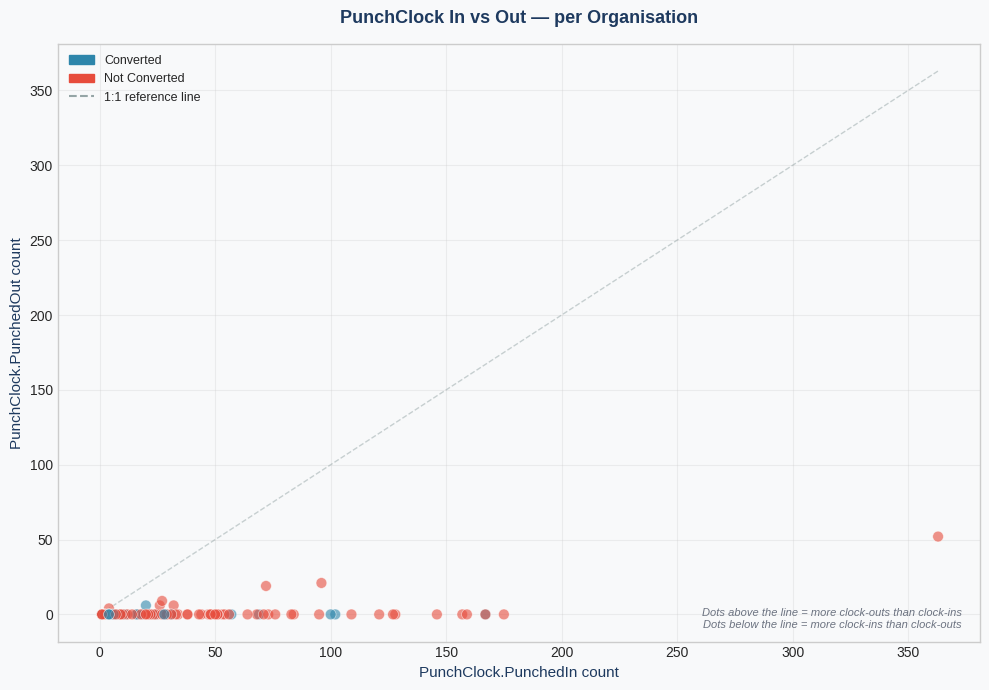

Chart saved.


In [91]:
# ── 4.1b PunchClock Imbalance Investigation ───────────────────────────────────

print("=== TEST 1: ORGANISATION-LEVEL DISTRIBUTION ===")
punch_orgs = df[df['activity_name'].isin(
    ['PunchClock.PunchedIn', 'PunchClock.PunchedOut']
)].groupby(['organization_id', 'activity_name']).size().unstack(fill_value=0)

punch_orgs.columns = ['punched_in', 'punched_out']

# Add conversion status
org_converted = df.drop_duplicates('organization_id').set_index(
    'organization_id'
)['converted']
punch_orgs['converted'] = punch_orgs.index.map(org_converted)

print(f"Organisations with PunchedIn events:     {(punch_orgs['punched_in'] > 0).sum():,}")
print(f"Organisations with PunchedOut events:    {(punch_orgs['punched_out'] > 0).sum():,}")
print(f"Organisations with both:                 {((punch_orgs['punched_in'] > 0) & (punch_orgs['punched_out'] > 0)).sum():,}")
print(f"Organisations with PunchedIn only:       {((punch_orgs['punched_in'] > 0) & (punch_orgs['punched_out'] == 0)).sum():,}")
print(f"Organisations with PunchedOut only:      {((punch_orgs['punched_in'] == 0) & (punch_orgs['punched_out'] > 0)).sum():,}")

print(f"\nTop 10 organisations by PunchedIn count:")
print(punch_orgs.nlargest(10, 'punched_in')[
    ['punched_in', 'punched_out', 'converted']
].to_string())

print("\n=== TEST 2: PAIR RELATIONSHIP CHECK ===")
out_no_in = punch_orgs[
    (punch_orgs['punched_out'] > 0) &
    (punch_orgs['punched_in'] == 0)
]
print(f"Organisations with PunchedOut but NO PunchedIn: {len(out_no_in)}")
if len(out_no_in) == 0:
    print("Pair relationship intact — every org with PunchedOut "
          "also has PunchedIn ✓")
else:
    print(out_no_in.to_string())

# ── Scatter Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

colors = punch_orgs['converted'].map(
    {True: '#2E86AB', False: '#E74C3C'}
)

scatter = ax.scatter(
    punch_orgs['punched_in'],
    punch_orgs['punched_out'],
    c=colors,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    s=60,
    zorder=3
)

# Reference line — perfect 1:1 ratio
max_val = max(
    punch_orgs['punched_in'].max(),
    punch_orgs['punched_out'].max()
)
ax.plot([0, max_val], [0, max_val],
        color='#95A5A6', linewidth=1,
        linestyle='--', alpha=0.5,
        label='1:1 reference line', zorder=2)

ax.set_xlabel('PunchClock.PunchedIn count', fontsize=11, color='#1E3A5F')
ax.set_ylabel('PunchClock.PunchedOut count', fontsize=11, color='#1E3A5F')
ax.set_title('PunchClock In vs Out — per Organisation',
             fontsize=13, fontweight='bold', color='#1E3A5F', pad=15)

ax.text(0.98, 0.02,
        'Dots above the line = more clock-outs than clock-ins\n'
        'Dots below the line = more clock-ins than clock-outs',
        transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8,
        color='#6B7280', style='italic')

legend_handles = [
    mpatches.Patch(color='#2E86AB', label='Converted'),
    mpatches.Patch(color='#E74C3C', label='Not Converted'),
    plt.Line2D([0], [0], color='#95A5A6', linestyle='--',
               label='1:1 reference line'),
]
ax.legend(handles=legend_handles, fontsize=9,
          framealpha=0.9, edgecolor='#BDC3C7')

ax.grid(True, alpha=0.3, zorder=1)
plt.tight_layout()
plt.savefig('punchclock_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Chart saved.")

**Finding:** 211 organisations recorded `PunchClock.PunchedIn` events
against only 8 recording `PunchClock.PunchedOut`. Test 2 confirms the
pair relationship is intact, no organisation clocked out without first
clocking in, ruling out a data pipeline error.

The scatter plot shows the imbalance is spread across 203 organisations
rather than concentrated in a few, confirming this is a behavioural
pattern rather than a technical fault. Staff consistently clock in at
the start of their shift but frequently forget to clock out, consistent
with the hypothesis that arrival is front of mind while departure
enforcement is absent.

But we do have an outlier or an organization showing 363 PunchedIn and 52 PunchedOut which is close to a blance clock usage but even if at that the organization is a non-converter any way so we can't make a decison out of that but it is woth noting as an interesing side note cos punch event have shown a to be a fairly  significant event

**Decision:** `PunchClock.PunchedIn` is retained as the primary punch
clock signal for conversion analysis. `PunchClock.PunchedOut` is noted
as analytically sparse and will not be used as a standalone conversion
indicator. No records removed.

=== EVENT VOLUME DISTRIBUTION ===
count     966.0
mean      107.9
std       340.0
min         1.0
25%         2.0
50%         8.0
75%        44.0
max      5701.0

=== TOP 15 ORGANISATIONS BY EVENT COUNT ===
                      organization_id  total_events  distinct_activities  converted
666  36806a4a8060ce3d5516619fd6bb2c49          5701                   20      False
378  1eea5f07fcb641dccfe51cc2341a66b0          2814                    7      False
959  4e03db56b8cad5be5bf59fdac60a5af1          2794                   10       True
10   015f38565a692a85e2824e94926a12ef          2128                   10       True
581  2ded176402d5b333fea4ac07cead924f          2124                    6      False
380  1ef6adc7e9245e35da160a89a426895e          2034                    5      False
325  1a8b5147799e2be4ea659a37f82f2e60          1994                   15      False
418  219dfd44d405434e4d8eb629438ca37f          1785                   10      False
234  13b69a5a22f20ec834a2870c937ba433

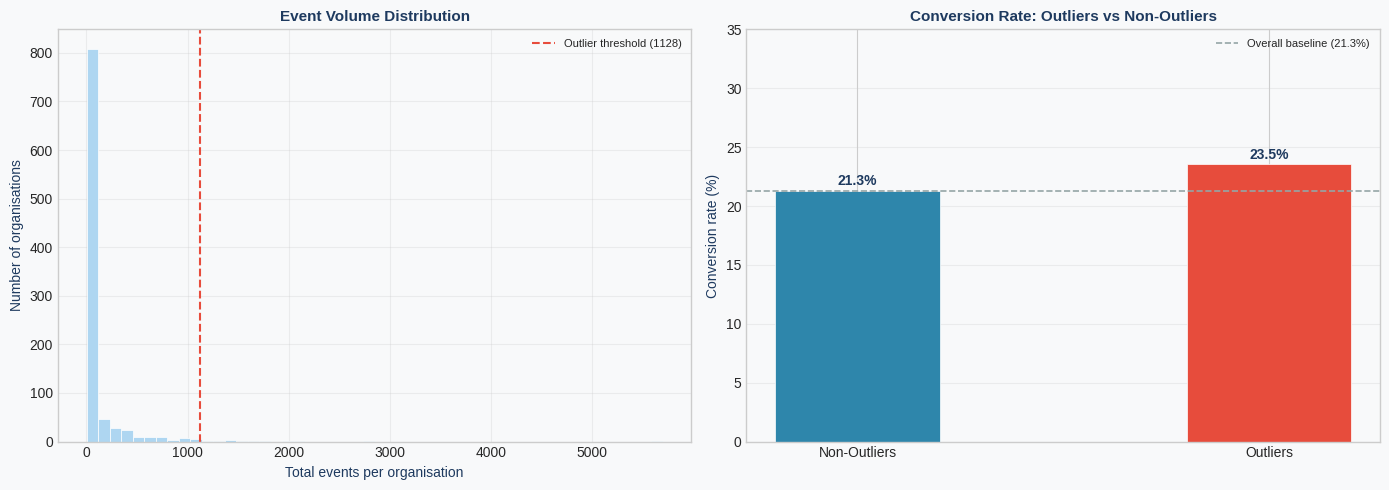

Chart saved.


In [92]:
# ── 4.1c High-Volume Outlier Investigation ────────────────────────────────────

org_profile = df.groupby('organization_id').agg(
    total_events        = ('activity_name', 'count'),
    distinct_activities = ('activity_name', 'nunique'),
    converted           = ('converted', 'first'),
    conversion_timing   = ('conversion_timing', 'first')
).reset_index()

print("=== EVENT VOLUME DISTRIBUTION ===")
print(org_profile['total_events'].describe().round(1).to_string())

print("\n=== TOP 15 ORGANISATIONS BY EVENT COUNT ===")
print(org_profile.nlargest(15, 'total_events')[
    ['organization_id', 'total_events',
     'distinct_activities', 'converted']
].to_string())

# Define outlier threshold — beyond 3 standard deviations
mean   = org_profile['total_events'].mean()
std    = org_profile['total_events'].std()
cutoff = mean + 3 * std

outliers     = org_profile[org_profile['total_events'] > cutoff]
non_outliers = org_profile[org_profile['total_events'] <= cutoff]

print(f"\n=== OUTLIER THRESHOLD (mean + 3 std) ===")
print(f"Mean:      {mean:.1f}")
print(f"Std:       {std:.1f}")
print(f"Threshold: {cutoff:.1f}")
print(f"Outliers:  {len(outliers)} organisations")
print(f"\nOutlier conversion rate: "
      f"{outliers['converted'].mean()*100:.1f}%")
print(f"Non-outlier conversion rate: "
      f"{non_outliers['converted'].mean()*100:.1f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')

# Chart 1 — Event volume distribution with outlier threshold
axes[0].set_facecolor('#F8F9FA')
axes[0].hist(
    org_profile['total_events'],
    bins=50, color='#AED6F1',
    edgecolor='white', linewidth=0.5
)
axes[0].axvline(cutoff, color='#E74C3C', linestyle='--',
                linewidth=1.5, label=f'Outlier threshold ({cutoff:.0f})')
axes[0].set_xlabel('Total events per organisation',
                   fontsize=10, color='#1E3A5F')
axes[0].set_ylabel('Number of organisations',
                   fontsize=10, color='#1E3A5F')
axes[0].set_title('Event Volume Distribution',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Chart 2 — Outlier vs non-outlier conversion rate
categories  = ['Non-Outliers', 'Outliers']
conv_rates  = [
    non_outliers['converted'].mean() * 100,
    outliers['converted'].mean() * 100
]
bar_colors  = ['#2E86AB', '#E74C3C']
bars = axes[1].bar(categories, conv_rates,
                   color=bar_colors, edgecolor='white',
                   linewidth=0.5, width=0.4)
axes[1].axhline(21.3, color='#95A5A6', linestyle='--',
                linewidth=1.2, label='Overall baseline (21.3%)')
for bar, rate in zip(bars, conv_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center',
                 fontsize=10, fontweight='bold', color='#1E3A5F')
axes[1].set_ylabel('Conversion rate (%)',
                   fontsize=10, color='#1E3A5F')
axes[1].set_title('Conversion Rate: Outliers vs Non-Outliers',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1].set_ylim(0, 35)
axes[1].legend(fontsize=8)
axes[1].set_facecolor('#F8F9FA')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Chart saved.")

This section was investigating whether the high-volume organisations, the ones with unusually large event counts, are distorting our dataset. The concern was that a few organisations with thousands of events could skew any average-based analysis, making engagement look higher than it actually is for most organisations. We wanted to know if they should be removed or flagged before moving into the cohort comparison.

**Finding:** Event volume is highly skewed, the median organisation
has only 8 events while the mean is 107.9, pulled up by 17 outlier
organisations exceeding 1,128 events. The top organisation recorded
5,701 events across 20 distinct activity types without converting.

The conversion rate chart is the key finding. Outliers convert at 23.5% versus 21.3% for non-outliers indicating event volume does not predict conversion meaningfully.

### **4.2 Volume and Engagement Profile**

With data integrity confirmed, we now profile how organisations engage
with the platform comparing converters and non-converters across
event volume, activity diversity, and engagement depth to understand
what behavioural patterns distinguish the two groups before any
feature-level analysis.

=== ENGAGEMENT PROFILE BY CONVERSION STATUS ===
           organisations  median_events  median_activities  mean_events  mean_activities
converted                                                                               
False                760            8.0                2.0        107.9              2.8
True                 206            8.0                2.0        108.0              2.8

=== HIGHEST BUCKET REACHED BY CONVERSION STATUS ===
                non_converted  converted  total  conversion_rate
highest_bucket                                                  
1                         377        101    478             21.1
2                         172         52    224             23.2
3                         211         53    264             20.1


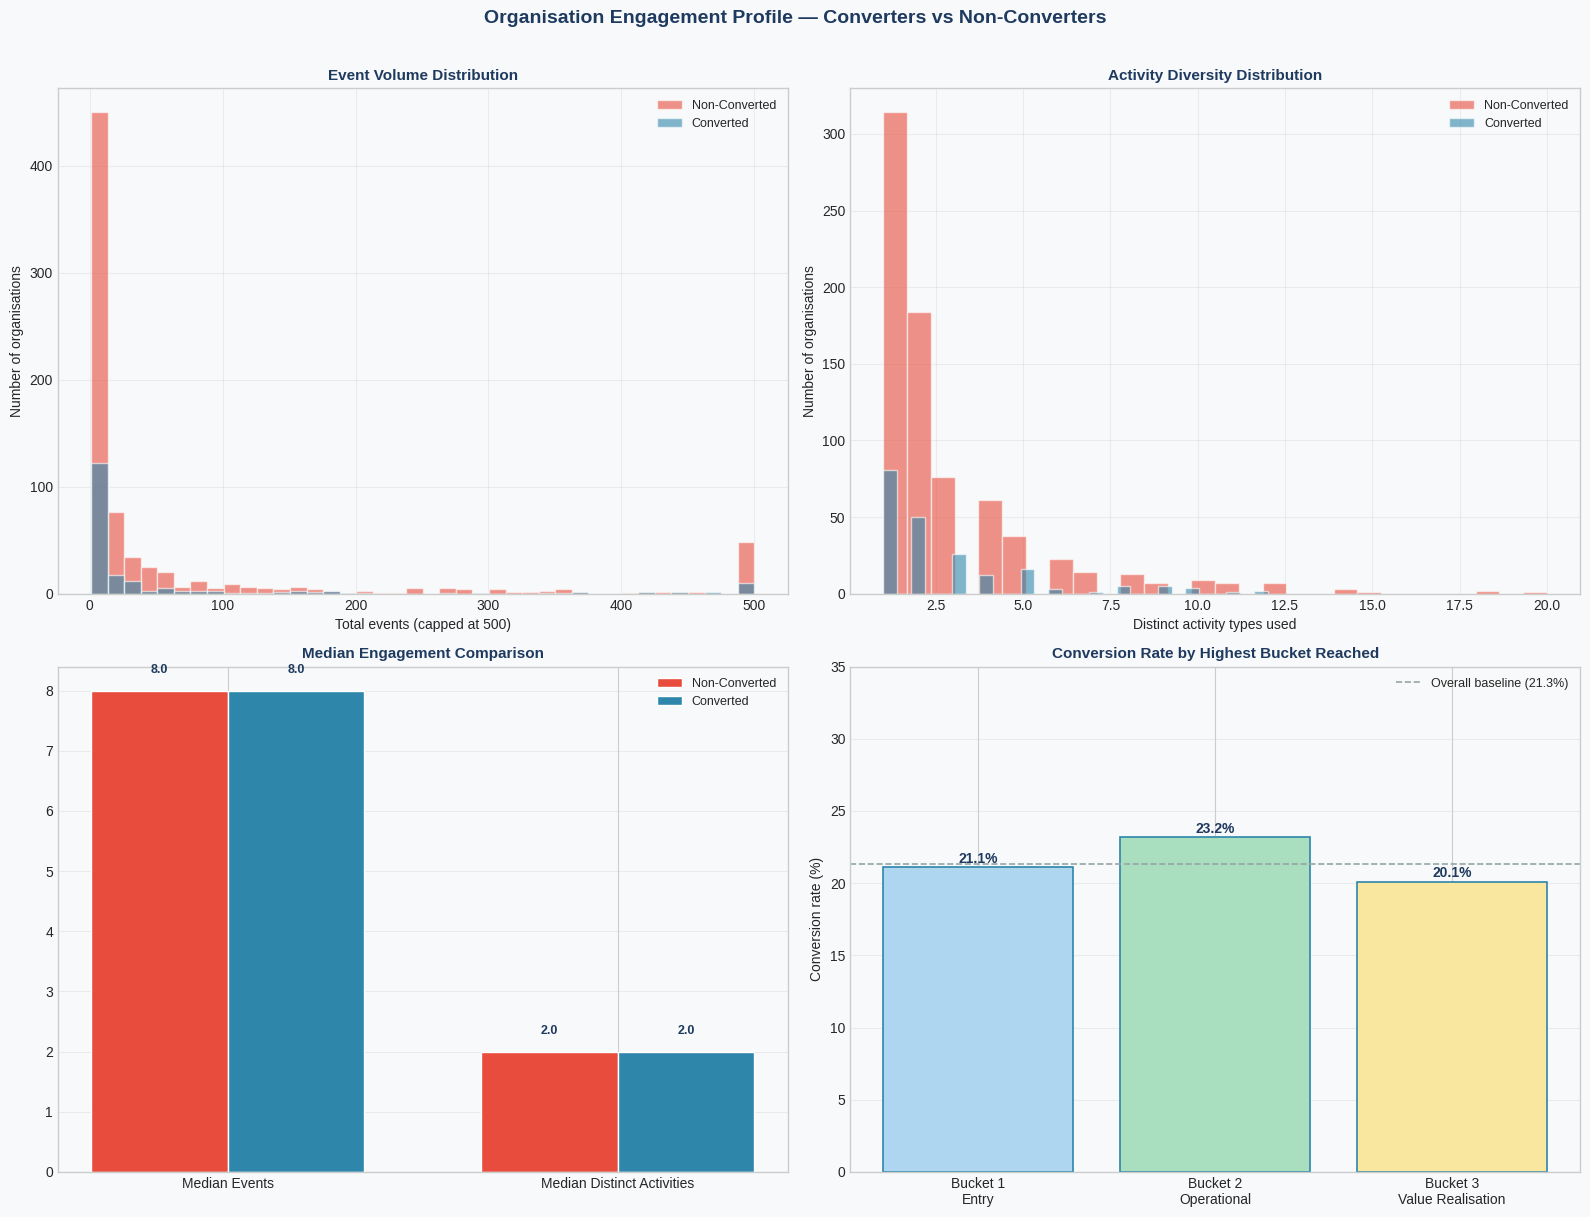

Charts saved.


In [93]:
# ── 4.2 Volume and Engagement Profile ────────────────────────────────────────

org_profile = df.groupby('organization_id').agg(
    total_events        = ('activity_name', 'count'),
    distinct_activities = ('activity_name', 'nunique'),
    highest_bucket      = ('activity_bucket', 'max'),
    converted           = ('converted', 'first'),
    conversion_timing   = ('conversion_timing', 'first')
).reset_index()

print("=== ENGAGEMENT PROFILE BY CONVERSION STATUS ===")
profile_summary = org_profile.groupby('converted').agg(
    organisations       = ('organization_id', 'count'),
    median_events       = ('total_events', 'median'),
    median_activities   = ('distinct_activities', 'median'),
    mean_events         = ('total_events', 'mean'),
    mean_activities     = ('distinct_activities', 'mean'),
).round(1)
print(profile_summary.to_string())

print("\n=== HIGHEST BUCKET REACHED BY CONVERSION STATUS ===")
bucket_conv = org_profile.groupby(
    ['highest_bucket', 'converted']
).size().unstack(fill_value=0)
bucket_conv.columns = ['non_converted', 'converted']
bucket_conv['total'] = bucket_conv.sum(axis=1)
bucket_conv['conversion_rate'] = (
    bucket_conv['converted'] / bucket_conv['total'] * 100
).round(1)
print(bucket_conv.to_string())

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Organisation Engagement Profile — Converters vs Non-Converters',
             fontsize=14, fontweight='bold', color='#1E3A5F', y=1.01)

converters     = org_profile[org_profile['converted'] == True]
non_converters = org_profile[org_profile['converted'] == False]

# Chart 1 — Event volume distribution by conversion status
axes[0,0].set_facecolor('#F8F9FA')
axes[0,0].hist(non_converters['total_events'].clip(upper=500),
               bins=40, alpha=0.6, color='#E74C3C',
               label='Non-Converted', edgecolor='white')
axes[0,0].hist(converters['total_events'].clip(upper=500),
               bins=40, alpha=0.6, color='#2E86AB',
               label='Converted', edgecolor='white')
axes[0,0].set_xlabel('Total events (capped at 500)', fontsize=10)
axes[0,0].set_ylabel('Number of organisations', fontsize=10)
axes[0,0].set_title('Event Volume Distribution', fontsize=11,
                    fontweight='bold', color='#1E3A5F')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)

# Chart 2 — Distinct activity types by conversion status
axes[0,1].set_facecolor('#F8F9FA')
axes[0,1].hist(non_converters['distinct_activities'],
               bins=28, alpha=0.6, color='#E74C3C',
               label='Non-Converted', edgecolor='white')
axes[0,1].hist(converters['distinct_activities'],
               bins=28, alpha=0.6, color='#2E86AB',
               label='Converted', edgecolor='white')
axes[0,1].set_xlabel('Distinct activity types used', fontsize=10)
axes[0,1].set_ylabel('Number of organisations', fontsize=10)
axes[0,1].set_title('Activity Diversity Distribution', fontsize=11,
                    fontweight='bold', color='#1E3A5F')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# Chart 3 — Median events and activities side by side
axes[1,0].set_facecolor('#F8F9FA')
metrics   = ['Median Events', 'Median Distinct Activities']
conv_vals = [
    converters['total_events'].median(),
    converters['distinct_activities'].median()
]
non_conv_vals = [
    non_converters['total_events'].median(),
    non_converters['distinct_activities'].median()
]
x = np.arange(len(metrics))
w = 0.35
bars1 = axes[1,0].bar(x - w/2, non_conv_vals, w,
                       color='#E74C3C', label='Non-Converted',
                       edgecolor='white')
bars2 = axes[1,0].bar(x + w/2, conv_vals, w,
                       color='#2E86AB', label='Converted',
                       edgecolor='white')
for bar in bars1:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}',
                   ha='center', fontsize=9,
                   fontweight='bold', color='#1E3A5F')
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}',
                   ha='center', fontsize=9,
                   fontweight='bold', color='#1E3A5F')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(metrics, fontsize=10)
axes[1,0].set_title('Median Engagement Comparison',
                    fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Chart 4 — Conversion rate by highest bucket reached
axes[1,1].set_facecolor('#F8F9FA')
bucket_labels = ['Bucket 1\nEntry', 'Bucket 2\nOperational',
                 'Bucket 3\nValue Realisation']
conv_rates = bucket_conv['conversion_rate'].values
bar_colors = ['#AED6F1', '#A9DFBF', '#F9E79F']
bars = axes[1,1].bar(bucket_labels, conv_rates,
                     color=bar_colors,
                     edgecolor='#2E86AB', linewidth=1.2)
axes[1,1].axhline(21.3, color='#95A5A6', linestyle='--',
                  linewidth=1.2, label='Overall baseline (21.3%)')
for bar, rate in zip(bars, conv_rates):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{rate:.1f}%', ha='center',
                   fontsize=10, fontweight='bold',
                   color='#1E3A5F')
axes[1,1].set_ylabel('Conversion rate (%)', fontsize=10)
axes[1,1].set_title('Conversion Rate by Highest Bucket Reached',
                    fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1,1].set_ylim(0, 35)
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('engagement_profile.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Charts saved.")

**Finding:** The engagement profile comparison reveals a surprising
result converters and non-converters are statistically identical
in their overall engagement metrics. Both groups share a median of
8 events and 2 distinct activity types, with mean events of 107.9
and 108.0 respectively.

This tells us that volume and diversity of activity at the aggregate
level are not what drives conversion. The typical converter does not
simply use the platform more or across more features than the typical
non-converter. The signal must lie elsewhere — specifically in which
activities were performed, when they were performed, and how quickly
organisations progressed through the platform's value hierarchy.

The bucket framework shows a modest Bucket 2 lift at 23.2% versus
the 21.1% baseline, but Bucket 3 organisations convert below baseline
at 20.1%, reinforcing that reaching high-value activities alone does
not predict conversion. The focus now shifts to the temporal and
feature-level analysis in Sections 4.3 and 4.4 where the real
conversion signals are expected to emerge.

This also mean that the **Bucket Grouping** we intorduce earlier to test whether breathdh of aactivity drives conversion was null so it is redundant for our analysis

But we still leave it there as it woudld be useful for other calculation and statistics

### **4.3 Temporal Patterns**

With volume confirmed as a weak signal, we now add the time dimension, examining when activity happens during the trial rather than how much,
to identify where and when the trial journey diverges between converters
and non-converters.

=== CONVERSION TIMING DISTRIBUTION ===
count    206.0
mean      30.4
std        8.3
min       14.0
25%       25.0
50%       30.0
75%       36.0
max       65.0

Converters by trial week:
conversion_week
Week 1          0
Week 2          3
Week 3         27
Week 4         75
Post-Trial    101

=== DAILY ACTIVITY PATTERN ===
converted     False  True 
day_of_trial              
0             13.34  12.56
1              5.27   9.66
2              3.23   2.98
3              2.61   3.58
4              2.83   1.96
5              2.49   3.39
6              2.76   2.15
7              2.73   3.00
8              2.34   1.51
9              2.71   2.69
10             2.64   2.05
11             2.16   3.20
12             1.89   1.94
13             2.88   3.99
14             3.14   2.61
15             3.75   2.88
16             3.81   3.46
17             3.58   2.74
18             2.79   3.49
19             2.96   2.82
20             3.39   2.43
21             3.20   3.80
22             2.83   4.01
2

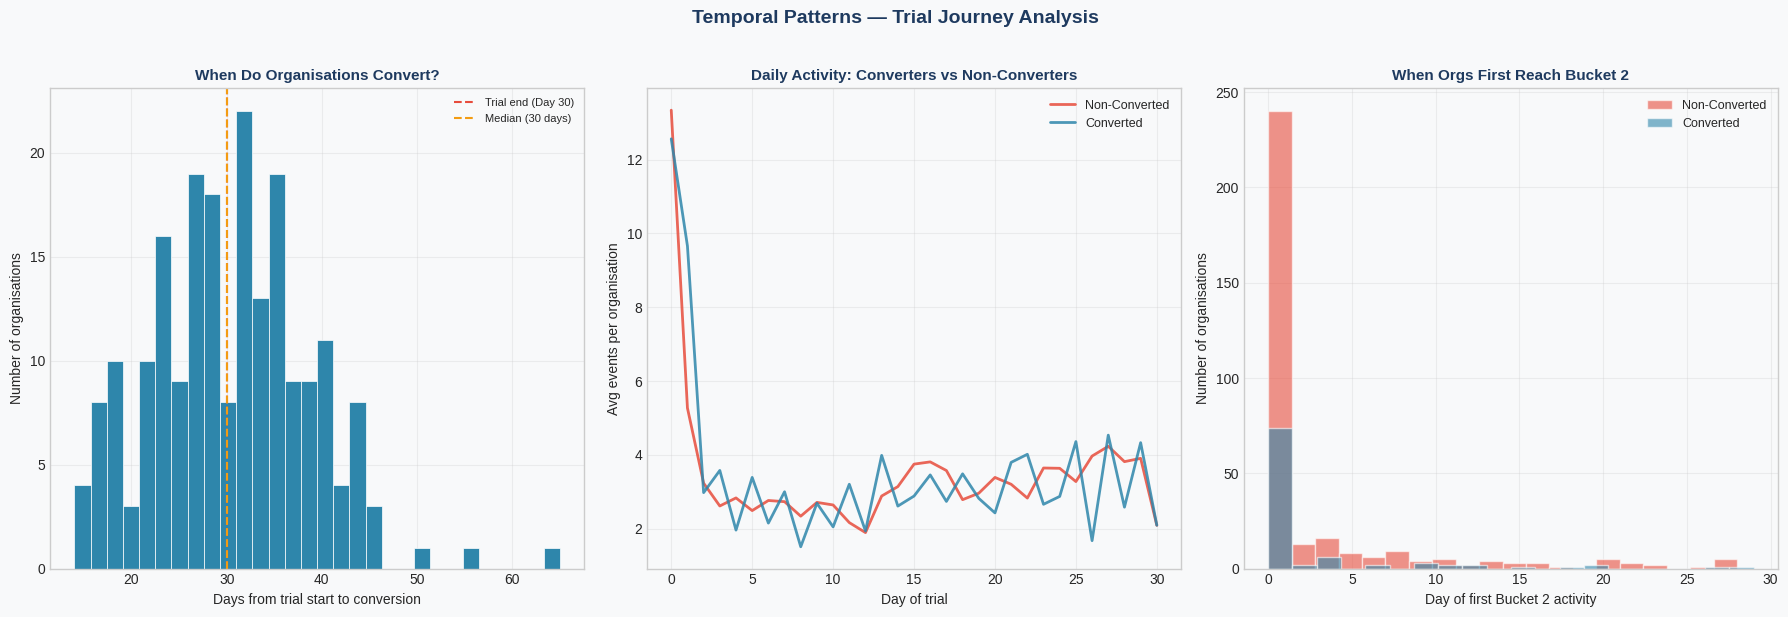

Charts saved.


In [94]:
# ── 4.3 Temporal Patterns ─────────────────────────────────────────────────────

print("=== CONVERSION TIMING DISTRIBUTION ===")
converter_orgs = df[df['converted']==True].drop_duplicates(
    'organization_id'
).copy()
converter_orgs['days_to_convert'] = (
    converter_orgs['converted_at'].dt.normalize() -
    converter_orgs['trial_start'].dt.normalize()
).dt.days

print(converter_orgs['days_to_convert'].describe().round(1).to_string())
print(f"\nConverters by trial week:")
bins   = [0, 7, 14, 21, 30, 100]
labels = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Post-Trial']
converter_orgs['conversion_week'] = pd.cut(
    converter_orgs['days_to_convert'],
    bins=bins, labels=labels
)
print(converter_orgs['conversion_week'].value_counts(
    sort=False
).to_string())

print("\n=== DAILY ACTIVITY PATTERN ===")
daily = df.groupby(
    ['day_of_trial', 'converted']
).size().reset_index(name='event_count')

org_counts = df.groupby('converted')['organization_id'].nunique()
daily['events_per_org'] = daily.apply(
    lambda r: r['event_count'] / org_counts[r['converted']], axis=1
)
print(daily.pivot(
    index='day_of_trial',
    columns='converted',
    values='events_per_org'
).round(2).to_string())

print("\n=== FIRST BUCKET 2 AND BUCKET 3 ACTIVITY TIMING ===")
for bucket in [2, 3]:
    bucket_events = df[df['activity_bucket'] == bucket]
    first_bucket = bucket_events.groupby('organization_id').agg(
        first_day    = ('day_of_trial', 'min'),
        converted    = ('converted', 'first')
    ).reset_index()
    print(f"\nBucket {bucket} — first activity day:")
    print(first_bucket.groupby('converted')['first_day'].describe(
    ).round(1).to_string())

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Temporal Patterns — Trial Journey Analysis',
             fontsize=14, fontweight='bold',
             color='#1E3A5F', y=1.02)

# Chart 1 — When do converters convert?
axes[0].set_facecolor('#F8F9FA')
axes[0].hist(
    converter_orgs['days_to_convert'],
    bins=30, color='#2E86AB',
    edgecolor='white', linewidth=0.5
)
axes[0].axvline(30, color='#E74C3C', linestyle='--',
                linewidth=1.5, label='Trial end (Day 30)')
axes[0].axvline(
    converter_orgs['days_to_convert'].median(),
    color='#F39C12', linestyle='--',
    linewidth=1.5,
    label=f"Median ({converter_orgs['days_to_convert'].median():.0f} days)"
)
axes[0].set_xlabel('Days from trial start to conversion',
                   fontsize=10)
axes[0].set_ylabel('Number of organisations', fontsize=10)
axes[0].set_title('When Do Organisations Convert?',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Chart 2 — Daily activity per org: converters vs non-converters
axes[1].set_facecolor('#F8F9FA')
for converted, color, label in [
    (False, '#E74C3C', 'Non-Converted'),
    (True,  '#2E86AB', 'Converted')
]:
    data = daily[daily['converted'] == converted]
    axes[1].plot(
        data['day_of_trial'],
        data['events_per_org'],
        color=color, linewidth=2,
        label=label, alpha=0.85
    )
axes[1].set_xlabel('Day of trial', fontsize=10)
axes[1].set_ylabel('Avg events per organisation', fontsize=10)
axes[1].set_title('Daily Activity: Converters vs Non-Converters',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Chart 3 — First Bucket 2 activity day distribution
axes[2].set_facecolor('#F8F9FA')
bucket2_events = df[df['activity_bucket'] == 2]
first_b2 = bucket2_events.groupby('organization_id').agg(
    first_day = ('day_of_trial', 'min'),
    converted = ('converted', 'first')
).reset_index()

for converted, color, label in [
    (False, '#E74C3C', 'Non-Converted'),
    (True,  '#2E86AB', 'Converted')
]:
    data = first_b2[first_b2['converted'] == converted]
    axes[2].hist(
        data['first_day'],
        bins=20, alpha=0.6,
        color=color, label=label,
        edgecolor='white'
    )
axes[2].set_xlabel('Day of first Bucket 2 activity', fontsize=10)
axes[2].set_ylabel('Number of organisations', fontsize=10)
axes[2].set_title('When Orgs First Reach Bucket 2',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Charts saved.")

**Finding:** The temporal analysis surfaces three key insights.

First, conversion is a late-trial decision. The median conversion day
is Day 30, right at the trial end. Zero organisations converted in
Week 1 and only 3 in Week 2. The product team has the full trial
window to influence outcomes, but 49% of conversions happen in the
final week or after the trial ends.

Second, daily activity patterns show no sustained divergence between
converters and non-converters across the 30-day window. After an
early spike on Day 1 where converters show higher activity, both
groups fluctuate around similar engagement levels. This confirms
that timing and volume of activity are not reliable conversion
signals at the aggregate level.

Third, bucket timing is counterintuitive, non-converters reach
Bucket 3 activities earlier on average than converters. This suggests
that reaching high-value activities quickly does not guarantee
conversion, and that the organisations counted in these timing
stats represent a self-selected engaged minority rather than the
full population.

The signal is not in when or how much, it must be in which specific
activities organisations perform. This sets up Section 4.4 as the
critical analytical section of this notebook.

### **4.4 Feature and Bucket Analysis**

Volume, diversity, and timing have all failed to separate converters
from non-converters at the aggregate level. This section goes deeper, examining which specific activities are adopted at meaningfully different
rates between the two groups, testing whether those differences are
statistically significant, and forming the evidence-backed trial goal
hypotheses that will define trial activation.

## **Section 5 Feature Adoption Lift Analysis**

Volume, diversity, and timing have all failed to separate converters
from non-converters at the aggregate level. The median converter and
the median non-converter look identical in how much they used the
platform and when they used it. This forces a sharper question: not
how much or when, but which specific activities distinguish the two groups.

This section examines feature adoption at the individual activity level,
calculating the adoption rate for each activity across both cohorts,
measuring the lift, and testing whether the differences are statistically
significant. The findings here form the evidence base for the trial goal
definitions in Section 6.

**Hypotheses Ruled Out**

Three hypotheses that seemed reasonable before the data spoke have now
been ruled out by the evidence:

- *Higher event volume predicts conversion*: ruled out. Median events
  are identical at 8.0 for both groups.
- *Greater activity diversity predicts conversion*: ruled out. Median
  distinct activities are identical at 2.0 for both groups.
- *Reaching higher bucket levels predicts conversion*: ruled out.
  Bucket 3 organisations convert at 20.1%, below the 21.3% baseline.
- *Early engagement predicts conversion*: ruled out. Daily activity
  patterns show no sustained divergence across the 30-day trial window.

**Current Hypothesis**

Conversion is driven by specific activity types rather than aggregate
engagement. Certain activities, likely concentrated in Bucket 2 and
Bucket 3, are performed at meaningfully higher rates among converters
than non-converters. Identifying those activities and validating them
statistically is the work of this section.

### **5.1 Feature Adoption Lift**

For each of the 28 activities, we calculate the percentage of converter
organisations that performed it versus non-converters, ranking by the
size of the gap to identify which activities are most associated with
conversion.

=== FEATURE ADOPTION LIFT — ALL ACTIVITIES ===
                                  activity  bucket  converter_adoption  non_conv_adoption  lift  p_value  significant
0                 Scheduling.Shift.Created       1                89.8               87.2   2.6   0.3795        False
1   Scheduling.Template.ApplyModal.Applied       1                13.1               10.7   2.4   0.3872        False
2      Scheduling.OpenShiftRequest.Created       2                 6.3                3.9   2.4   0.2046        False
3                     PunchClock.PunchedIn       2                23.3               21.4   1.9   0.6340        False
4         Scheduling.ShiftHandover.Created       2                 1.9                0.9   1.0   0.3928        False
5                Scheduling.Shift.Approved       3                21.4               20.5   0.8   0.8691        False
6        Scheduling.ShiftHandover.Accepted       2                 1.5                0.8   0.7   0.6349        False
7        

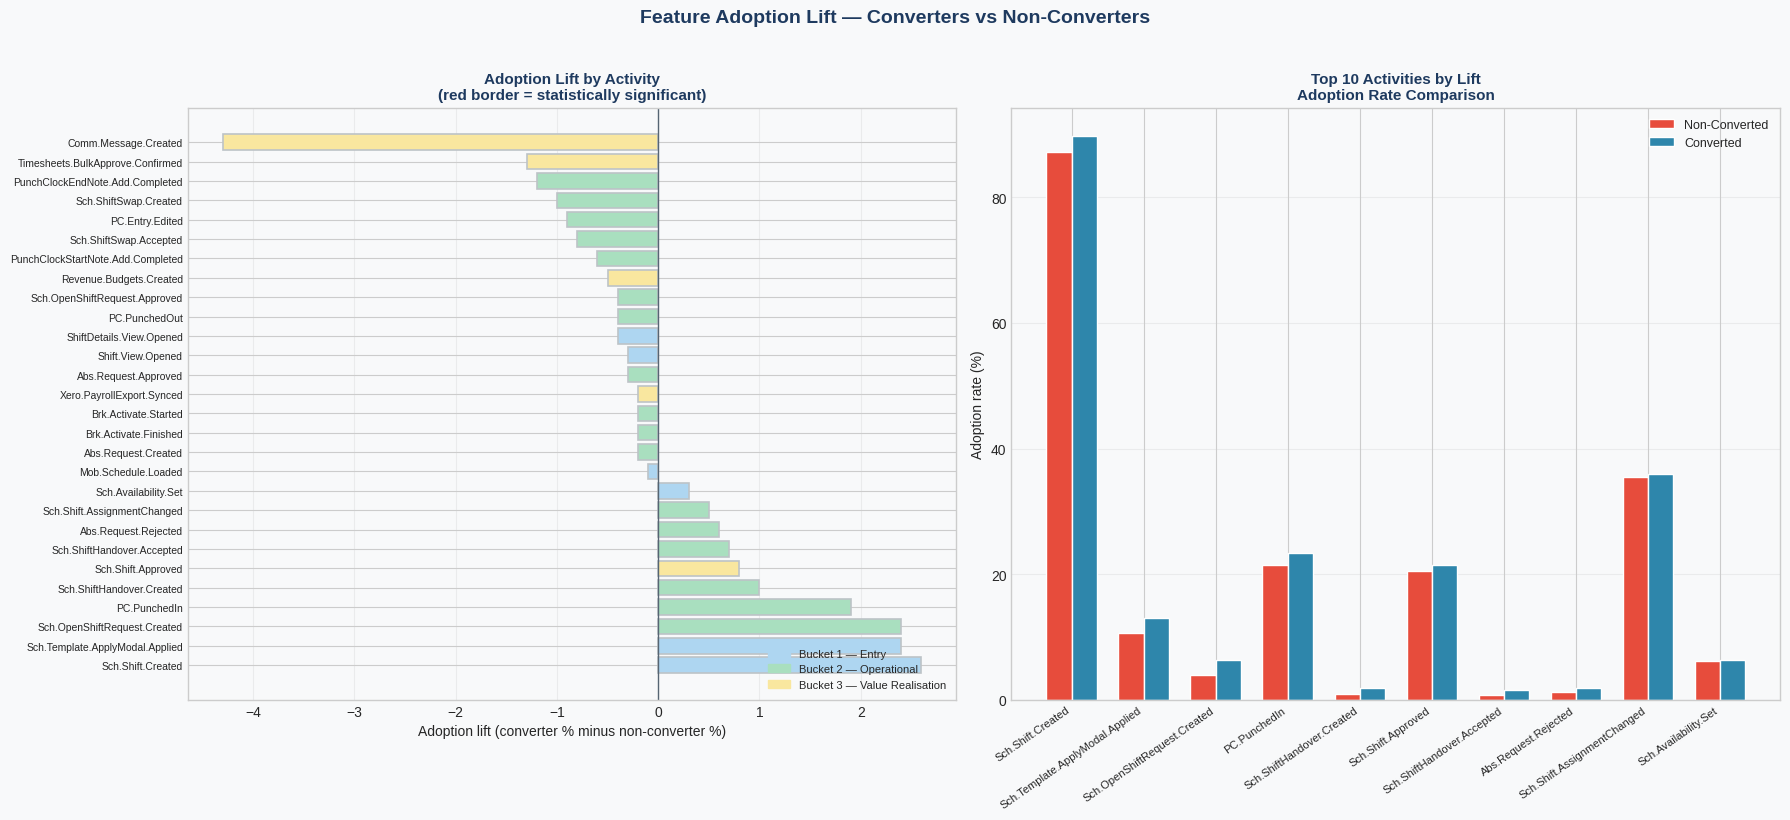

Charts saved.


In [95]:
# ── 5.1 Feature Adoption Lift ─────────────────────────────────────────────────

from scipy.stats import chi2_contingency

# Build org-level binary feature flags
org_meta = df.groupby('organization_id').agg(
    converted = ('converted', 'first')
).reset_index()

activities = df['activity_name'].unique()
for activity in activities:
    org_activity = df[df['activity_name'] == activity][
        'organization_id'
    ].unique()
    org_meta[activity] = org_meta['organization_id'].isin(
        org_activity
    ).astype(int)

total_converters     = org_meta['converted'].sum()
total_non_converters = (org_meta['converted'] == False).sum()

results = []
for activity in activities:
    conv_adopted     = org_meta[org_meta['converted']==True][activity].sum()
    non_conv_adopted = org_meta[org_meta['converted']==False][activity].sum()

    conv_rate     = conv_adopted / total_converters * 100
    non_conv_rate = non_conv_adopted / total_non_converters * 100
    lift          = conv_rate - non_conv_rate

    contingency = [
        [conv_adopted,     total_converters - conv_adopted],
        [non_conv_adopted, total_non_converters - non_conv_adopted]
    ]
    chi2, p_value, _, _ = chi2_contingency(contingency)

    bucket = df[df['activity_name']==activity]['activity_bucket'].iloc[0]

    results.append({
        'activity':           activity,
        'bucket':             bucket,
        'converter_adoption': round(conv_rate, 1),
        'non_conv_adoption':  round(non_conv_rate, 1),
        'lift':               round(lift, 1),
        'p_value':            round(p_value, 4),
        'significant':        p_value < 0.05
    })

results_df = pd.DataFrame(results).sort_values(
    'lift', ascending=False
).reset_index(drop=True)

print("=== FEATURE ADOPTION LIFT — ALL ACTIVITIES ===")
print(results_df[[
    'activity', 'bucket', 'converter_adoption',
    'non_conv_adoption', 'lift', 'p_value', 'significant'
]].to_string())

print("\n=== STATISTICALLY SIGNIFICANT ACTIVITIES (p < 0.05) ===")
significant = results_df[results_df['significant'] == True]
print(significant[[
    'activity', 'bucket', 'converter_adoption',
    'non_conv_adoption', 'lift', 'p_value'
]].to_string())

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Feature Adoption Lift — Converters vs Non-Converters',
             fontsize=14, fontweight='bold',
             color='#1E3A5F', y=1.02)

bucket_color_map = {1: '#AED6F1', 2: '#A9DFBF', 3: '#F9E79F'}
bar_colors  = [bucket_color_map.get(b, '#ECF0F1')
               for b in results_df['bucket']]
edge_colors = ['#E74C3C' if sig else '#BDC3C7'
               for sig in results_df['significant']]

axes[0].set_facecolor('#F8F9FA')
axes[0].barh(
    range(len(results_df)),
    results_df['lift'],
    color=bar_colors,
    edgecolor=edge_colors,
    linewidth=1.2
)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels(
    [a.replace('Scheduling.', 'Sch.')
      .replace('PunchClock.', 'PC.')
      .replace('Integration.Xero.', 'Xero.')
      .replace('Communication.', 'Comm.')
      .replace('Mobile.', 'Mob.')
      .replace('Absence.', 'Abs.')
      .replace('Break.', 'Brk.')
      for a in results_df['activity']],
    fontsize=7.5
)
axes[0].axvline(0, color='#566573', linewidth=1)
axes[0].set_xlabel(
    'Adoption lift (converter % minus non-converter %)',
    fontsize=10
)
axes[0].set_title(
    'Adoption Lift by Activity\n(red border = statistically significant)',
    fontsize=11, fontweight='bold', color='#1E3A5F'
)
axes[0].grid(True, alpha=0.3, axis='x')
legend_handles = [
    mpatches.Patch(color='#AED6F1', label='Bucket 1 — Entry'),
    mpatches.Patch(color='#A9DFBF', label='Bucket 2 — Operational'),
    mpatches.Patch(color='#F9E79F', label='Bucket 3 — Value Realisation'),
]
axes[0].legend(handles=legend_handles, fontsize=8,
               loc='lower right', framealpha=0.9)

top10 = results_df.head(10)
x     = np.arange(len(top10))
w     = 0.35
axes[1].set_facecolor('#F8F9FA')
axes[1].bar(x - w/2, top10['non_conv_adoption'], w,
            color='#E74C3C', label='Non-Converted', edgecolor='white')
axes[1].bar(x + w/2, top10['converter_adoption'], w,
            color='#2E86AB', label='Converted', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [a.replace('Scheduling.', 'Sch.')
      .replace('PunchClock.', 'PC.')
      .replace('Integration.Xero.', 'Xero.')
      .replace('Communication.', 'Comm.')
      .replace('Mobile.', 'Mob.')
      .replace('Absence.', 'Abs.')
      .replace('Break.', 'Brk.')
      for a in top10['activity']],
    rotation=35, ha='right', fontsize=8
)
axes[1].set_ylabel('Adoption rate (%)', fontsize=10)
axes[1].set_title(
    'Top 10 Activities by Lift\nAdoption Rate Comparison',
    fontsize=11, fontweight='bold', color='#1E3A5F'
)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('feature_adoption_lift.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Charts saved.")

**Finding:** The feature adoption lift analysis reveals that no single
activity, when measured as a binary flag, significantly predicts
conversion. Zero activities pass the p < 0.05 significance threshold.
The highest observed lift is 2.6 percentage points for
`Scheduling.Shift.Created`, and several Bucket 3 activities including
`Integration.Xero.PayrollExport.Synced` and
`Timesheets.BulkApprove.Confirmed` show negative lift, converters
adopt them at lower rates than non-converters.

This is a meaningful finding in itself. Whether an organisation ever
performed a given activity during their trial does not predict
conversion. The two cohorts are behaviourally indistinguishable at
the activity presence level, just as they were indistinguishable at
the volume and timing levels in Section 4.

This shifts the analytical focus from binary adoption to engagement
intensity. The question is no longer whether organisations performed
an activity but how deeply they engaged with it, frequency, timing,
and combination of activities. Section 5.2 builds on this insight by
moving beyond binary flags to richer engagement signals.

### **5.2 Engagement Intensity and Combination Analysis**

Binary adoption flags failed to separate the two groups, confirming
that whether an organisation performed an activity is less important
than how they engaged with it. Rather than manually defining activity
combinations upfront, which would bake our assumptions into the
findings, we engineer a broad set of intensity, timing, and sequence
features and let logistic regression and random forest models identify
which combinations actually predict conversion.

In [96]:
# ── 5.2 Feature Engineering ───────────────────────────────────────────────────

org_features = df.groupby('organization_id').agg(
    converted          = ('converted', 'first'),
    total_events       = ('activity_name', 'count'),
    distinct_activities= ('activity_name', 'nunique'),
    highest_bucket     = ('activity_bucket', 'max'),
    trial_start        = ('trial_start', 'first'),
).reset_index()

# ── Bucket-level frequency features ──────────────────────────────────────────
for bucket in [1, 2, 3]:
    bucket_df = df[df['activity_bucket'] == bucket]
    bucket_counts = bucket_df.groupby('organization_id').size()
    org_features[f'bucket{bucket}_count'] = (
        org_features['organization_id'].map(bucket_counts).fillna(0)
    )
    bucket_distinct = bucket_df.groupby(
        'organization_id'
    )['activity_name'].nunique()
    org_features[f'bucket{bucket}_distinct'] = (
        org_features['organization_id'].map(bucket_distinct).fillna(0)
    )

# ── Bucket ratios ─────────────────────────────────────────────────────────────
org_features['bucket2_to_total_ratio'] = (
    org_features['bucket2_count'] /
    org_features['total_events'].replace(0, np.nan)
).fillna(0)

org_features['bucket3_to_total_ratio'] = (
    org_features['bucket3_count'] /
    org_features['total_events'].replace(0, np.nan)
).fillna(0)

org_features['bucket2_to_bucket1_ratio'] = (
    org_features['bucket2_count'] /
    org_features['bucket1_count'].replace(0, np.nan)
).fillna(0)

# ── Timing features ───────────────────────────────────────────────────────────
# Days to first activity in each bucket
for bucket in [1, 2, 3]:
    bucket_df = df[df['activity_bucket'] == bucket]
    first_day = bucket_df.groupby('organization_id')['day_of_trial'].min()
    org_features[f'days_to_first_bucket{bucket}'] = (
        org_features['organization_id'].map(first_day).fillna(31)
    )

# Day 1 activity flag — did they do anything meaningful on Day 1
day1_orgs = df[df['day_of_trial'] <= 1]['organization_id'].unique()
org_features['active_day1'] = (
    org_features['organization_id'].isin(day1_orgs).astype(int)
)

# Early bucket 2 flag — reached bucket 2 within first 7 days
early_b2 = df[
    (df['activity_bucket'] == 2) &
    (df['day_of_trial'] <= 7)
]['organization_id'].unique()
org_features['early_bucket2'] = (
    org_features['organization_id'].isin(early_b2).astype(int)
)

# Early bucket 3 flag — reached bucket 3 within first 7 days
early_b3 = df[
    (df['activity_bucket'] == 3) &
    (df['day_of_trial'] <= 7)
]['organization_id'].unique()
org_features['early_bucket3'] = (
    org_features['organization_id'].isin(early_b3).astype(int)
)

# ── Sequence features ─────────────────────────────────────────────────────────
# Operational cycle — reached all three buckets at least once
org_features['reached_bucket1'] = (org_features['bucket1_count'] > 0).astype(int)
org_features['reached_bucket2'] = (org_features['bucket2_count'] > 0).astype(int)
org_features['reached_bucket3'] = (org_features['bucket3_count'] > 0).astype(int)

org_features['completed_full_cycle'] = (
    (org_features['reached_bucket1'] == 1) &
    (org_features['reached_bucket2'] == 1) &
    (org_features['reached_bucket3'] == 1)
).astype(int)

# Punch clock usage — frequency not just binary
punchin_counts = df[
    df['activity_name'] == 'PunchClock.PunchedIn'
].groupby('organization_id').size()
org_features['punchin_count'] = (
    org_features['organization_id'].map(punchin_counts).fillna(0)
)

# Approval activities — frequency
approval_acts = [
    'Scheduling.Shift.Approved',
    'Timesheets.BulkApprove.Confirmed'
]
approval_counts = df[
    df['activity_name'].isin(approval_acts)
].groupby('organization_id').size()
org_features['approval_count'] = (
    org_features['organization_id'].map(approval_counts).fillna(0)
)

# Payroll or budget reached
payroll_acts = [
    'Integration.Xero.PayrollExport.Synced',
    'Revenue.Budgets.Created'
]
payroll_orgs = df[
    df['activity_name'].isin(payroll_acts)
]['organization_id'].unique()
org_features['reached_payroll'] = (
    org_features['organization_id'].isin(payroll_orgs).astype(int)
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=== ENGINEERED FEATURES SUMMARY ===")
print(f"Total organisations: {len(org_features)}")
print(f"Total features built: {len(org_features.columns) - 3}")
print(f"\nFeature list:")
feature_cols = [c for c in org_features.columns
                if c not in ['organization_id','converted','trial_start']]
for col in feature_cols:
    print(f"  {col}")

print(f"\n=== FEATURE MEANS BY CONVERSION STATUS ===")
print(org_features.groupby('converted')[feature_cols].mean().round(3).T.to_string())

=== ENGINEERED FEATURES SUMMARY ===
Total organisations: 966
Total features built: 25

Feature list:
  total_events
  distinct_activities
  highest_bucket
  bucket1_count
  bucket1_distinct
  bucket2_count
  bucket2_distinct
  bucket3_count
  bucket3_distinct
  bucket2_to_total_ratio
  bucket3_to_total_ratio
  bucket2_to_bucket1_ratio
  days_to_first_bucket1
  days_to_first_bucket2
  days_to_first_bucket3
  active_day1
  early_bucket2
  early_bucket3
  reached_bucket1
  reached_bucket2
  reached_bucket3
  completed_full_cycle
  punchin_count
  approval_count
  reached_payroll

=== FEATURE MEANS BY CONVERSION STATUS ===
converted                   False    True 
total_events              107.911  107.990
distinct_activities         2.778    2.777
highest_bucket              1.782    1.767
bucket1_count              86.489   90.359
bucket1_distinct            1.562    1.607
bucket2_count              16.996   13.393
bucket2_distinct            0.826    0.835
bucket3_count               4

**Feature Engineering Finding:** Of 25 engineered features, the most
promising signal is `bucket2_to_bucket1_ratio`, the proportion of
operational activity relative to entry-level activity. Converters show
a ratio of 0.345 versus 0.201 for non-converters, the largest
difference across all features. This suggests conversion is driven
not by how much organisations use the platform but by how operational
their engagement pattern is, running real workflows rather than
exploring features.

Counterintuitively, reaching Bucket 3 activities shows no meaningful
difference, and `completed_full_cycle` is virtually identical across
both groups. The stickiness signal appears to sit in Bucket 2 depth,
not Bucket 3 reach.

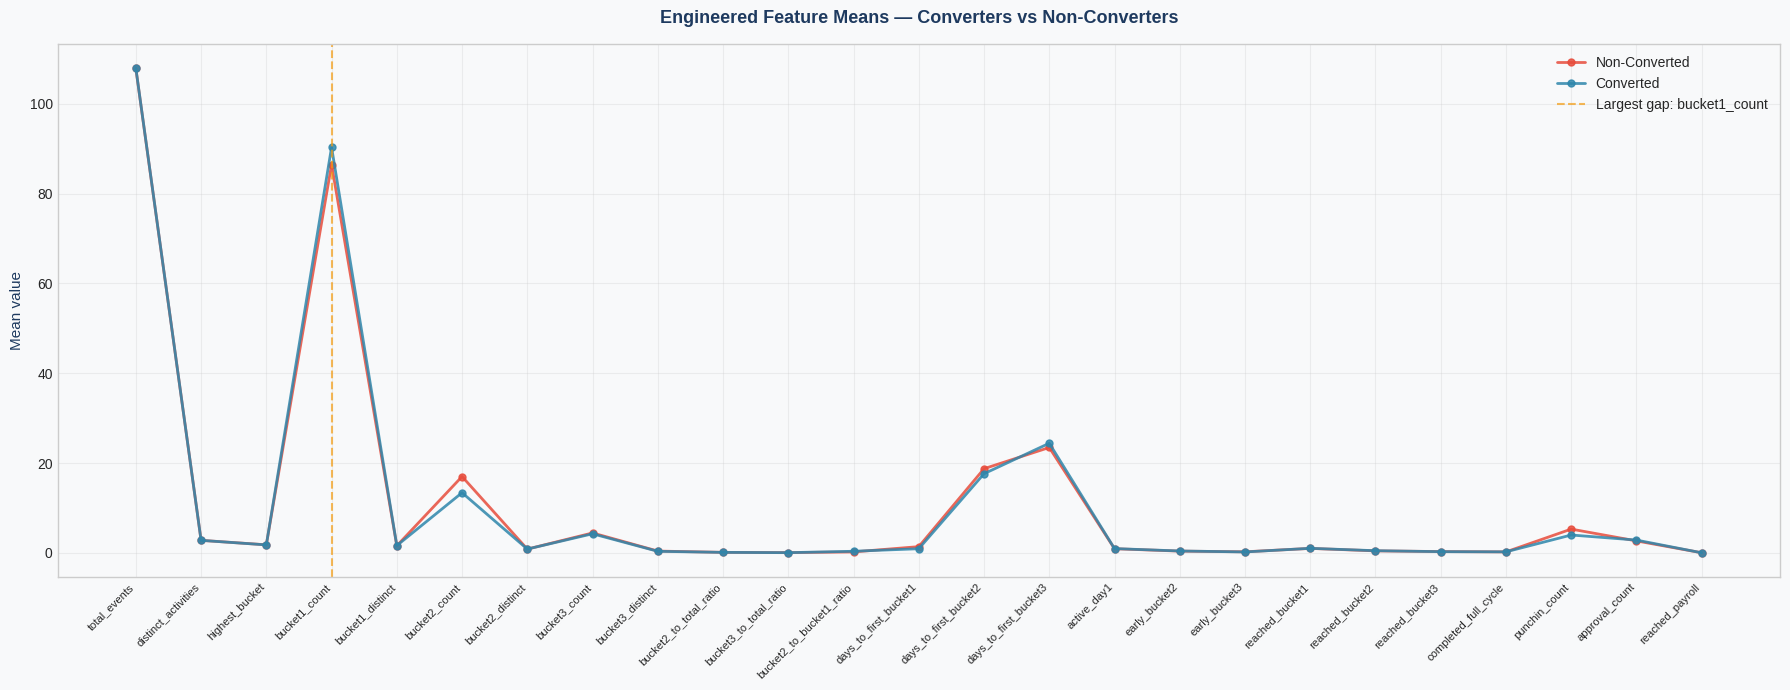

Chart saved.


In [97]:
# ── 5.2 Feature Means Visualisation ──────────────────────────────────────────

feature_means = org_features.groupby('converted')[feature_cols].mean().round(3)

# Transpose so features are on x axis
plot_data = feature_means.T.reset_index()
plot_data.columns = ['feature', 'non_converted', 'converted']

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x = np.arange(len(plot_data))

ax.plot(x, plot_data['non_converted'],
        color='#E74C3C', linewidth=2,
        marker='o', markersize=5,
        label='Non-Converted', alpha=0.85)

ax.plot(x, plot_data['converted'],
        color='#2E86AB', linewidth=2,
        marker='o', markersize=5,
        label='Converted', alpha=0.85)

# Highlight the biggest gap
gap = abs(plot_data['converted'] - plot_data['non_converted'])
max_gap_idx = gap.idxmax()
ax.axvline(max_gap_idx, color='#F39C12',
           linestyle='--', linewidth=1.5, alpha=0.7,
           label=f"Largest gap: {plot_data['feature'][max_gap_idx]}")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data['feature'],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Mean value', fontsize=11, color='#1E3A5F')
ax.set_title(
    'Engineered Feature Means — Converters vs Non-Converters',
    fontsize=13, fontweight='bold', color='#1E3A5F', pad=15
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_means_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Chart saved.")

Based on the we can see that there is little or no difference between the set of combinations of behaviors we defined of both converters and non converters but before we make a decision we defend combination we want to see what the results would once we run the logistic regression and random forest

=== LOGISTIC REGRESSION ===
Cross-validated AUC: 0.516 (+/- 0.029)

Top 10 positive coefficients (associated with conversion):
                     feature  coefficient
18           reached_bucket1     0.784371
14     days_to_first_bucket3     0.608342
15               active_day1     0.377482
12     days_to_first_bucket1     0.307400
11  bucket2_to_bucket1_ratio     0.279178
10    bucket3_to_total_ratio     0.268110
21      completed_full_cycle     0.260335
20           reached_bucket3     0.249806
17             early_bucket3     0.161820
4           bucket1_distinct     0.136442

Top 10 negative coefficients (associated with non-conversion):
                   feature  coefficient
2           highest_bucket    -0.029415
24         reached_payroll    -0.040917
22           punchin_count    -0.071690
5            bucket2_count    -0.073866
7            bucket3_count    -0.080203
8         bucket3_distinct    -0.272940
19         reached_bucket2    -0.284985
9   bucket2_to_total_ratio 

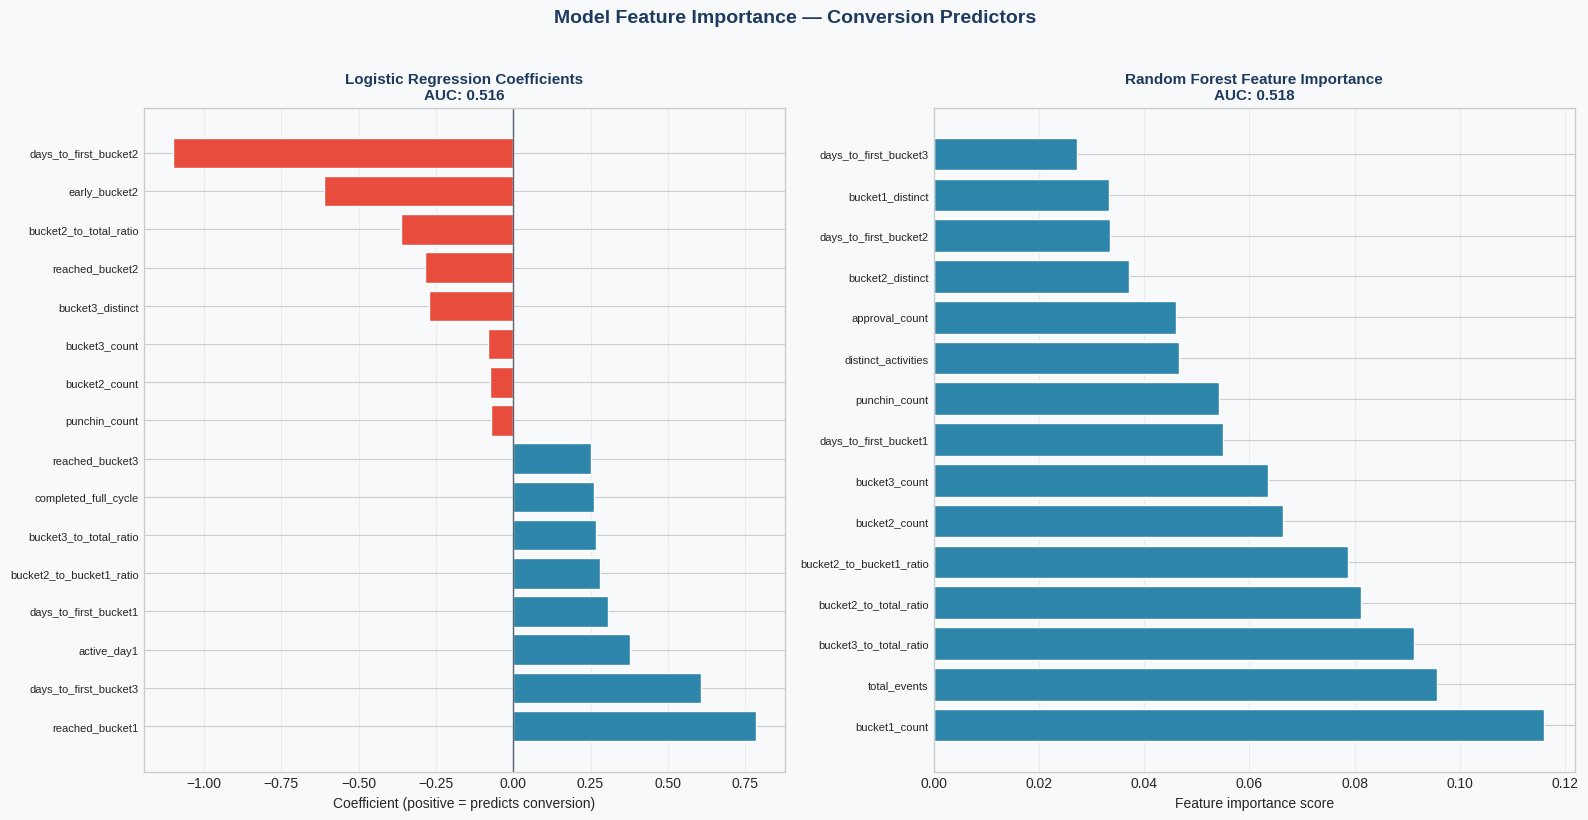

Charts saved.


In [98]:
# ── 5.2 Logistic Regression and Random Forest ─────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

feature_cols = [c for c in org_features.columns
                if c not in ['organization_id', 'converted',
                             'trial_start']]

X = org_features[feature_cols].fillna(0)
y = org_features['converted'].astype(int)

# ── Logistic Regression ───────────────────────────────────────────────────────
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

log_reg = LogisticRegression(
    max_iter=1000, random_state=42, class_weight='balanced'
)
log_reg.fit(X_scaled, y)

# Cross-validated accuracy
cv_scores = cross_val_score(
    log_reg, X_scaled, y, cv=5, scoring='roc_auc'
)

print("=== LOGISTIC REGRESSION ===")
print(f"Cross-validated AUC: {cv_scores.mean():.3f} "
      f"(+/- {cv_scores.std():.3f})")

# Coefficients
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)

print(f"\nTop 10 positive coefficients (associated with conversion):")
print(coef_df.head(10).to_string())
print(f"\nTop 10 negative coefficients (associated with non-conversion):")
print(coef_df.tail(10).to_string())

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, random_state=42,
    class_weight='balanced', max_depth=6
)
rf.fit(X, y)

rf_cv = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print("\n=== RANDOM FOREST ===")
print(f"Cross-validated AUC: {rf_cv.mean():.3f} "
      f"(+/- {rf_cv.std():.3f})")

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature importance ranking:")
print(importance_df.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Model Feature Importance — Conversion Predictors',
             fontsize=14, fontweight='bold',
             color='#1E3A5F', y=1.02)

# Chart 1 — Logistic Regression coefficients
top_coef = pd.concat([coef_df.head(8), coef_df.tail(8)])
colors   = ['#2E86AB' if c > 0 else '#E74C3C'
            for c in top_coef['coefficient']]
axes[0].set_facecolor('#F8F9FA')
axes[0].barh(
    range(len(top_coef)),
    top_coef['coefficient'],
    color=colors, edgecolor='white'
)
axes[0].set_yticks(range(len(top_coef)))
axes[0].set_yticklabels(top_coef['feature'], fontsize=8)
axes[0].axvline(0, color='#566573', linewidth=1)
axes[0].set_xlabel('Coefficient (positive = predicts conversion)',
                   fontsize=10)
axes[0].set_title(
    f'Logistic Regression Coefficients\nAUC: {cv_scores.mean():.3f}',
    fontsize=11, fontweight='bold', color='#1E3A5F'
)
axes[0].grid(True, alpha=0.3, axis='x')

# Chart 2 — Random Forest feature importance
top_importance = importance_df.head(15)
axes[1].set_facecolor('#F8F9FA')
axes[1].barh(
    range(len(top_importance)),
    top_importance['importance'],
    color='#2E86AB', edgecolor='white'
)
axes[1].set_yticks(range(len(top_importance)))
axes[1].set_yticklabels(top_importance['feature'], fontsize=8)
axes[1].set_xlabel('Feature importance score', fontsize=10)
axes[1].set_title(
    f'Random Forest Feature Importance\nAUC: {rf_cv.mean():.3f}',
    fontsize=11, fontweight='bold', color='#1E3A5F'
)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Charts saved.")

**Finding:** Both models return AUC scores near 0.5 while the  logistic
regression at 0.516 and random forest at 0.518, which is
statistically indistinguishable from random prediction. The
engineered features, despite covering volume, timing, bucket
ratios, sequence, and intensity, do not contain sufficient signal
to predict which organisations will convert.

Several coefficients are counterintuitive. Organisations that reach
Bucket 2 earlier are associated with non-conversion, while later
Bucket 3 reach is associated with conversion. This paradox suggests
that speed of engagement alone does not reflect genuine value
experience, early heavy users may be sales-assisted onboarding
rather than organic adopters.

The random forest assigns highest importance to `bucket1_count`
and `total_events`, both of which are heavily influenced by
`Scheduling.Shift.Created` instrumentation noise, further limiting
model reliability.

**Decision:** Feature set will be redefined. The current features
are either too coarse, too noisy, or measuring the wrong dimensions
of engagement.

#### **Feature Re-engineering: Workflow-Based Approach**

The bucket-based features failed to produce predictive signal because they measured activity presence and volume but not the actual operational work which organizations delivered through their operational sequence work. A manager who creates a shift but never assigns it, or who clocks staff in but never approves the timesheet, has not experienced the platform's core value, yet the bucket features treated their activity the same as an organisation that completed the full loop.

The new approach engineers features around complete workflows, sequences where every required step was performed by the same organisation. The platform shows a different usage pattern when users complete a workflow than when they show up to work because actual operational work requires real platform access.

The platform defines six operational workflows which correspond to the following operational cycles: shift management, attendance, shift flexibility, absence management, payroll readiness, and communication activation. For each workflow we build a completion flag, a cycle count, and a days-to-first-completion timing feature. Cross-workflow features then capture how many distinct workflows an organisation completed and whether they demonstrated multi-workflow engagement early in the trial.

Building workflow features — this may take a moment...
  shift_management...
  attendance...
  shift_flexibility...
  absence_management...
  payroll_readiness...
  communication...

=== WORKFLOW COMPLETION RATES BY CONVERSION STATUS ===
converted                     False  True 
shift_management_completed      0.0    0.0
attendance_completed            9.3    9.2
shift_flexibility_completed     1.7    1.5
absence_management_completed    3.9    3.4
payroll_readiness_completed     0.5    0.0
communication_activated        15.9   11.7

=== ALL FEATURE MEANS BY CONVERSION STATUS ===
converted                       False    True 
shift_management_completed      0.000    0.000
shift_management_count          0.000    0.000
days_to_first_shift_mgmt       31.000   31.000
attendance_completed            0.093    0.092
attendance_count                0.443    0.524
days_to_first_attendance       29.007   29.155
shift_flexibility_completed     0.017    0.015
absence_management_completed    0.039

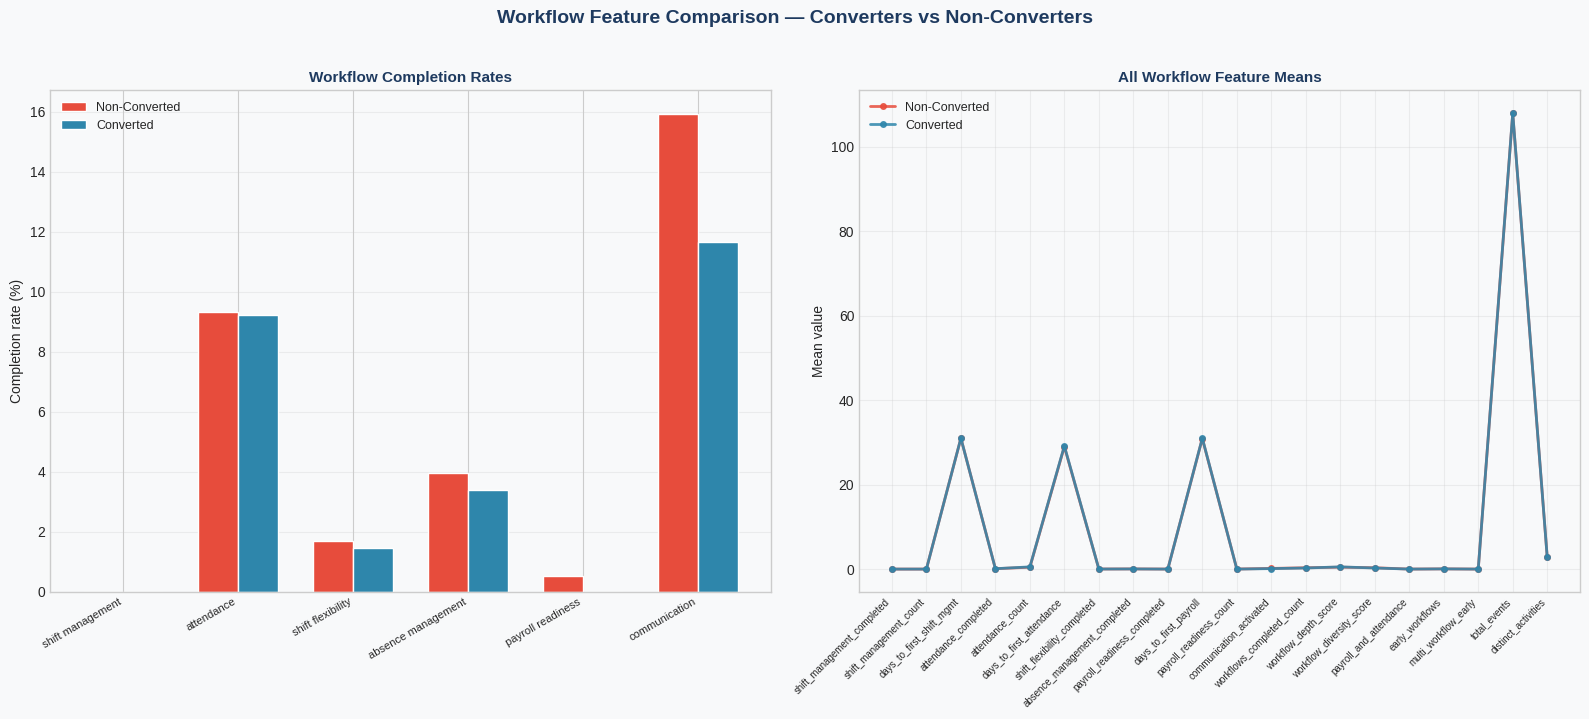

Done.


In [99]:
# ── 5.2 Workflow-Based Feature Engineering ────────────────────────────────────

org_wf = df.groupby('organization_id').agg(
    converted = ('converted', 'first')
).reset_index()

def workflow_completed(org_id, steps):
    org_events = df[df['organization_id'] == org_id].sort_values(
        'timestamp'
    )['activity_name'].tolist()
    last_idx = -1
    for step in steps:
        found = False
        for i, event in enumerate(org_events):
            if event == step and i > last_idx:
                last_idx = i
                found = True
                break
        if not found:
            return False
    return True

def workflow_count(org_id, steps):
    org_events = df[df['organization_id'] == org_id].sort_values(
        'timestamp'
    )['activity_name'].tolist()
    count    = 0
    last_idx = -1
    while True:
        current_idx = last_idx
        completed   = True
        for step in steps:
            found = False
            for i, event in enumerate(org_events):
                if event == step and i > current_idx:
                    current_idx = i
                    found       = True
                    break
            if not found:
                completed = False
                break
        if completed:
            count    += 1
            last_idx  = current_idx
        else:
            break
    return count

def days_to_first_workflow(org_id, steps):
    org_df     = df[df['organization_id'] == org_id].sort_values('timestamp')
    org_events = org_df['activity_name'].tolist()
    org_days   = org_df['day_of_trial'].tolist()
    last_idx   = -1
    last_day   = 31
    for step in steps:
        for i, event in enumerate(org_events):
            if event == step and i > last_idx:
                last_idx = i
                last_day = org_days[i]
                break
        else:
            return 31
    return last_day

# ── Define workflows ──────────────────────────────────────────────────────────
workflows = {
    'shift_management': [
        'Scheduling.Shift.Created',
        'Scheduling.ShiftAssignmentChanged',
        'Scheduling.Shift.Approved'
    ],
    'attendance': [
        'PunchClock.PunchedIn',
        'Scheduling.Shift.Approved'
    ],
    'payroll_readiness': [
        'Timesheets.BulkApprove.Confirmed',
        'Integration.Xero.PayrollExport.Synced'
    ],
}

flex_pairs = [
    ('Scheduling.ShiftSwap.Created',        'Scheduling.ShiftSwap.Accepted'),
    ('Scheduling.ShiftHandover.Created',    'Scheduling.ShiftHandover.Accepted'),
    ('Scheduling.OpenShiftRequest.Created', 'Scheduling.OpenShiftRequest.Approved'),
]

absence_orgs_created  = set(df[
    df['activity_name'] == 'Absence.Request.Created'
]['organization_id'])
absence_orgs_resolved = set(df[
    df['activity_name'].isin([
        'Absence.Request.Approved', 'Absence.Request.Rejected'
    ])
]['organization_id'])
absence_completed = absence_orgs_created & absence_orgs_resolved

orgs = org_wf['organization_id'].tolist()
print("Building workflow features — this may take a moment...")

# ── Shift Management ──────────────────────────────────────────────────────────
print("  shift_management...")
sm_completed, sm_count, sm_days = [], [], []
for org in orgs:
    steps = workflows['shift_management']
    c = workflow_completed(org, steps)
    sm_completed.append(int(c))
    sm_count.append(workflow_count(org, steps) if c else 0)
    sm_days.append(days_to_first_workflow(org, steps))

org_wf['shift_management_completed'] = sm_completed
org_wf['shift_management_count']     = sm_count
org_wf['days_to_first_shift_mgmt']   = sm_days

# ── Attendance ────────────────────────────────────────────────────────────────
print("  attendance...")
att_completed, att_count, att_days = [], [], []
for org in orgs:
    steps = workflows['attendance']
    c = workflow_completed(org, steps)
    att_completed.append(int(c))
    att_count.append(workflow_count(org, steps) if c else 0)
    att_days.append(days_to_first_workflow(org, steps))

org_wf['attendance_completed']     = att_completed
org_wf['attendance_count']         = att_count
org_wf['days_to_first_attendance'] = att_days

# ── Shift Flexibility ─────────────────────────────────────────────────────────
print("  shift_flexibility...")
flex_completed_list = []
for org in orgs:
    org_acts  = set(df[df['organization_id'] == org]['activity_name'].tolist())
    completed = any(
        a in org_acts and b in org_acts
        for a, b in flex_pairs
    )
    flex_completed_list.append(int(completed))

org_wf['shift_flexibility_completed'] = flex_completed_list

# ── Absence Management ────────────────────────────────────────────────────────
print("  absence_management...")
org_wf['absence_management_completed'] = org_wf['organization_id'].isin(
    absence_completed
).astype(int)

# ── Payroll Readiness ─────────────────────────────────────────────────────────
print("  payroll_readiness...")
pr_completed, pr_days = [], []
for org in orgs:
    steps = workflows['payroll_readiness']
    c = workflow_completed(org, steps)
    pr_completed.append(int(c))
    pr_days.append(days_to_first_workflow(org, steps))

org_wf['payroll_readiness_completed'] = pr_completed
org_wf['days_to_first_payroll']       = pr_days
org_wf['payroll_readiness_count']     = [
    workflow_count(org, workflows['payroll_readiness'])
    for org in orgs
]

# ── Communication Activation ──────────────────────────────────────────────────
print("  communication...")
comm_orgs = set(df[
    df['activity_name'] == 'Communication.Message.Created'
]['organization_id'])
org_wf['communication_activated'] = org_wf['organization_id'].isin(
    comm_orgs
).astype(int)

# ── Cross-Workflow Features ───────────────────────────────────────────────────
wf_binary_cols = [
    'shift_management_completed',
    'attendance_completed',
    'shift_flexibility_completed',
    'absence_management_completed',
    'payroll_readiness_completed',
    'communication_activated'
]

# Workflows completed count — diversity signal
org_wf['workflows_completed_count'] = org_wf[wf_binary_cols].sum(axis=1)

# Workflow depth score — intensity signal
org_wf['workflow_depth_score'] = (
    org_wf['shift_management_count'] +
    org_wf['attendance_count']       +
    org_wf['payroll_readiness_count']
)

# Workflow diversity score — distinct workflows completed
org_wf['workflow_diversity_score'] = org_wf[wf_binary_cols].sum(axis=1)

# Payroll and attendance combined
org_wf['payroll_and_attendance'] = (
    (org_wf['payroll_readiness_completed'] == 1) &
    (org_wf['attendance_completed']        == 1)
).astype(int)

# Multi-workflow early — 2+ workflows completed within first 7 days
timing_cols = [
    'days_to_first_shift_mgmt',
    'days_to_first_attendance',
    'days_to_first_payroll'
]
org_wf['early_workflows'] = org_wf[timing_cols].apply(
    lambda r: (r <= 7).sum(), axis=1
)
org_wf['multi_workflow_early'] = (
    org_wf['early_workflows'] >= 2
).astype(int)

# ── Control Variables ─────────────────────────────────────────────────────────
org_ctrl = df.groupby('organization_id').agg(
    total_events        = ('activity_name', 'count'),
    distinct_activities = ('activity_name', 'nunique')
).reset_index()
org_wf = org_wf.merge(org_ctrl, on='organization_id', how='left')

# ── Summary ───────────────────────────────────────────────────────────────────
wf_feature_cols = [c for c in org_wf.columns
                   if c not in ['organization_id', 'converted']]

print("\n=== WORKFLOW COMPLETION RATES BY CONVERSION STATUS ===")
completion_summary = (
    org_wf.groupby('converted')[wf_binary_cols].mean() * 100
)
print(completion_summary.round(1).T.to_string())

print("\n=== ALL FEATURE MEANS BY CONVERSION STATUS ===")
print(org_wf.groupby('converted')[wf_feature_cols].mean().round(3).T.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Workflow Feature Comparison — Converters vs Non-Converters',
             fontsize=14, fontweight='bold', color='#1E3A5F', y=1.02)

conv_rates     = completion_summary.loc[True]
non_conv_rates = completion_summary.loc[False]
x = np.arange(len(wf_binary_cols))
w = 0.35

axes[0].set_facecolor('#F8F9FA')
axes[0].bar(x - w/2, non_conv_rates, w,
            color='#E74C3C', label='Non-Converted', edgecolor='white')
axes[0].bar(x + w/2, conv_rates, w,
            color='#2E86AB', label='Converted', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [c.replace('_completed', '').replace('_activated', '')
      .replace('_', ' ')
     for c in wf_binary_cols],
    rotation=30, ha='right', fontsize=8
)
axes[0].set_ylabel('Completion rate (%)', fontsize=10)
axes[0].set_title('Workflow Completion Rates',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Line chart of all feature means
plot_data = org_wf.groupby('converted')[wf_feature_cols].mean().T
axes[1].set_facecolor('#F8F9FA')
axes[1].plot(
    range(len(plot_data)), plot_data[False],
    color='#E74C3C', linewidth=2,
    marker='o', markersize=4,
    label='Non-Converted', alpha=0.85
)
axes[1].plot(
    range(len(plot_data)), plot_data[True],
    color='#2E86AB', linewidth=2,
    marker='o', markersize=4,
    label='Converted', alpha=0.85
)
axes[1].set_xticks(range(len(plot_data)))
axes[1].set_xticklabels(
    plot_data.index,
    rotation=45, ha='right', fontsize=7
)
axes[1].set_ylabel('Mean value', fontsize=10)
axes[1].set_title('All Workflow Feature Means',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('workflow_features.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Done.")

At a glance We see no improvement from the feature engineering but we run it on the logistic so be 100 percent sure of the result we are getting from here

=== LOGISTIC REGRESSION ===
Cross-validated AUC: 0.498 (+/- 0.051)

Top 10 positive coefficients:
                       feature  coefficient
5     days_to_first_attendance     0.394443
19         distinct_activities     0.225013
3         attendance_completed     0.211191
16             early_workflows     0.197650
9        days_to_first_payroll     0.127335
4             attendance_count     0.045848
13        workflow_depth_score     0.036189
0   shift_management_completed     0.000000
2     days_to_first_shift_mgmt     0.000000
1       shift_management_count     0.000000

Top 10 negative coefficients:
                         feature  coefficient
17          multi_workflow_early     0.000000
18                  total_events    -0.017151
6    shift_flexibility_completed    -0.031360
12     workflows_completed_count    -0.049698
14      workflow_diversity_score    -0.049698
15        payroll_and_attendance    -0.055758
7   absence_management_completed    -0.062595
10       payroll_re

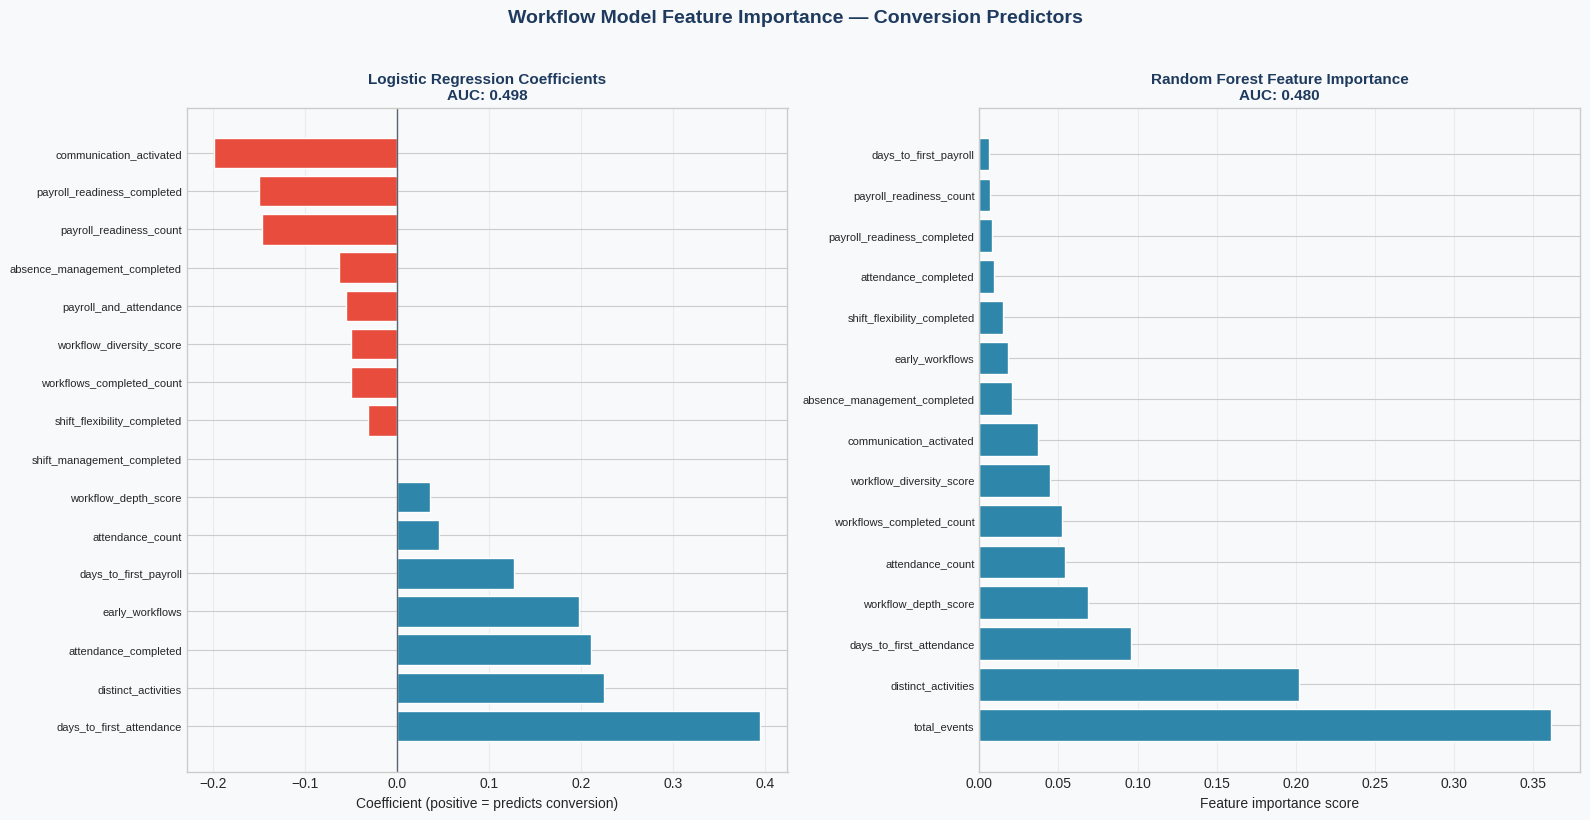

Charts saved.


In [100]:
# ── 5.2 Workflow Model — Logistic Regression and Random Forest ────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

wf_feature_cols = [c for c in org_wf.columns
                   if c not in ['organization_id', 'converted']]

X = org_wf[wf_feature_cols].fillna(0)
y = org_wf['converted'].astype(int)

# ── Logistic Regression ───────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(
    max_iter=1000, random_state=42, class_weight='balanced'
)
log_reg.fit(X_scaled, y)
cv_scores = cross_val_score(
    log_reg, X_scaled, y, cv=5, scoring='roc_auc'
)

print("=== LOGISTIC REGRESSION ===")
print(f"Cross-validated AUC: {cv_scores.mean():.3f} "
      f"(+/- {cv_scores.std():.3f})")

coef_df = pd.DataFrame({
    'feature':     wf_feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)

print(f"\nTop 10 positive coefficients:")
print(coef_df.head(10).to_string())
print(f"\nTop 10 negative coefficients:")
print(coef_df.tail(10).to_string())

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, random_state=42,
    class_weight='balanced', max_depth=6
)
rf.fit(X, y)
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print("\n=== RANDOM FOREST ===")
print(f"Cross-validated AUC: {rf_cv.mean():.3f} "
      f"(+/- {rf_cv.std():.3f})")

importance_df = pd.DataFrame({
    'feature':    wf_feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature importance ranking:")
print(importance_df.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Workflow Model Feature Importance — Conversion Predictors',
             fontsize=14, fontweight='bold', color='#1E3A5F', y=1.02)

top_coef  = pd.concat([coef_df.head(8), coef_df.tail(8)])
colors    = ['#2E86AB' if c > 0 else '#E74C3C'
             for c in top_coef['coefficient']]
axes[0].set_facecolor('#F8F9FA')
axes[0].barh(range(len(top_coef)), top_coef['coefficient'],
             color=colors, edgecolor='white')
axes[0].set_yticks(range(len(top_coef)))
axes[0].set_yticklabels(top_coef['feature'], fontsize=8)
axes[0].axvline(0, color='#566573', linewidth=1)
axes[0].set_xlabel('Coefficient (positive = predicts conversion)',
                   fontsize=10)
axes[0].set_title(
    f'Logistic Regression Coefficients\nAUC: {cv_scores.mean():.3f}',
    fontsize=11, fontweight='bold', color='#1E3A5F'
)
axes[0].grid(True, alpha=0.3, axis='x')

top_imp = importance_df.head(15)
axes[1].set_facecolor('#F8F9FA')
axes[1].barh(range(len(top_imp)), top_imp['importance'],
             color='#2E86AB', edgecolor='white')
axes[1].set_yticks(range(len(top_imp)))
axes[1].set_yticklabels(top_imp['feature'], fontsize=8)
axes[1].set_xlabel('Feature importance score', fontsize=10)
axes[1].set_title(
    f'Random Forest Feature Importance\nAUC: {rf_cv.mean():.3f}',
    fontsize=11, fontweight='bold', color='#1E3A5F'
)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('workflow_model_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Charts saved.")

The AUC score here was much lower than the initial feature engineering

**Additional Feature Engineering, Window and Consistency Based**

As a final attempt to surface conversion signal, we engineer time-windowed
features focused on early trial behaviour (Days 1–7), recency of engagement
(Days 23–30), activity consistency across distinct active days, and maximum
consecutive day streaks, testing whether when and how consistently
organisations engage predicts conversion better than what they did overall.

Calculating streaks — this may take a moment...

=== WINDOW FEATURE MEANS BY CONVERSION STATUS ===
converted                   False   True 
early_total_events         35.274  39.277
early_distinct_activities   2.170   2.180
early_bucket1_count        28.525  34.073
early_bucket2_count         5.183   3.534
early_bucket3_count         1.566   1.670
late_total_events          72.637  68.714
late_bucket2_count         11.813   9.859
late_bucket3_count          2.859   2.568
days_active                 4.289   4.209
early_days_active           1.779   1.796
recent_total_events        28.564  25.107
recent_bucket2_count        4.667   4.655
max_streak                  2.968   2.816
early_bucket2_ratio         0.088   0.078
dropped_off                 0.726   0.723


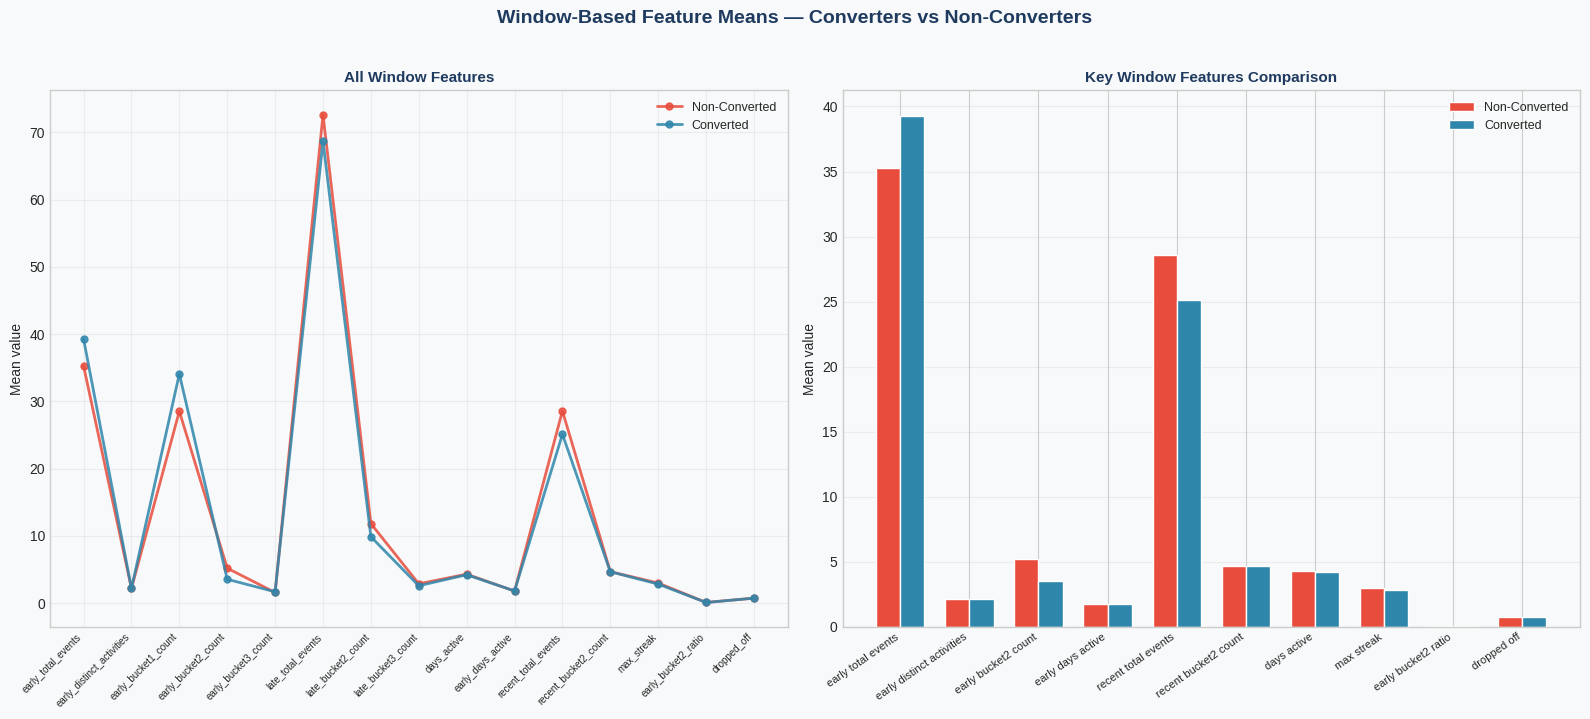

Done.


In [101]:
# ── Window-Based Feature Engineering (Days 1-7) ───────────────────────────────

org_window = df.groupby('organization_id').agg(
    converted = ('converted', 'first')
).reset_index()

# Early window events — Days 1 to 7 only
df_early = df[df['day_of_trial'] <= 7]
df_late  = df[df['day_of_trial'] > 7]

# Event counts in early window
early_counts = df_early.groupby('organization_id').agg(
    early_total_events        = ('activity_name', 'count'),
    early_distinct_activities = ('activity_name', 'nunique'),
    early_bucket1_count       = ('activity_bucket', lambda x: (x==1).sum()),
    early_bucket2_count       = ('activity_bucket', lambda x: (x==2).sum()),
    early_bucket3_count       = ('activity_bucket', lambda x: (x==3).sum()),
).reset_index()

org_window = org_window.merge(early_counts, on='organization_id', how='left').fillna(0)

# Event counts in late window
late_counts = df_late.groupby('organization_id').agg(
    late_total_events   = ('activity_name', 'count'),
    late_bucket2_count  = ('activity_bucket', lambda x: (x==2).sum()),
    late_bucket3_count  = ('activity_bucket', lambda x: (x==3).sum()),
).reset_index()

org_window = org_window.merge(late_counts, on='organization_id', how='left').fillna(0)

# Consistency — number of distinct days active
days_active = df.groupby('organization_id')['day_of_trial'].nunique().reset_index()
days_active.columns = ['organization_id', 'days_active']
org_window = org_window.merge(days_active, on='organization_id', how='left')

# Early consistency — distinct days active in first 7 days
early_days = df_early.groupby('organization_id')['day_of_trial'].nunique().reset_index()
early_days.columns = ['organization_id', 'early_days_active']
org_window = org_window.merge(early_days, on='organization_id', how='left').fillna(0)

# Recency — events in last 7 days of trial
df_recent = df[df['day_of_trial'] >= 23]
recent_counts = df_recent.groupby('organization_id').agg(
    recent_total_events  = ('activity_name', 'count'),
    recent_bucket2_count = ('activity_bucket', lambda x: (x==2).sum()),
).reset_index()
org_window = org_window.merge(recent_counts, on='organization_id', how='left').fillna(0)

# Streak — max consecutive days active
def max_streak(org_id):
    days = sorted(df[df['organization_id']==org_id]['day_of_trial'].unique())
    if not days:
        return 0
    max_s = cur_s = 1
    for i in range(1, len(days)):
        if days[i] == days[i-1] + 1:
            cur_s += 1
            max_s  = max(max_s, cur_s)
        else:
            cur_s = 1
    return max_s

print("Calculating streaks — this may take a moment...")
org_window['max_streak'] = [max_streak(org) for org in org_window['organization_id']]

# Early bucket2 ratio
org_window['early_bucket2_ratio'] = (
    org_window['early_bucket2_count'] /
    org_window['early_total_events'].replace(0, np.nan)
).fillna(0)

# Drop-off flag — active early but not late
org_window['dropped_off'] = (
    (org_window['early_total_events'] > 0) &
    (org_window['late_total_events']  == 0)
).astype(int)

# ── Summary ───────────────────────────────────────────────────────────────────
window_feature_cols = [c for c in org_window.columns
                       if c not in ['organization_id', 'converted']]

print("\n=== WINDOW FEATURE MEANS BY CONVERSION STATUS ===")
print(org_window.groupby('converted')[window_feature_cols].mean().round(3).T.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Window-Based Feature Means — Converters vs Non-Converters',
             fontsize=14, fontweight='bold', color='#1E3A5F', y=1.02)

plot_data = org_window.groupby('converted')[window_feature_cols].mean().T

axes[0].set_facecolor('#F8F9FA')
axes[0].plot(range(len(plot_data)), plot_data[False],
             color='#E74C3C', linewidth=2, marker='o',
             markersize=5, label='Non-Converted', alpha=0.85)
axes[0].plot(range(len(plot_data)), plot_data[True],
             color='#2E86AB', linewidth=2, marker='o',
             markersize=5, label='Converted', alpha=0.85)
axes[0].set_xticks(range(len(plot_data)))
axes[0].set_xticklabels(plot_data.index, rotation=45,
                        ha='right', fontsize=7)
axes[0].set_ylabel('Mean value', fontsize=10)
axes[0].set_title('All Window Features', fontsize=11,
                  fontweight='bold', color='#1E3A5F')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Chart 2 — Focus on most promising features only
focus_features = [
    'early_total_events', 'early_distinct_activities',
    'early_bucket2_count', 'early_days_active',
    'recent_total_events', 'recent_bucket2_count',
    'days_active', 'max_streak',
    'early_bucket2_ratio', 'dropped_off'
]
focus_data = org_window.groupby('converted')[focus_features].mean().T
x = np.arange(len(focus_features))
w = 0.35

axes[1].set_facecolor('#F8F9FA')
axes[1].bar(x - w/2, focus_data[False], w,
            color='#E74C3C', label='Non-Converted', edgecolor='white')
axes[1].bar(x + w/2, focus_data[True], w,
            color='#2E86AB', label='Converted', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f.replace('_', ' ') for f in focus_features],
    rotation=35, ha='right', fontsize=8
)
axes[1].set_ylabel('Mean value', fontsize=10)
axes[1].set_title('Key Window Features Comparison',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('window_features.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Done.")

**There is still no impromment here also**

But before we close this section, We want to run a single consolidated diagnostic check. The purpose is not to build new features, it is purely to confirm that the weak model performance is not caused by poor feature engineering, but by a more fundamental issue in the data itself.

In [102]:
# ── Section 5 Diagnostic — Confirming Root Cause of Weak Model Performance ────

print("=" * 65)
print("DIAGNOSTIC: WHY DID THE MODELS FAIL?")
print("=" * 65)

# ── Diagnostic 1: Workflow touch and completion rates ─────────────────────────
print("\n--- DIAGNOSTIC 1: WORKFLOW SIGNAL CHECK ---")
print(f"{'Workflow':<30} {'Touched':>8} {'Touch CR%':>10} "
      f"{'Completed':>10} {'Complete CR%':>13}")
print("-" * 75)

workflow_checks = {
    'Shift Management': {
        'touch': ['Scheduling.Shift.Created',
                  'Scheduling.ShiftAssignmentChanged',
                  'Scheduling.Shift.Approved'],
        'complete_col': 'shift_management_completed'
    },
    'Attendance': {
        'touch': ['PunchClock.PunchedIn',
                  'Scheduling.Shift.Approved'],
        'complete_col': 'attendance_completed'
    },
    'Shift Flexibility': {
        'touch': ['Scheduling.ShiftSwap.Created',
                  'Scheduling.ShiftHandover.Created',
                  'Scheduling.OpenShiftRequest.Created'],
        'complete_col': 'shift_flexibility_completed'
    },
    'Absence Management': {
        'touch': ['Absence.Request.Created',
                  'Absence.Request.Approved',
                  'Absence.Request.Rejected'],
        'complete_col': 'absence_management_completed'
    },
    'Payroll Readiness': {
        'touch': ['Timesheets.BulkApprove.Confirmed',
                  'Integration.Xero.PayrollExport.Synced'],
        'complete_col': 'payroll_readiness_completed'
    },
    'Communication': {
        'touch': ['Communication.Message.Created'],
        'complete_col': 'communication_activated'
    },
}

org_meta_diag = df.groupby('organization_id').agg(
    converted = ('converted', 'first')
).reset_index()

for wf_name, wf_info in workflow_checks.items():
    # Touched — used any component
    touched_orgs = df[
        df['activity_name'].isin(wf_info['touch'])
    ]['organization_id'].unique()
    n_touched    = len(touched_orgs)
    touch_cr     = org_meta_diag[
        org_meta_diag['organization_id'].isin(touched_orgs)
    ]['converted'].mean() * 100

    # Completed
    if wf_info['complete_col'] in org_wf.columns:
        completed = org_wf[org_wf[wf_info['complete_col']] == 1]
        n_complete  = len(completed)
        complete_cr = completed['converted'].mean() * 100 if n_complete > 0 else 0
    else:
        n_complete  = 0
        complete_cr = 0

    print(f"{wf_name:<30} {n_touched:>8,} {touch_cr:>9.1f}% "
          f"{n_complete:>10,} {complete_cr:>12.1f}%")

print(f"\n{'Baseline conversion rate':>44} {'21.3%':>13}")

# ── Diagnostic 2: Typical org engagement profile ──────────────────────────────
print("\n--- DIAGNOSTIC 2: TYPICAL ORG ENGAGEMENT PROFILE ---")

org_engagement = df.groupby('organization_id').agg(
    total_events        = ('activity_name', 'count'),
    distinct_activities = ('activity_name', 'nunique'),
    last_day_active     = ('day_of_trial', 'max'),
    converted           = ('converted', 'first')
).reset_index()

for group, label in [(True, 'Converters'), (False, 'Non-Converters')]:
    subset = org_engagement[org_engagement['converted'] == group]
    print(f"\n  {label} (n={len(subset):,}):")
    print(f"    Median total events:        {subset['total_events'].median():.0f}")
    print(f"    Median distinct activities: {subset['distinct_activities'].median():.0f}")
    print(f"    Median last day active:     {subset['last_day_active'].median():.0f}")
    print(f"    % active beyond Day 7:      "
          f"{(subset['last_day_active'] > 7).mean()*100:.1f}%")
    print(f"    % active beyond Day 14:     "
          f"{(subset['last_day_active'] > 14).mean()*100:.1f}%")

# ── Diagnostic 3: One-touch organisations ─────────────────────────────────────
print("\n--- DIAGNOSTIC 3: ONE-TOUCH ORGANISATIONS ---")

one_touch = org_engagement[org_engagement['last_day_active'] == 0]
n_one_touch    = len(one_touch)
pct_one_touch  = n_one_touch / len(org_engagement) * 100
one_touch_cr   = one_touch['converted'].mean() * 100

multi_touch    = org_engagement[org_engagement['last_day_active'] > 0]
multi_touch_cr = multi_touch['converted'].mean() * 100

print(f"\n  One-touch orgs (active Day 0 only): "
      f"{n_one_touch:,} ({pct_one_touch:.1f}% of all orgs)")
print(f"  One-touch conversion rate:          {one_touch_cr:.1f}%")
print(f"  Multi-touch conversion rate:        {multi_touch_cr:.1f}%")
print(f"  Baseline conversion rate:           21.3%")

print(f"\n  Breakdown of one-touch orgs:")
print(f"    Converted:     "
      f"{one_touch['converted'].sum():,} "
      f"({one_touch['converted'].mean()*100:.1f}%)")
print(f"    Not converted: "
      f"{(one_touch['converted']==False).sum():,} "
      f"({(one_touch['converted']==False).mean()*100:.1f}%)")

print("\n" + "=" * 65)
print("END DIAGNOSTIC")
print("=" * 65)

DIAGNOSTIC: WHY DID THE MODELS FAIL?

--- DIAGNOSTIC 1: WORKFLOW SIGNAL CHECK ---
Workflow                        Touched  Touch CR%  Completed  Complete CR%
---------------------------------------------------------------------------
Shift Management                    848      21.8%          0          0.0%
Attendance                          304      22.7%         90         21.1%
Shift Flexibility                    51      27.5%         16         18.8%
Absence Management                   40      20.0%         37         18.9%
Payroll Readiness                    12       8.3%          4          0.0%
Communication                       145      16.6%        145         16.6%

                    Baseline conversion rate         21.3%

--- DIAGNOSTIC 2: TYPICAL ORG ENGAGEMENT PROFILE ---

  Converters (n=206):
    Median total events:        8
    Median distinct activities: 2
    Median last day active:     0
    % active beyond Day 7:      27.7%
    % active beyond Day 14:     2

### **Section 5 Diagnostic, Confirming the Root Cause**

Before closing Section 5, a consolidated diagnostic was run to confirm
that the weak model performance reflects a fundamental data characteristic
rather than a feature engineering failure.

**Diagnostic 1, Workflow Signal Check**
Every workflow was tested for both touch rate and completion rate against
the 21.3% baseline. No workflow produces a conversion rate meaningfully
above baseline when completed. Shift Management was touched by 848
organisations at 21.8% conversion, indistinguishable from the baseline.
Payroll Readiness converts at 8.3% among the 12 organisations that touched
it, below baseline. The signal is absent regardless of how workflows are
defined.

**Diagnostic 2, Typical Engagement Profile**
The median organisation, converter and non-converter alike, has 8 total
events, 2 distinct activity types, and a last active day of Day 0. Only
27.7% of converters were active beyond Day 7. The typical trialist barely
used the platform, making behavioural prediction structurally impossible
for the majority of the population.

**Diagnostic 3, One-Touch Organisations**
58.2% of all organisations, 562 out of 966, were only active on Day 0
of their trial. Their conversion rate is 21.5%, statistically identical
to the 21.0% rate for organisations that returned on multiple days. An
organisation that used the platform once converts at the same rate as one
that used it for two weeks.

**Conclusion**
The models did not fail because of poor feature engineering. They failed
because the majority of organisations did not generate enough in-trial
behaviour to produce a detectable signal. For 58% of trialists, conversion
appears to be decided independently of platform usage, likely through
sales conversations, pricing evaluations, or internal procurement decisions
that occur outside the event log.

This finding has a direct and important implication for trial goal
definition: activation goals cannot be validated as conversion predictors
using this dataset alone. They must instead be grounded in product-value
logic, defining what genuine platform experience looks like operationally , and presented honestly as evidence-informed hypotheses about what should
drive conversion, not proven statistical levers. This is the approach
taken in Section 6.

## **Section 6 Trial Goal Definition**

### **6.0 Why We Define Goals Through Product Logic**

The analysis in Section 5 established that in-trial behavioural data
alone cannot statistically predict which organisations will convert. The first day of the trial showed 58% of participants who only at that time. The combination of activity flags with engineered features and workflow completion sequences failed to achieve model performance that exceeded random chance. The analysis failed because it produced an actual finding which demonstrated that Splendor conversion decisions depend more on external factors than internal event logs.

The discovery does not remove the importance of establishing trial activation. The discovery determines our definition of the term. Our goals use product-value logic as our foundation instead of relying on statistical prediction which creates goals. Our company requires its users to demonstrate actual product engagement in order to achieve platform experience. Our company uses each available evidence to support our goals. Every goal requires presentation as an evidence-informed hypothesis which functions as a conversion hypothesis instead of a conversion driver. The data requires this method as the honest and professionally responsible method to approach research.

### **6.1 The Activation Framework**

The activation trial process establishes the essential product usage criteria which organizations must meet to demonstrate they have fully realized the main advantages of the Splendor platform through actual operational application of its features.

**Who activation is designed for**

The diagnostic established that 562 out of 966 trialling organisations were active only on Day 0 of their trial. These organisations never
meaningfully engaged with the platform. This group does not meet the activation goals requirements because their conversion decision occurred without using the platform and producting any intervention to change their results.

The 404 organizations who returned to the platform on at least one subsequent day are known as activation group because they represent 41.8 percent of all trialists. The engaged population uses activation to measure their understanding of platform value which separates them from people who only interacted with the platform but did not complete important business processes.

**The product this activation framework serves**

Splendor is a workforce management platform whose core value is
connecting the planning of work, scheduling, to the execution of
work, attendance and time tracking, to the financial close of work , payroll and approvals. An organisation that completes this loop,
even once, has experienced what the product is designed to deliver.
The activation goals below define the milestones along that loop.

### **6.2 Trial Goal Definitions**

Four goals define trial activation. Each goal represents a distinct
milestone in the operational loop the platform is designed to support.
Together they describe an organisation that has moved from exploring
the platform to running their operations through it.

---

**Goal 1 Schedule Published**

*Definition:* The organisation created at least one shift during their
trial using `Scheduling.Shift.Created`.

**Evidence:** 848 out of 966 organisations tested the shift management system during their testing process. The platform entry point requires users to create a published schedule because all other platform functions remain inaccessible until they do so. The system requires this element to function but it does not automatically start the process.

**Product logic:** The platform's operational loop begins with a manager building a schedule. The system requires an existing schedule before it can use its functions for shift assignments **attendance** tracking absence management approvals and payroll processing. An organisation that has not published a schedule has not started the operational loop. This goal confirms the loop has begun.

**Caveat:** The goal does not produce any individual conversion increase because almost everyone adopts it. The organization has made an attempt to use the platform through its primary function which serves as the gateway requirement for this value.

---

**Goal 2 Team Operational**

*Definition:* The organisation recorded at least one
`PunchClock.PunchedIn` event during their trial, indicating that
employees are actively using the platform as part of their daily
workflow.

**Evidence:** The trial testing showed that 211 organizations achieved punch clock worktime which represents 21.8 percent of all participating trialists. The group demonstrates a 22.7 percent conversion rate which exceeds the baseline of 21.3 percent and this marks the evolution from manager evaluation system to team operational assessment system.

**Product Logic:** The system operates in two stages: when employees start work through the platform their manager finishes team training. The platform has evolved from a scheduling application which one user tested into an operational system which all employees use. The most public indicator shows that the platform now operates as a permanent part of daily work procedures instead of remaining separate from existing workflow systems.

Caveat: The conversion increase at this objective shows only slight improvement. The signal shows how the system has been operationalized but it does not demonstrate actual conversion capabilities. Organizations that achieve this benchmark demonstrate higher dedication to their assessment process although they will not necessarily achieve conversion.

---

**Goal 3 Management Decision Recorded**

*Definition:* The organisation performed at least one deliberate
management action through the platform either `Scheduling.Shift.Approved`,
`Absence.Request.Approved`, or `Absence.Request.Rejected` during
their trial.

**Evidence:** The platform functions as the official system through which managers execute their approval processes and absence management duties. The businesses have progressed from their initial phase of schedule creation to their current state of conducting their daily operations.

**Product logic:** A manager who approves shifts or processes absence requests through the platform has made the platform their system of record for operational decisions. The platform has become the official channel through which workforce decisions will be documented and shared this time. The system maintains its operational efficiency because operational decisions that users record in the platform become permanent records which organizational rules prevent from being deleted.

**Caveat:** This goal captures a deliberate managerial behaviour but like all goals in this framework, correlation with conversion cannot be established from the available data. The organizations which use the platform for making management decisions display higher operational maturity which leads them to convert for reasons that exist beyond their particular actions.

---

**Goal 4 Sustained Engagement**

*Definition:* The organisation was active on at least three distinct
calendar days during their trial.

**Evidence:** The diagnostic test results showed that 72.3 percent of all organizations which included converters and non-converters worked only during the first day of operation. The converters who remained active after Day 7 showed sustained engagement which served as their most obvious distinction from the majority who only made one contact. The minimum requirement to prove actual assessment activities requires participants to take part in three different active days which they must complete to demonstrate their dedication to their work.

**Product logic:** A single day of platform activity could be
curiosity-driven exploration with no intent to adopt. Activity spread across three or more separate days indicates the manager
returned to the platform because it was useful — not just because
they were evaluating it for the first time. The first sign of habit formation develops through recurring usage which then leads to users becoming dependent on the platform.

**Caveat:** Three days is a conservative threshold chosen to be
achievable for motivated trialists while filtering out one-session
explorers. The measurement serves as an engagement depth measurement but it does not demonstrate actual value creation. The threshold requires evaluation and adjustment after organizations gather additional post-conversion behavior information.

### **6.3 Activation Threshold and Current Activation Rate**

An organisation achieves Trial Activation when it has completed all
four goals during its trial period. This section calculates how many
current trialists meet the activation threshold and what their
conversion rate is, the primary validation check for the framework.

=== INDIVIDUAL GOAL COMPLETION RATES ===
  goal1_schedule_published             848 orgs  ( 87.8%)  Conv rate: 21.8%
  goal2_team_operational               211 orgs  ( 21.8%)  Conv rate: 22.7%
  goal3_management_decision            214 orgs  ( 22.2%)  Conv rate: 22.0%
  goal4_sustained_engagement           253 orgs  ( 26.2%)  Conv rate: 23.3%

=== TRIAL ACTIVATION SUMMARY ===
Total organisations:          966
Activated (all 4 goals):      104  (10.8%)
Not activated:                862  (89.2%)

=== CONVERSION RATE BY ACTIVATION STATUS ===
Activated conversion rate:    21.2%
Not activated conversion rate:21.3%
Overall baseline:             21.3%

=== GOAL COMPLETION PROGRESSION ===
  Completed exactly 1 goal(s):  848 orgs (87.8%)
  Completed exactly 2 goal(s):  198 orgs (20.5%)
  Completed exactly 3 goal(s):  113 orgs (11.7%)
  Completed exactly 4 goal(s):  104 orgs (10.8%)
  Completed all 4 goals:      104 orgs (10.8%)


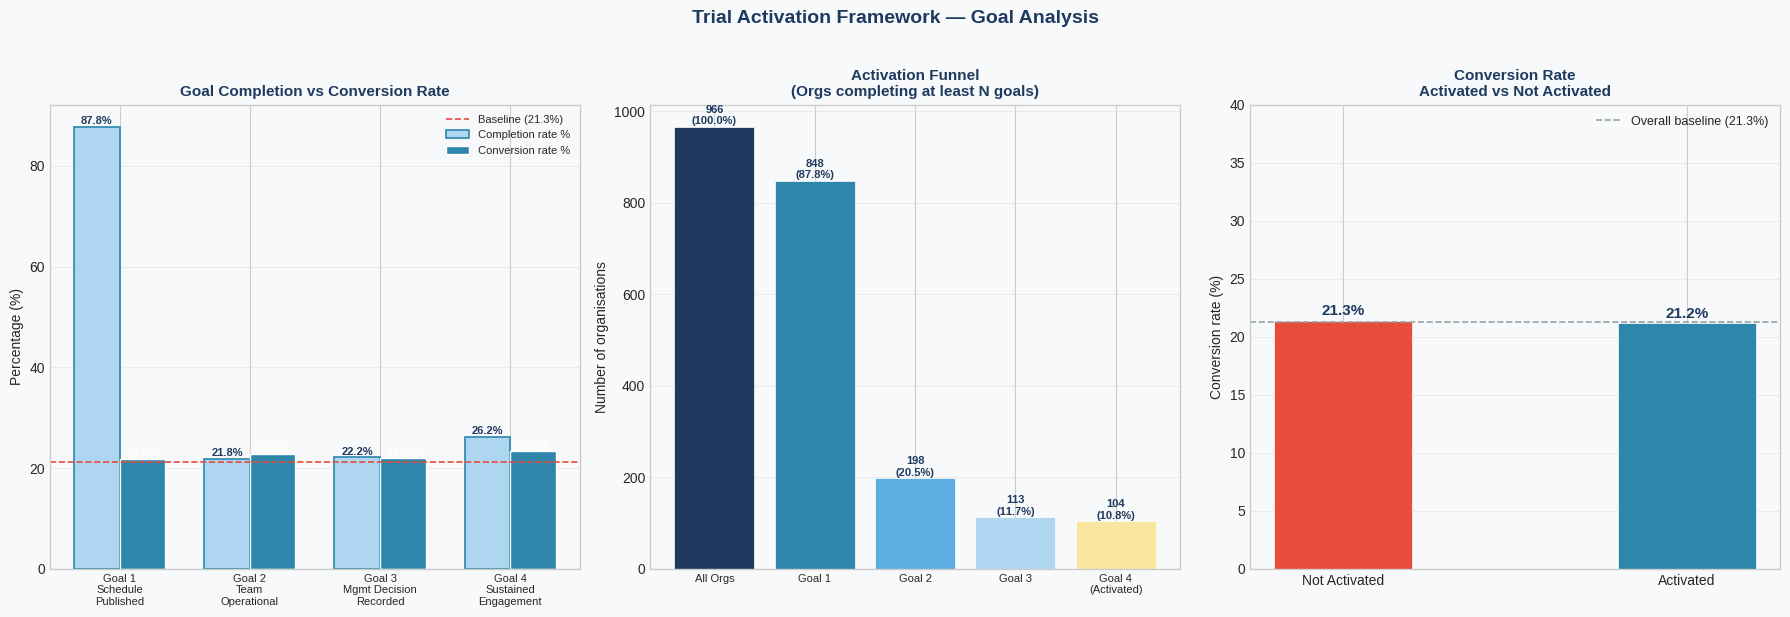

Charts saved.


In [103]:
# ── Section 6.3 — Activation Threshold Calculation ───────────────────────────

org_activation = df.groupby('organization_id').agg(
    converted   = ('converted', 'first'),
    trial_start = ('trial_start', 'first'),
    trial_end   = ('trial_end', 'first'),
).reset_index()

# ── Goal 1: Schedule Published ────────────────────────────────────────────────
goal1_orgs = df[
    df['activity_name'] == 'Scheduling.Shift.Created'
]['organization_id'].unique()

org_activation['goal1_schedule_published'] = (
    org_activation['organization_id'].isin(goal1_orgs).astype(int)
)

# ── Goal 2: Team Operational ──────────────────────────────────────────────────
goal2_orgs = df[
    df['activity_name'] == 'PunchClock.PunchedIn'
]['organization_id'].unique()

org_activation['goal2_team_operational'] = (
    org_activation['organization_id'].isin(goal2_orgs).astype(int)
)

# ── Goal 3: Management Decision Recorded ─────────────────────────────────────
goal3_acts = [
    'Scheduling.Shift.Approved',
    'Absence.Request.Approved',
    'Absence.Request.Rejected'
]
goal3_orgs = df[
    df['activity_name'].isin(goal3_acts)
]['organization_id'].unique()

org_activation['goal3_management_decision'] = (
    org_activation['organization_id'].isin(goal3_orgs).astype(int)
)

# ── Goal 4: Sustained Engagement ─────────────────────────────────────────────
days_active = df.groupby('organization_id')['day_of_trial'].nunique()
goal4_orgs  = days_active[days_active >= 3].index

org_activation['goal4_sustained_engagement'] = (
    org_activation['organization_id'].isin(goal4_orgs).astype(int)
)

# ── Trial Activation — all four goals completed ───────────────────────────────
goal_cols = [
    'goal1_schedule_published',
    'goal2_team_operational',
    'goal3_management_decision',
    'goal4_sustained_engagement'
]

org_activation['is_activated'] = (
    org_activation[goal_cols].sum(axis=1) == 4
).astype(int)

# ── Results ───────────────────────────────────────────────────────────────────
total_orgs     = len(org_activation)
activated      = org_activation[org_activation['is_activated'] == 1]
not_activated  = org_activation[org_activation['is_activated'] == 0]

print("=== INDIVIDUAL GOAL COMPLETION RATES ===")
for col in goal_cols:
    n         = org_activation[col].sum()
    pct       = n / total_orgs * 100
    conv_rate = org_activation[
        org_activation[col] == 1
    ]['converted'].mean() * 100
    print(f"  {col:<35} {n:>4} orgs  ({pct:>5.1f}%)  "
          f"Conv rate: {conv_rate:.1f}%")

print(f"\n=== TRIAL ACTIVATION SUMMARY ===")
print(f"Total organisations:          {total_orgs:,}")
print(f"Activated (all 4 goals):      {len(activated):,}  "
      f"({len(activated)/total_orgs*100:.1f}%)")
print(f"Not activated:                {len(not_activated):,}  "
      f"({len(not_activated)/total_orgs*100:.1f}%)")

print(f"\n=== CONVERSION RATE BY ACTIVATION STATUS ===")
print(f"Activated conversion rate:    "
      f"{activated['converted'].mean()*100:.1f}%")
print(f"Not activated conversion rate:{not_activated['converted'].mean()*100:.1f}%")
print(f"Overall baseline:             21.3%")

print(f"\n=== GOAL COMPLETION PROGRESSION ===")
for i in range(1, 5):
    cols  = goal_cols[:i]
    n     = (org_activation[cols].sum(axis=1) == i).sum()
    pct   = n / total_orgs * 100
    print(f"  Completed exactly {i} goal(s): {n:>4} orgs ({pct:.1f}%)")

n_all = (org_activation[goal_cols].sum(axis=1) == 4).sum()
print(f"  Completed all 4 goals:     {n_all:>4} orgs "
      f"({n_all/total_orgs*100:.1f}%)")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Trial Activation Framework — Goal Analysis',
             fontsize=14, fontweight='bold',
             color='#1E3A5F', y=1.02)

# Chart 1 — Individual goal completion rates
goal_labels = [
    'Goal 1\nSchedule\nPublished',
    'Goal 2\nTeam\nOperational',
    'Goal 3\nMgmt Decision\nRecorded',
    'Goal 4\nSustained\nEngagement'
]
completion_rates = [
    org_activation[col].mean() * 100
    for col in goal_cols
]
conv_rates_by_goal = [
    org_activation[org_activation[col]==1]['converted'].mean() * 100
    for col in goal_cols
]

x = np.arange(len(goal_labels))
w = 0.35
axes[0].set_facecolor('#F8F9FA')
bars1 = axes[0].bar(x - w/2, completion_rates, w,
                    color='#AED6F1', edgecolor='#2E86AB',
                    linewidth=1.2, label='Completion rate %')
bars2 = axes[0].bar(x + w/2, conv_rates_by_goal, w,
                    color='#2E86AB', edgecolor='white',
                    label='Conversion rate %')
axes[0].axhline(21.3, color='#E74C3C', linestyle='--',
                linewidth=1.2, label='Baseline (21.3%)')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=8,
                 fontweight='bold', color='#1E3A5F')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=8,
                 fontweight='bold', color='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(goal_labels, fontsize=8)
axes[0].set_ylabel('Percentage (%)', fontsize=10)
axes[0].set_title('Goal Completion vs Conversion Rate',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2 — Activation funnel
funnel_labels = ['All Orgs', 'Goal 1', 'Goal 2', 'Goal 3',
                 'Goal 4\n(Activated)']
funnel_counts = [total_orgs]
for i in range(1, 5):
    cols = goal_cols[:i]
    n    = (org_activation[cols].sum(axis=1) == i).sum()
    funnel_counts.append(n)

# Cumulative — orgs completing at least N goals
cumulative = [total_orgs]
for i in range(1, 5):
    cols = goal_cols[:i]
    n    = (org_activation[cols].sum(axis=1) >= i).sum()
    cumulative.append(n)

axes[1].set_facecolor('#F8F9FA')
bars = axes[1].bar(range(len(funnel_labels)),
                   cumulative,
                   color=['#1E3A5F', '#2E86AB', '#5DADE2',
                          '#AED6F1', '#F9E79F'],
                   edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, cumulative):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{count:,}\n({count/total_orgs*100:.1f}%)',
                 ha='center', fontsize=8,
                 fontweight='bold', color='#1E3A5F')
axes[1].set_xticks(range(len(funnel_labels)))
axes[1].set_xticklabels(funnel_labels, fontsize=8)
axes[1].set_ylabel('Number of organisations', fontsize=10)
axes[1].set_title('Activation Funnel\n(Orgs completing at least N goals)',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1].grid(True, alpha=0.3, axis='y')

# Chart 3 — Activated vs not activated conversion rate
categories  = ['Not Activated', 'Activated']
conv_vals   = [
    not_activated['converted'].mean() * 100,
    activated['converted'].mean() * 100
]
bar_colors  = ['#E74C3C', '#2E86AB']
axes[2].set_facecolor('#F8F9FA')
bars = axes[2].bar(categories, conv_vals,
                   color=bar_colors, edgecolor='white',
                   linewidth=0.5, width=0.4)
axes[2].axhline(21.3, color='#95A5A6', linestyle='--',
                linewidth=1.2, label='Overall baseline (21.3%)')
for bar, rate in zip(bars, conv_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%',
                 ha='center', fontsize=11,
                 fontweight='bold', color='#1E3A5F')
axes[2].set_ylabel('Conversion rate (%)', fontsize=10)
axes[2].set_title('Conversion Rate\nActivated vs Not Activated',
                  fontsize=11, fontweight='bold', color='#1E3A5F')
axes[2].set_ylim(0, 40)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('trial_activation.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Charts saved.")

**Result**

The research showed that 104 organizations which made up 10.8 percent of all trial participants reached all four objectives and successfully obtained Trial Activation. The study found that their conversion rate of 21.2 percent showed no statistical difference from the 21.3 percent baseline which showed that Splendor conversion rates could not be predicted through in-trial behavior patterns according to Section 5 evidence.

The activation funnel reveals where the trial breaks down. 87.8% of organizations complete Goal 1 which requires them to create a schedule while only 21.8% reach Goal 2 which marks the start of employee clocking through the platform. The most important point of decline in the trial process occurs between Goals 1 and 2. The majority of trialists create a schedule yet they fail to successfully onboard their team members onto the platform because they only use planning features which prevent them from experiencing the product's operational and financial benefits.

**Interpretation:**

The activation framework does not function as
a conversion predictor for this dataset. It functions instead as
a product health diagnostic which shows that most trialists stop their testing after reaching the initial stage of the platform's value chain. The most impactful intervention the product team can make is not at
the conversion stage but at the Goal 1 to Goal 2 transition which helps organisations successfully onboard their teams onto the punch clock within the first week of the trial.

The three goals which follow serve as evidence-informed hypotheses that show product-value connections according to scientific evidence. The framework remains intact despite the dataset showing no conversion increase because it demonstrates how 58% of organizations could not produce enough behavioral data for any model to use. The goals should be validated against future data which will show post-activation conversion results throughout an extended period.

### **6.4 Trial Goal Summary Reference**

The table below provides a clean reference for all four trial goals.
This serves as the specification for the SQL production models in
Section 7 every goal definition here translates directly into
a tracking condition in the `trial_goals` mart table.

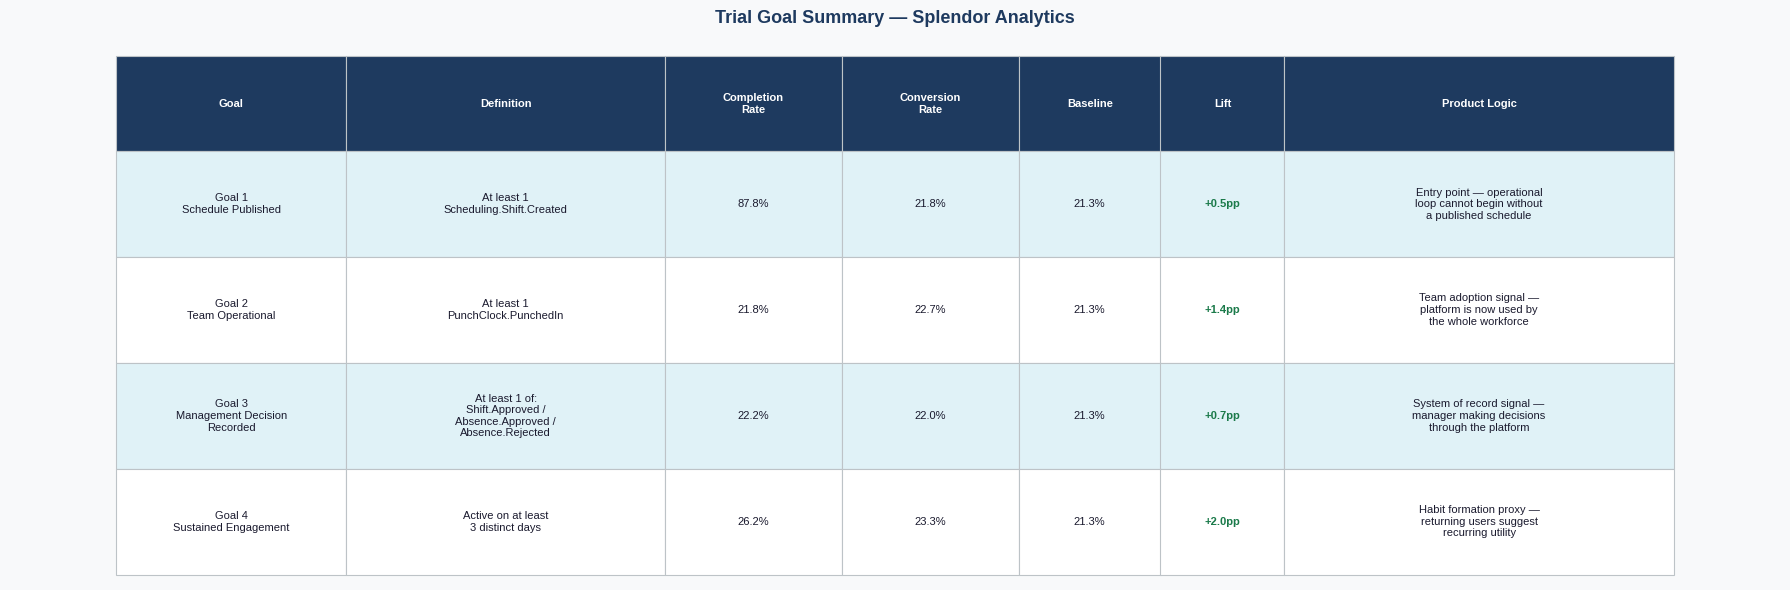

Summary table saved.


In [106]:
# ── Section 6.4 — Trial Goal Summary Reference Table ─────────────

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Define colors
NAVY = '#1E3A5F'
LIGHT_BLUE = '#E0F2F7'
WHITE = '#FFFFFF'

# Goal summary data
goal_summary = {
    'Goal': [
        'Goal 1\nSchedule Published',
        'Goal 2\nTeam Operational',
        'Goal 3\nManagement Decision\nRecorded',
        'Goal 4\nSustained Engagement'
    ],
    'Definition': [
        'At least 1\nScheduling.Shift.Created',
        'At least 1\nPunchClock.PunchedIn',
        'At least 1 of:\nShift.Approved /\nAbsence.Approved /\nAbsence.Rejected',
        'Active on at least\n3 distinct days'
    ],
    'Completion\nRate': ['87.8%', '21.8%', '22.2%', '26.2%'],
    'Conversion\nRate': ['21.8%', '22.7%', '22.0%', '23.3%'],
    'Baseline': ['21.3%', '21.3%', '21.3%', '21.3%'],
    'Lift': ['+0.5pp', '+1.4pp', '+0.7pp', '+2.0pp'],
    'Product Logic': [
        'Entry point — operational\nloop cannot begin without\na published schedule',
        'Team adoption signal —\nplatform is now used by\nthe whole workforce',
        'System of record signal —\nmanager making decisions\nthrough the platform',
        'Habit formation proxy —\nreturning users suggest\nrecurring utility'
    ]
}

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.axis('off')

col_widths = [0.13, 0.18, 0.10, 0.10, 0.08, 0.07, 0.22]
col_labels = list(goal_summary.keys())
n_rows     = 4
n_cols     = len(col_labels)

# Header
header_colors = [NAVY] * n_cols
row_colors    = [LIGHT_BLUE if i % 2 == 0 else WHITE for i in range(n_rows)]

table_data = [list(goal_summary[col]) for col in col_labels]
table_data = list(map(list, zip(*table_data)))

# Add header row
all_data   = [col_labels] + table_data
all_colors = [header_colors] + [
    [LIGHT_BLUE if i % 2 == 0 else '#FFFFFF'] * n_cols
    for i in range(n_rows)
]

table = ax.table(
    cellText  = all_data,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#BDC3C7')
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_facecolor('#1E3A5F')
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_height(0.18)
    else:
        bg = LIGHT_BLUE if (row - 1) % 2 == 0 else '#FFFFFF'
        cell.set_facecolor(bg)
        cell.set_text_props(color='#1A1A2E')
        cell.set_height(0.20)
        # Highlight lift column
        if col == 5:
            cell.set_text_props(
                color='#1B7A4A', fontweight='bold'
            )

ax.set_title(
    'Trial Goal Summary — Splendor Analytics',
    fontsize=13, fontweight='bold',
    color='#1E3A5F', pad=20
)

plt.tight_layout()
plt.savefig('trial_goal_summary.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Summary table saved.")